In [1]:
import pandas as pd
from sqlalchemy import create_engine

username = "postgres"
password = "13092004Ns"
host = "localhost"
port = "5432"
database = "OLIST_Project"

engine = create_engine(
    f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}"
)

print("Connected successfully")

Connected successfully


In [2]:
import os
path = r"C:\Users\User\Documents\OLIST project\Extracted"
os.listdir(path)

['olist_customers_dataset.csv',
 'olist_geolocation_dataset.csv',
 'olist_orders_dataset.csv',
 'olist_order_items_dataset.csv',
 'olist_order_payments_dataset.csv',
 'olist_order_reviews_dataset.csv',
 'olist_products_dataset.csv',
 'olist_sellers_dataset.csv',
 'product_category_name_translation.csv']

In [3]:
from sqlalchemy import text

conn = engine.connect()
for file in os.listdir(path):

    if file.endswith(".csv"):

        table_name = os.path.splitext(file)[0]
        file_path = os.path.join(path, file)

        df = pd.read_csv(file_path, encoding='utf-8')

        print(f"\nLoading {table_name}")
        print(f"Rows: {len(df):,}")
        print(f"Columns: {len(df.columns)}")
        print(f"Columns: {df.columns.tolist()}")
        
        conn.execute(text(f'DROP TABLE IF EXISTS "{table_name}" CASCADE'))
        conn.commit()
        
        df.to_sql(
            table_name,
            engine,
            if_exists='replace',
            index=False
        )

        print(f"Uploaded {table_name}")


Loading olist_customers_dataset
Rows: 99,441
Columns: 5
Columns: ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']
Uploaded olist_customers_dataset

Loading olist_geolocation_dataset
Rows: 1,000,163
Columns: 5
Columns: ['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']
Uploaded olist_geolocation_dataset

Loading olist_orders_dataset
Rows: 99,441
Columns: 8
Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
Uploaded olist_orders_dataset

Loading olist_order_items_dataset
Rows: 112,650
Columns: 7
Columns: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']
Uploaded olist_order_items_dataset

Loading olist_order_payments_dataset
Rows: 103,886
Columns: 5
Columns: ['order_id', 'pay

In [4]:
# data understanding

In [5]:
for file in os.listdir(path):
    if file.endswith(".csv"):
        table_name = os.path.splitext(file)[0]
        query = f"SELECT * FROM {table_name}"
        df = pd.read_sql(sql = query, con = engine)
        print("-"*100 + "\n" + table_name + "\n" + "-"*100)
        print(f"Total Rows : {df.shape[0]}")
        print(f"Total Columns : {df.shape[1]}")
        print("--Data info-- \n") 
        df.info()
        print(f"--Data Description (numeric)-- \n {df.describe()}")
        print(f"--Data Description (Non-numeric)-- \n {df.describe(include='object')}")
        print(f"--Unique Values--\n {df.nunique()}")
        print(f"--Null Values--\n {df.isna().sum()}")

----------------------------------------------------------------------------------------------------
olist_customers_dataset
----------------------------------------------------------------------------------------------------
Total Rows : 99441
Total Columns : 5
--Data info-- 

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB
--Data Description (numeric)-- 
        customer_zip_code_prefix
count              99441.000000
mean               35137.474583
std                29797.938996
min                 1003.000000
25%           

C:\Users\User\AppData\Local\Temp\ipykernel_5328\1885132626.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(f"--Data Description (Non-numeric)-- \n {df.describe(include='object')}")


--Data Description (Non-numeric)-- 
                              customer_id                customer_unique_id  \
count                              99441                             99441   
unique                             99441                             96096   
top     06b8999e2fba1a1fbc88172c00ba8bc7  8d50f5eadf50201ccdcedfb9e2ac8455   
freq                                   1                                17   

       customer_city customer_state  
count          99441          99441  
unique          4119             27  
top        sao paulo             SP  
freq           15540          41746  
--Unique Values--
 customer_id                 99441
customer_unique_id          96096
customer_zip_code_prefix    14994
customer_city                4119
customer_state                 27
dtype: int64
--Null Values--
 customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64


C:\Users\User\AppData\Local\Temp\ipykernel_5328\1885132626.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(f"--Data Description (Non-numeric)-- \n {df.describe(include='object')}")


--Data Description (Non-numeric)-- 
        geolocation_city geolocation_state
count           1000163           1000163
unique             8011                27
top           sao paulo                SP
freq             135800            404268
--Unique Values--
 geolocation_zip_code_prefix     19015
geolocation_lat                717360
geolocation_lng                717613
geolocation_city                 8011
geolocation_state                  27
dtype: int64
--Null Values--
 geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64
----------------------------------------------------------------------------------------------------
olist_orders_dataset
----------------------------------------------------------------------------------------------------
Total Rows : 99441
Total Columns : 8
--Data info-- 

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 9

...

C:\Users\User\AppData\Local\Temp\ipykernel_5328\1885132626.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(f"--Data Description (Non-numeric)-- \n {df.describe(include='object')}")


----------------------------------------------------------------------------------------------------
olist_order_reviews_dataset
----------------------------------------------------------------------------------------------------
Total Rows : 99224
Total Columns : 7
--Data info-- 

<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   review_id                99224 non-null  str  
 1   order_id                 99224 non-null  str  
 2   review_score             99224 non-null  int64
 3   review_comment_title     11568 non-null  str  
 4   review_comment_message   40977 non-null  str  
 5   review_creation_date     99224 non-null  str  
 6   review_answer_timestamp  99224 non-null  str  
dtypes: int64(1), str(6)
memory usage: 5.3 MB
--Data Description (numeric)-- 
        review_score
count  99224.000000
mean       4.086421
std        1.

C:\Users\User\AppData\Local\Temp\ipykernel_5328\1885132626.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(f"--Data Description (Non-numeric)-- \n {df.describe(include='object')}")


--Data Description (Non-numeric)-- 
                                review_id                          order_id  \
count                              99224                             99224   
unique                             98410                             98673   
top     c444278834184f72b1484dfe47de7f97  c88b1d1b157a9999ce368f218a407141   
freq                                   3                                 3   

       review_comment_title review_comment_message review_creation_date  \
count                 11568                  40977                99224   
unique                 4527                  36159                  636   
top               Recomendo              Muito bom  2017-12-19 00:00:00   
freq                    423                    230                  463   

       review_answer_timestamp  
count                    99224  
unique                   98248  
top        2017-06-15 23:21:05  
freq                         4  
--Unique Values--
 review_id   

C:\Users\User\AppData\Local\Temp\ipykernel_5328\1885132626.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(f"--Data Description (Non-numeric)-- \n {df.describe(include='object')}")
C:\Users\User\AppData\Local\Temp\ipykernel_5328\1885132626.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pyda

In [6]:
# All date/timestamp columns load as str, not datetime.

# Zip code prefix columns (customer/seller/geolocation) load as int64 — 
# they are codes, not real quantities. No histogram, ignore numeric stats.

# product_name_lenght, product_description_lenght, product_photos_qty are counts 
# (whole numbers) but load as float64 — caused by nulls forcing the upcast, not real decimals.

In [7]:
# v1 did per-table SQL checks (row count, dtype, null count, unique count) via 
# information_schema queries + COUNT(*) FILTER for each table individually.
# v2 replaces that with pandas equivalents (.info(), .isna().sum(), .nunique()) — 
# faster, less repetitive code, same checks. Cross-validated against v1's SQL 
# output table-by-table; all counts matched exactly, confirming both approaches agree.

## Table - Specific Analysis
##### profiling, distributions, and validity checks scoped to each table individually. 

In [8]:
# olist_customers_dataset

**`olist_customers_dataset` — key findings**

- 99,441 rows, 5 columns, no nulls in any column.
- `customer_id`: str, 99,441 unique values (fully unique), top = `06b8999e2fba1a1fbc88172c00ba8bc7`, freq 1.
- `customer_unique_id`: str, 96,096 unique values, top = `8d50f5eadf50201ccdcedfb9e2ac8455`, freq 17.
- `customer_zip_code_prefix`: int64, 14,994 unique values. Range: min 1003, max 99990. Mean 35,137.47, std 29,797.94. Percentiles: 25% = 11,347, 50% = 24,416, 75% = 58,900.
- `customer_city`: str, 4,119 unique values, top = `sao paulo`, freq 15,540.
- `customer_state`: str, 27 unique values, top = `SP`, freq 41,746.

In [9]:
Query = """SELECT customer_id, customer_unique_id, CAST(customer_zip_code_prefix AS TEXT) AS customer_zip_code_prefix,
TRIM(LOWER(customer_city)) AS customer_city,
TRIM(UPPER(customer_state)) AS customer_state
FROM olist_customers_dataset;"""
df1 = pd.read_sql(Query, engine)
df1

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP
...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS


Order count vs distinct customer count — by state/city

value_counts = freq count · groupby().size() = row count/group (ignores nulls) · groupby().count() = non-null count/group, per-column unless specified. All 3 agree here (0 nulls in customer_state).  
customer_id = 1 row/order, so left = order count (all statuses, no status col here).  
Right = drop_duplicates on customer_unique_id first → distinct customer count.

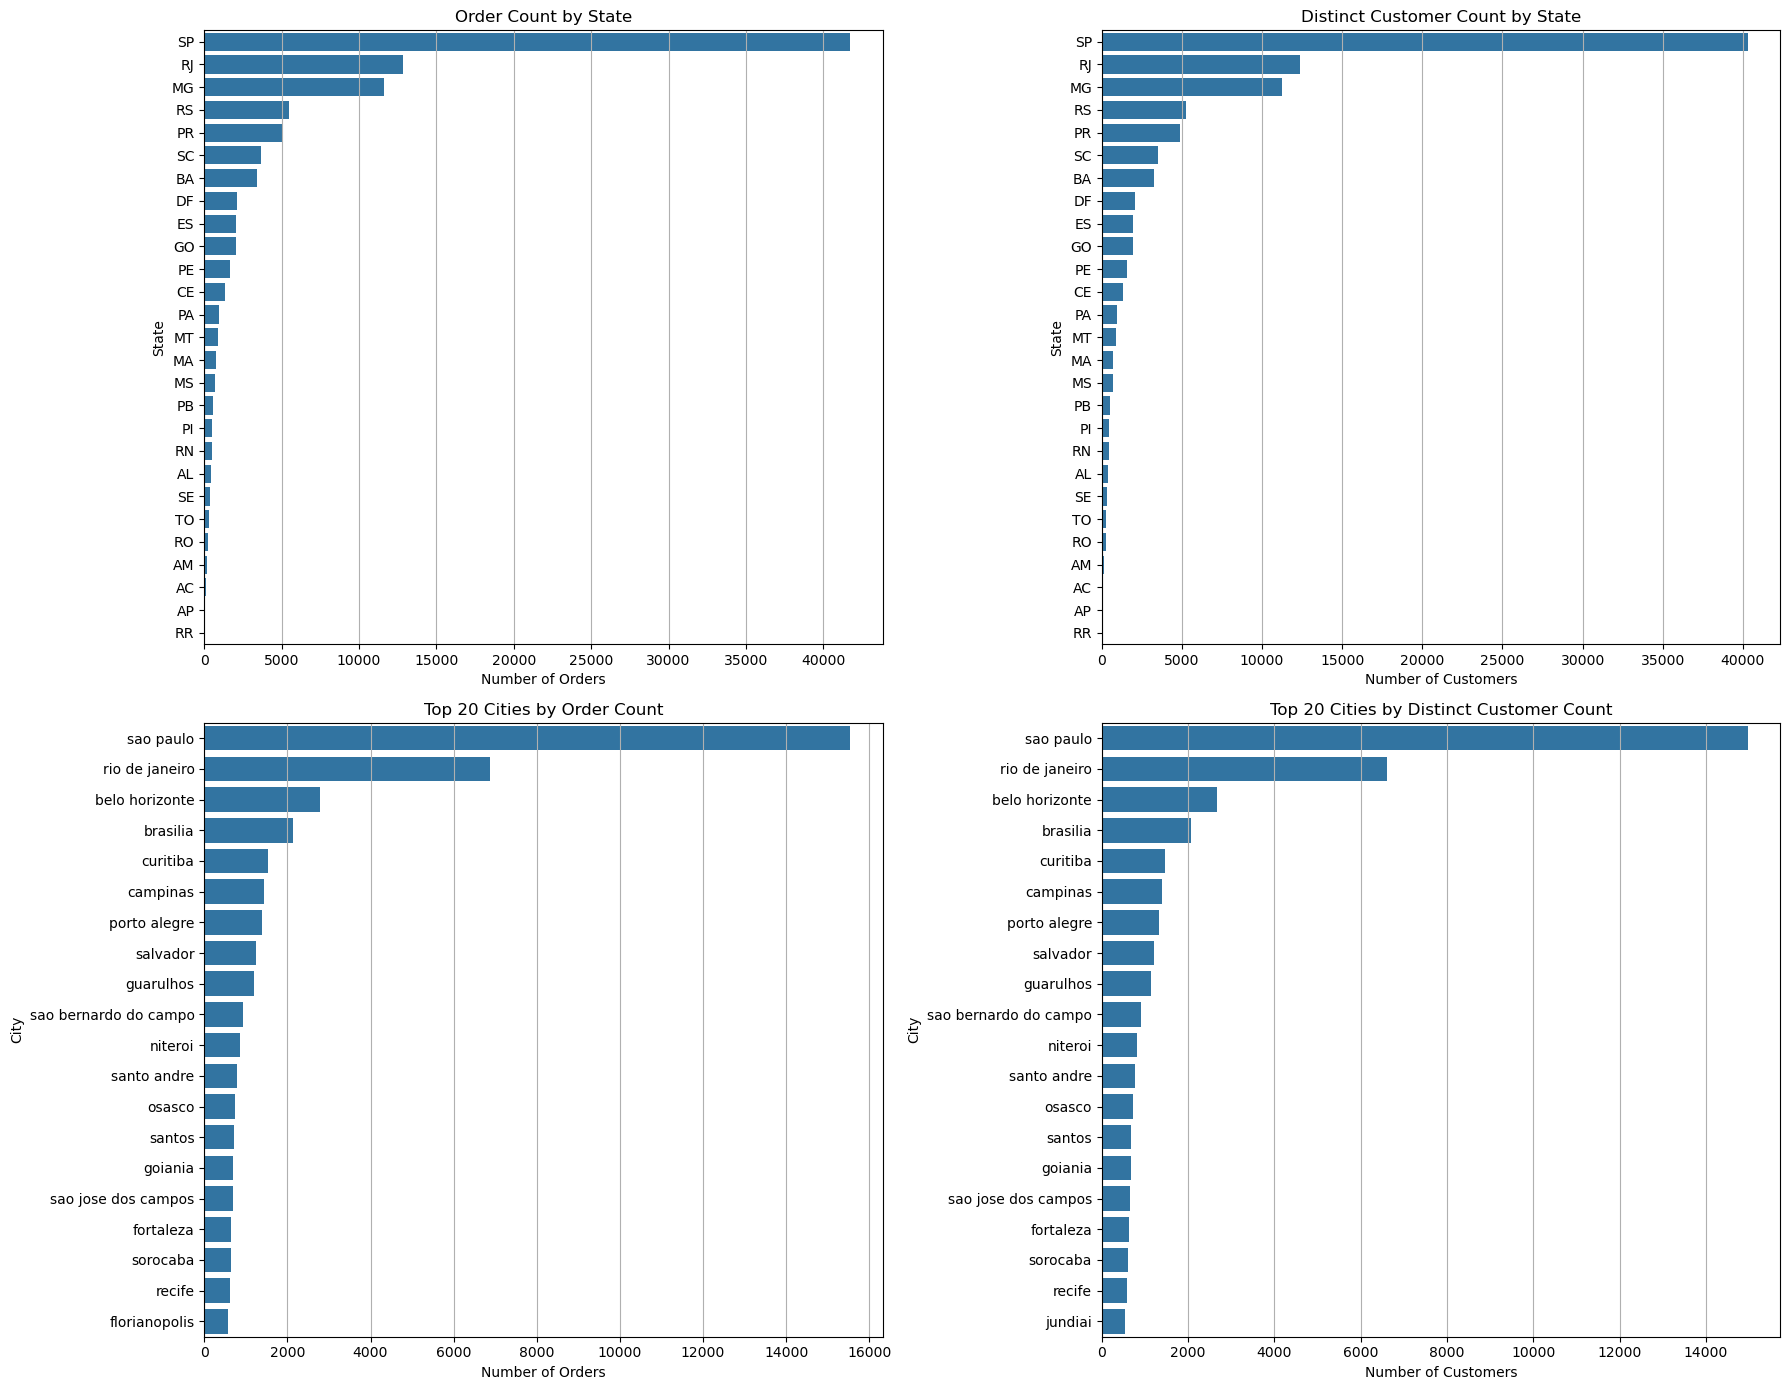

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axs = plt.subplots(2, 2, figsize=(18, 14))

# Left column: order count (customer_id = 1 row per order)
sns.countplot(data=df1, y="customer_state", order=df1['customer_state'].value_counts().index, ax=axs[0, 0])
axs[0, 0].set_title("Order Count by State")
axs[0, 0].set_xlabel("Number of Orders")
axs[0, 0].set_ylabel("State")
axs[0, 0].grid(True, axis = 'x')
sns.countplot(data=df1, y="customer_city", order=df1['customer_city'].value_counts().head(20).index, ax=axs[1, 0])
axs[1, 0].set_title("Top 20 Cities by Order Count")
axs[1, 0].set_xlabel("Number of Orders")
axs[1, 0].set_ylabel("City")
axs[1, 0].grid(True, axis = 'x')

# Right column: distinct customers (for customer_unique_id)
df1_unique = df1.drop_duplicates(subset='customer_unique_id')

sns.countplot(data=df1_unique, y="customer_state", order=df1_unique['customer_state'].value_counts().index, ax=axs[0, 1])
axs[0, 1].set_title("Distinct Customer Count by State")
axs[0, 1].set_xlabel("Number of Customers")
axs[0, 1].set_ylabel("State")
axs[0, 1].grid(True, axis = 'x')
sns.countplot(data=df1_unique, y="customer_city", order=df1_unique['customer_city'].value_counts().head(20).index, ax=axs[1, 1])
axs[1, 1].set_title("Top 20 Cities by Distinct Customer Count")
axs[1, 1].set_xlabel("Number of Customers")
axs[1, 1].set_ylabel("City")
axs[1, 1].grid(True, axis = 'x')

plt.tight_layout()
plt.show()

Order count and distinct customer count are nearly identical across all states/cities, consistent with the low overall repeat-customer rate (~3.4%).   
Note this includes all order statuses (canceled, unavailable, etc.), not just successful ones — so this is customer/order geographic distribution overall, not a measure of successful business volume by region.   
SP dominates both by a wide margin, reflecting its size as Brazil's largest economic hub.

In [11]:
# olist_geolocation_dataset

**`olist_geolocation_dataset` — key findings**

- 1,000,163 rows, 5 columns, no nulls in any column.
- `geolocation_zip_code_prefix`: int64, 19,015 unique values. Range: min 1,001, max 99,990. Mean 36,574.17, std 30,549.34. Percentiles: 25% = 11,075, 50% = 26,530, 75% = 63,504.
- `geolocation_lat`: float64, 717,360 unique values. Range: min -36.61, max 45.07. Mean -21.18, std 5.72. Percentiles: 25% = -23.60, 50% = -22.92, 75% = -19.98.
- `geolocation_lng`: float64, 717,613 unique values. Range: min -101.47, max 121.11. Mean -46.39, std 4.27. Percentiles: 25% = -48.57, 50% = -46.64, 75% = -43.77.
- `geolocation_city`: str, 8,011 unique values, top = `sao paulo`, freq 135,800.
- `geolocation_state`: str, 27 unique values, top = `SP`, freq 404,268.

In [12]:
Query = """SELECT CAST(geolocation_zip_code_prefix AS TEXT) AS geolocation_zip_code_prefix , 
geolocation_lat, geolocation_lng, 
TRIM(LOWER(geolocation_city)) AS geological_city,
TRIM(UPPER(geolocation_state)) AS geological_state
FROM olist_geolocation_dataset"""
df2 = pd.read_sql(Query, engine)
df2

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geological_city,geological_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP
...,...,...,...,...,...
1000158,99950,-28.068639,-52.010705,tapejara,RS
1000159,99900,-27.877125,-52.224882,getulio vargas,RS
1000160,99950,-28.071855,-52.014716,tapejara,RS
1000161,99980,-28.388932,-51.846871,david canabarro,RS


In [13]:
print(f"Total Rows = {df2.shape[0]}")
print(df2['geolocation_zip_code_prefix'].nunique())
print(df2['geological_state'].nunique())
print(df2['geological_city'].nunique())
print(df2.drop_duplicates(subset=['geolocation_zip_code_prefix', 'geological_state']).shape[0])
print(df2.drop_duplicates(subset=['geolocation_zip_code_prefix', 'geological_city','geological_state']).shape[0])
print(df2['geolocation_lat'].nunique())
print(df2['geolocation_lng'].nunique())
print(df2.drop_duplicates(subset=['geolocation_lat', 'geolocation_lng']).shape[0])
print(df2.drop_duplicates(subset=['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng']).shape[0])
print(df2.drop_duplicates().shape[0])

Total Rows = 1000163
19015
27
8010
19023
27911
717360
717613
718463
720154
738332


1,000,163 rows, 5 columns, no nulls.  
geolocation_zip_code_prefix: only 19,015 unique values → not one-row-per-zip (~52 rows/zip on average).  
No column or combination gives a clean unique key: zip alone (19,015), (zip, state) (19,023), (zip, city, state) (27,911) — all far below total row count.  
(zip, state) is only 8 higher than zip alone → a handful of zip codes are recorded under more than one state (likely data inconsistency).  
(zip, lat, lng) unique count (720,154) is still less than total rows (1,000,163) → ~280,000 exact duplicate pings (same zip, same lat/lng repeated).  
Raw geolocation_city had 8,011 unique values; after TRIM(LOWER()) cleaning, geological_city has 8,010 — one duplicate pair (differing only by case/whitespace) correctly merged, confirming the cleaning step caught a real issue.  

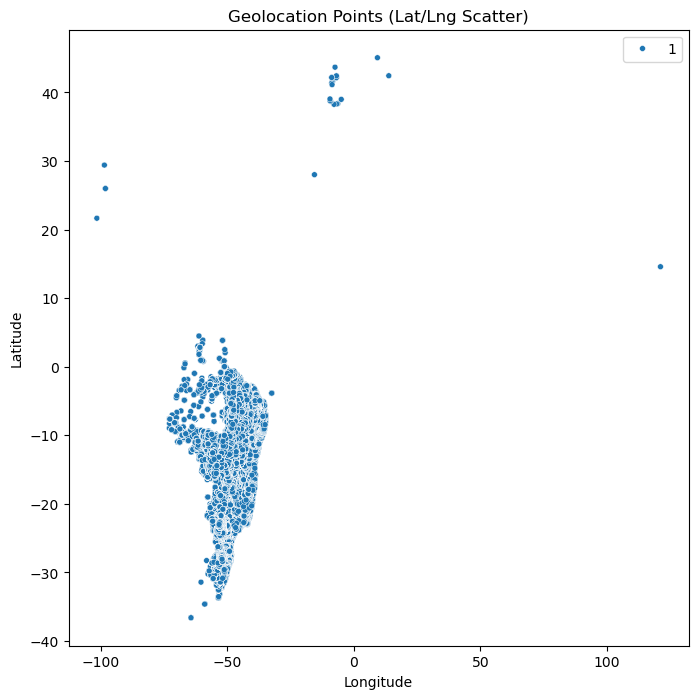

In [14]:
plt.figure(figsize = (8, 8))
sns.scatterplot(data = df2, x = 'geolocation_lng', y = 'geolocation_lat', size = 1)
plt.title('Geolocation Points (Lat/Lng Scatter)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

Plotted geolocation_lat vs geolocation_lng to see the spatial spread of points.  
Overall shape roughly matches Brazil, but a few points fall way outside it — like lat 20-45, lng -100 to +120, nowhere close to Brazil's real range (lat -33.75 to 5.27, lng -73.98 to -34.79).  
Found a clear example: zip 45936 has two rows with totally different coordinates — one near Buenos Aires, one near Portugal — even though the state listed is Bahia (BA), which is neither.   
These are bad geocoding entries, not real locations.

In [15]:
brazil_outliers = df2[(df2['geolocation_lat'] > 5.27) | (df2['geolocation_lat'] < -33.75) |
    (df2['geolocation_lng'] > -34.79) | (df2['geolocation_lng'] < -73.98)]
print(f"Outlier rows outside Brazil's bounds: {brazil_outliers.shape[0]}")
brazil_outliers

Outlier rows outside Brazil's bounds: 42


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geological_city,geological_state
387565,18243,28.008978,-15.536867,bom retiro da esperanca,SP
513631,28165,41.614052,-8.411675,vila nova de campos,RJ
513643,28155,-34.586422,-58.732101,santa maria,RJ
513754,28155,42.439286,13.820214,santa maria,RJ
514429,28333,38.381672,-6.328200,raposo,RJ
516682,28595,43.684961,-7.411080,portela,RJ
538512,29654,29.409252,-98.484121,santo antônio do canaã,ES
538557,29654,21.657547,-101.466766,santo antonio do canaa,ES
585242,35179,25.995203,-98.078544,santana do paraíso,MG
585260,35179,25.995245,-98.078533,santana do paraiso,MG


Spot-checked spelling inconsistency found beyond casing (e.g. "itabata"/"itabatan" for the same zip 45936) — likely same city, inconsistent spelling. Full spelling-consistency check across all city names is out of scope for this project

In [16]:
# olist_orders_dataset

**`olist_orders_dataset` — key findings**

- 99,441 rows, 8 columns.
- `order_id`: str, 99,441 unique values (fully unique)
- `customer_id`: str, 99,441 unique values (fully unique)
- `order_status`: str, 8 unique values, top = `delivered`, freq 96,478, 0 nulls.
- `order_purchase_timestamp`: str, 98,875 unique values, top = `2018-03-31 15:08:21`, freq 3, 0 nulls.
- `order_approved_at`: str, 90,733 unique values, top = `2018-02-27 04:31:10`, freq 9, 160 nulls.
- `order_delivered_carrier_date`: str, 81,018 unique values, top = `2018-05-09 15:48:00`, freq 47, 1,783 nulls.
- `order_delivered_customer_date`: str, 95,664 unique values, top = `2018-05-14 20:02:44`, freq 3, 2,965 nulls.
- `order_estimated_delivery_date`: str, 459 unique values, top = `2017-12-20 00:00:00`, freq 522, 0 nulls.

In [17]:
Query = """SELECT order_id, customer_id, order_status, 
CAST(order_purchase_timestamp AS TIMESTAMP) AS order_purchase_timestamp,
CAST(order_approved_at AS TIMESTAMP) AS order_approved_at,
CAST(order_delivered_carrier_date AS TIMESTAMP) AS order_delivered_carrier_date, 
CAST(order_delivered_customer_date AS TIMESTAMP) AS order_delivered_customer_date,
CAST(order_estimated_delivery_date AS TIMESTAMP) AS order_estimated_delivery_date
FROM olist_orders_dataset"""

df3 = pd.read_sql(Query, engine)
df3

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15


In [18]:
query = """SELECT order_status, COUNT(*) AS counts FROM olist_orders_dataset
GROUP BY order_status ORDER BY counts DESC"""
order_status_check = pd.read_sql(query, engine)
order_status_check

,order_status,counts
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


### plt.text:
enumerate(col): one column's values + a plain position (0,1,2...). Use when only the value matters and the data's row order already matches the plot order.  
col.items(): one column's values + its real index label. Use when the actual label matters — e.g. after sorting a dataframe without resetting its index.  
df.iterrows(): multiple columns from the same row, together. Use when more than one field (e.g. category name and count) is needed per row.

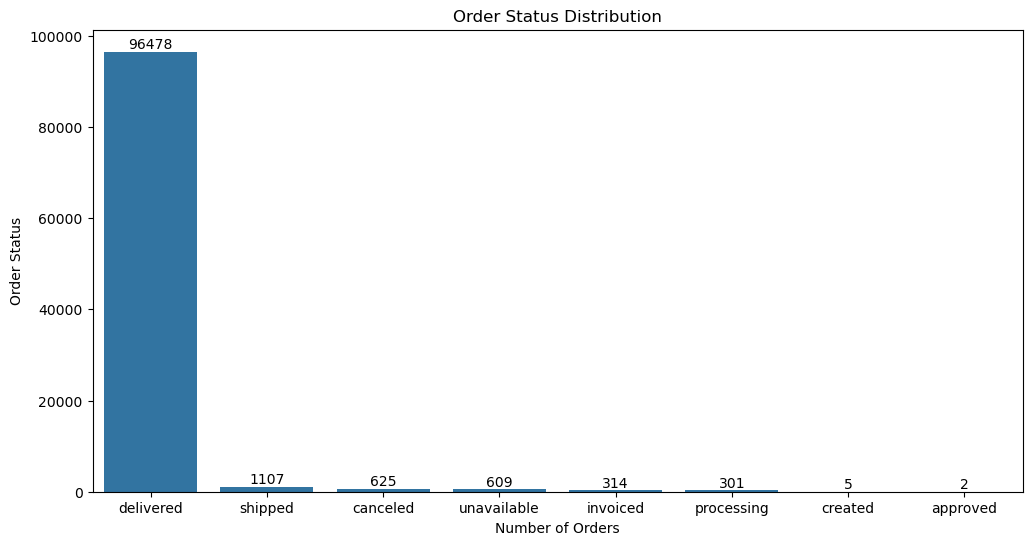

In [19]:
plt.figure(figsize=(12, 6))
sns.barplot(data = order_status_check, x = "order_status", y = "counts", order = order_status_check['order_status'])
plt.title('Order Status Distribution')
plt.xlabel('Number of Orders')
plt.ylabel('Order Status')
for i, value in enumerate(order_status_check['counts']):
    plt.text(i, value, f"{value}", va = 'bottom', ha = 'center')
plt.show()

In [20]:
# Check for order_status = delivered 
query = """SELECT COUNT(*) AS total_delivered, COUNT(order_approved_at) AS approved_count,
COUNT(order_delivered_carrier_date) AS carrier_delivered_count, COUNT(order_delivered_customer_date) AS customer_delivered_count
FROM olist_orders_dataset WHERE order_status = 'delivered';"""
check = pd.read_sql(query, engine)
check

,total_delivered,approved_count,carrier_delivered_count,customer_delivered_count
0,96478,96464,96476,96470


#### Data quality issue — nulls in "delivered" orders:   
14 delivered orders have a null order_approved_at  
2 delivered orders have a null order_delivered_carrier_date  
8 delivered orders have a null order_delivered_customer_date

In [21]:
# Dataset date range
query = """SELECT MIN(CAST(order_purchase_timestamp AS TIMESTAMP)) AS first_purchase_date,
MAX(CAST(order_purchase_timestamp AS TIMESTAMP))  AS last_purchase_date,
AGE(MAX(CAST(order_purchase_timestamp AS TIMESTAMP)), MIN(CAST(order_purchase_timestamp AS TIMESTAMP))) AS date_range,
EXTRACT(YEAR FROM AGE(MAX(CAST(order_purchase_timestamp AS TIMESTAMP)), MIN(CAST(order_purchase_timestamp AS TIMESTAMP)))) || ' years ' ||
EXTRACT(MONTH FROM AGE(MAX(CAST(order_purchase_timestamp AS TIMESTAMP)), MIN(CAST(order_purchase_timestamp AS TIMESTAMP)))) || ' months ' ||
EXTRACT(DAY FROM AGE(MAX(CAST(order_purchase_timestamp AS TIMESTAMP)), MIN(CAST(order_purchase_timestamp AS TIMESTAMP)))) || ' days' AS date_range_TEXT
FROM olist_orders_dataset"""
p_dates_check = pd.read_sql(query, engine)
p_dates_check

,first_purchase_date,last_purchase_date,date_range,date_range_text
0,2016-09-04 21:15:19,2018-10-17 17:30:18,772 days 20:14:59,2 years 1 months 12 days


First order: 2016-09-04, Last order: 2018-10-17 → spans 2 years, 1 month, 12 days  
Used order_purchase_timestamp since it's the only date column with 0 nulls — gives the true full dataset span, unaffected by orders that never got delivered  
First/last months are likely sparse (partial months at the dataset's edges)

In [22]:
# Date logic check for delivered orders: not null + correct order (purchase < approved < carrier < delivered)
# Other statuses excluded - they will have null dates, not a data quality issue
query = """SELECT COUNT(*) as logic_violations
FROM olist_orders_dataset
WHERE order_status = 'delivered'
AND order_approved_at IS NOT NULL
AND order_delivered_carrier_date IS NOT NULL
AND order_delivered_customer_date IS NOT NULL
AND(
CAST(order_purchase_timestamp AS TIMESTAMP) > CAST(order_approved_at AS TIMESTAMP)
OR CAST(order_approved_at AS TIMESTAMP) > CAST(order_delivered_carrier_date AS TIMESTAMP)
OR CAST(order_delivered_carrier_date AS TIMESTAMP) > CAST(order_delivered_customer_date AS TIMESTAMP)
)"""
check = pd.read_sql(query, engine)
check

,logic_violations
0,1373


In [23]:
# Non-delivered orders — date field null check
non_delivered_df = df3[df3['order_status'] != 'delivered']
missing_dates_summary = non_delivered_df.groupby('order_status')[['order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date']].apply(lambda x: x.isnull().sum())
print(missing_dates_summary)

              order_approved_at  order_delivered_carrier_date  \
order_status                                                    
approved                      0                             2   
canceled                    141                           550   
created                       5                             5   
invoiced                      0                           314   
processing                    0                           301   
shipped                       0                             0   
unavailable                   0                           609   

              order_delivered_customer_date  
order_status                                 
approved                                  2  
canceled                                619  
created                                   5  
invoiced                                314  
processing                              301  
shipped                                1107  
unavailable                             609  


canceled (625): 619 null customer-delivery dates → 6 canceled orders have a delivery date filled in 

In [24]:
# olist_order_items_dataset : ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

**`olist_order_items_dataset` — key findings**

- 112,650 rows, 7 columns, no nulls in any column.
- `order_id`: str, 98,666 unique values, top = `8272b63d03f5f79c56e9e4120aec44ef`, freq 21.
- `order_item_id`: int64, 21 unique values. Range: min 1, max 21. Mean 1.20, std 0.71. Percentiles: 25% = 1, 50% = 1, 75% = 1.
- `product_id`: str, 32,951 unique values, top = `aca2eb7d00ea1a7b8ebd4e68314663af`, freq 527.
- `seller_id`: str, 3,095 unique values, top = `6560211a19b47992c3666cc44a7e94c0`, freq 2,033.
- `shipping_limit_date`: str, 93,318 unique values, top = `2018-03-01 02:50:48`, freq 21.
- `price`: float64, 5,968 unique values. Range: min 0.85, max 6,735.00. Mean 120.65, std 183.63. Percentiles: 25% = 39.90, 50% = 74.99, 75% = 134.90.
- `freight_value`: float64, 6,999 unique values. Range: min 0.00, max 409.68. Mean 19.99, std 15.81. Percentiles: 25% = 13.08, 50% = 16.26, 75% = 21.15.

In [25]:
Query = """SELECT order_id, 
CAST(order_item_id AS TEXT) AS order_item_id,
product_id, seller_id, 
CAST(shipping_limit_date AS TIMESTAMP) AS shipping_limit_date, 
price, freight_value
FROM olist_order_items_dataset"""

df4 = pd.read_sql(Query, engine)
df4

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72


In [26]:
df4.shape[0], df4.drop_duplicates(subset=['order_id', 'order_item_id']).shape[0]

(112650, 112650)

**order_items — finest-grain transactional table**  
112,650 rows, 1 row = 1 item within an order (order_id repeats for multi-item orders).  
price and freight_value are the real numeric/quantity columns here — both show mean > median, a signal (not proof) of right-skew, to be confirmed by histogram.  
order_item_id is a sequence number within an order (max 21), not a real quantity — excluded from distribution interpretation.  
(order_id, order_item_id) confirmed as a clean composite key — no duplicate rows for the same order's same item position.

In [27]:
# order_item_id validity check
query = """SELECT COUNT(*) AS violations
FROM olist_order_items_dataset
WHERE order_item_id < 1"""
item_id_check = pd.read_sql(query, engine)
item_id_check

,violations
0,0


In [28]:
df4[['price', 'freight_value']].agg(['min', 'max'])

,price,freight_value
min,0.85,0.00
max,6735.00,409.68


price: min 0.85, max 6,735.00 — confirms no free or invalid-priced items.   
freight_value: min 0.00, max 409.68 — freight can legitimately be zero.

In [29]:
# Zero freight check
query = """SELECT COUNT(*) AS zero_freight_count
FROM olist_order_items_dataset
WHERE freight_value = 0"""
zero_freight_check = pd.read_sql(query, engine)
zero_freight_check

,zero_freight_count
0,383


383 out of 112,650 order_item rows (~0.3%) have freight_value = 0.  
A real shipping cost is virtually never zero — someone (seller, marketplace, or customer) always incurs it, even when the customer isn't charged directly.   
So these 383 rows likely reflect missing/unrecorded values, not genuine zero-cost shipping.

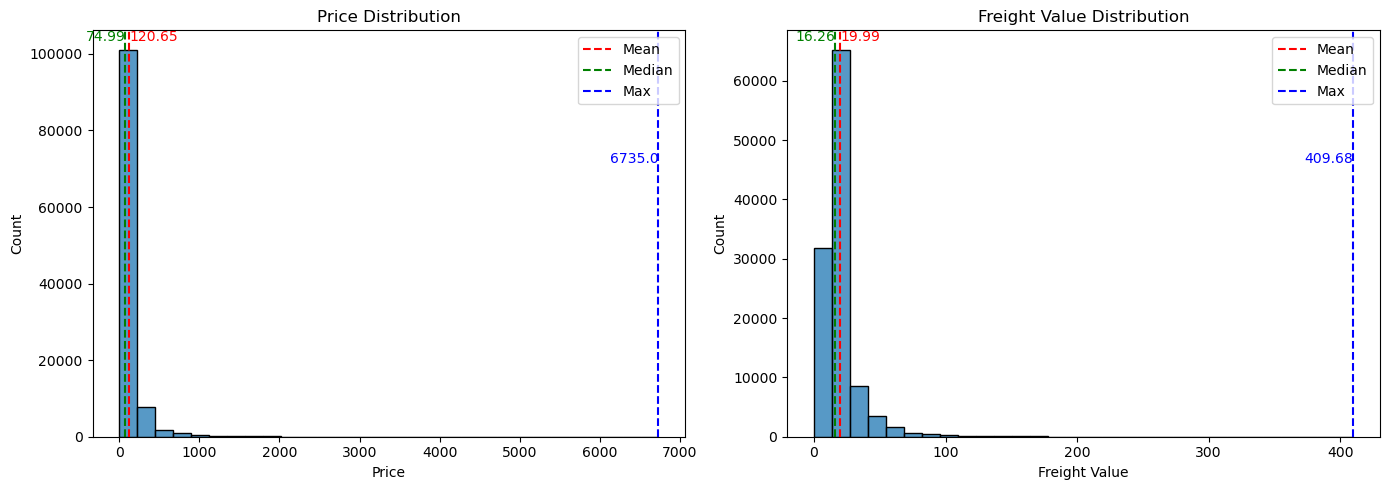

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
columns = ['price', 'freight_value']

for col, ax in zip(columns, axes):
    sns.histplot(df4[col], bins=30, ax=ax)
    ax.axvline(df4[col].mean(), color='red', linestyle='--', label='Mean')
    ax.axvline(df4[col].median(), color='green', linestyle='--', label='Median')
    ax.axvline(df4[col].max(), color='blue', linestyle='--', label='Max')
    ax.text(df4[col].mean(), ax.get_ylim()[1], f"{df4[col].mean():.2f}", color='red', va = 'top', ha = 'left')
    ax.text(df4[col].median(), ax.get_ylim()[1], f"{df4[col].median():.2f}", color='green', va = 'top', ha = 'right')
    ax.text(df4[col].max(), ax.get_ylim()[1]*0.7, f"{df4[col].max()}", color='blue', va = 'top', ha = 'right')
    ax.set_title(f'{col.replace("_", " ").title()} Distribution')
    ax.set_xlabel(col.replace("_", " ").title())
    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

Both price and freight_value are strongly right-skewed — most ordered items were low-priced/low-freight, with a smaller number of high-value orders stretching the tail far right.   
Reflects purchasing behavior from order_items, not necessarily the full product catalog's price range.
price: median ₹74.99, mean ₹120.65 — mean pulled well above median, confirming the skew. Max (₹6,735) is nearly 90x the median.   
freight_value: median ₹16.26, mean ₹19.99 — same pattern, less extreme than price (mean ~1.2x median vs ~1.6x for price). Max (₹409.68) is about 25x the median.   
Price reflects the value of the commodity itself, which can vary widely by category — this likely drives its wider skew. Freight_value is typically tied to distance, and may also relate to product weight/dimensions — factors that are more physically bounded

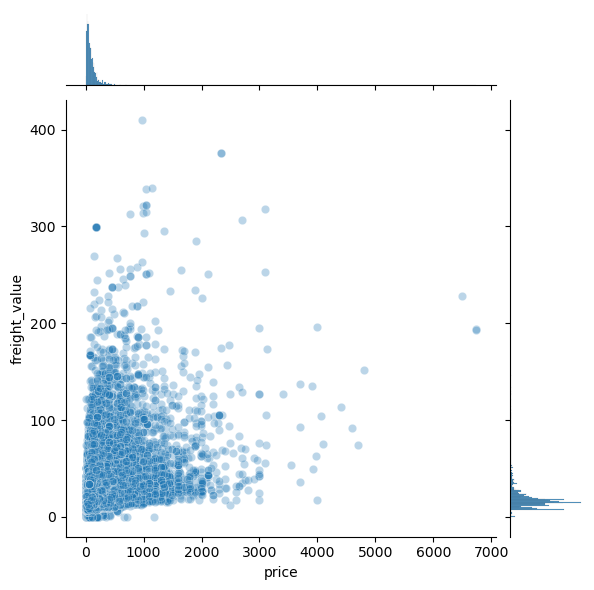

In [31]:
sns.jointplot(data=df4, x='price', y='freight_value', kind='scatter', alpha=0.3)
plt.show()

In [32]:
df4[['price', 'freight_value']].corr()
# CORR(y, x) can also be used -- Postgres

,price,freight_value
price,1.000000,0.414204
freight_value,0.414204,1.000000


**Price vs Freight relationship**  
Correlation coefficient: 0.41 — weak-to-moderate positive relationship, not strong.   
Scatter plot shows no tight linear pattern; similarly-priced items can have widely varying freight costs, and a few high-price items have disproportionately low freight.   
Supports the earlier hypothesis: freight is likely driven more by weight/dimensions/distance than by the item's price.

In [33]:
# Seller-level counts: item volume (COUNT *) and distinct order reach (COUNT DISTINCT order_id).
# Regardless of order_status - this table has no status column, and no join to orders is done here.
query = """SELECT seller_id, 
COUNT(*) AS item_count, 
COUNT(DISTINCT order_id) AS order_count
FROM olist_order_items_dataset
GROUP BY seller_id
ORDER BY item_count DESC"""
seller_check = pd.read_sql(query, engine)
seller_check

,seller_id,item_count,order_count
0,6560211a19b47992c3666cc44a7e94c0,2033,1854
1,4a3ca9315b744ce9f8e9374361493884,1987,1806
2,1f50f920176fa81dab994f9023523100,1931,1404
3,cc419e0650a3c5ba77189a1882b7556a,1775,1706
4,da8622b14eb17ae2831f4ac5b9dab84a,1551,1314
...,...,...,...
3090,6614814a00d344b846ae209f95ee7e3f,1,1
3091,f00f5b35d0abcacbdd863672f4bb2c1a,1,1
3092,134b867a0f7f8bbe6abf10f91874891e,1,1
3093,d598f929fc44e1e38678e7f47250ec04,1,1


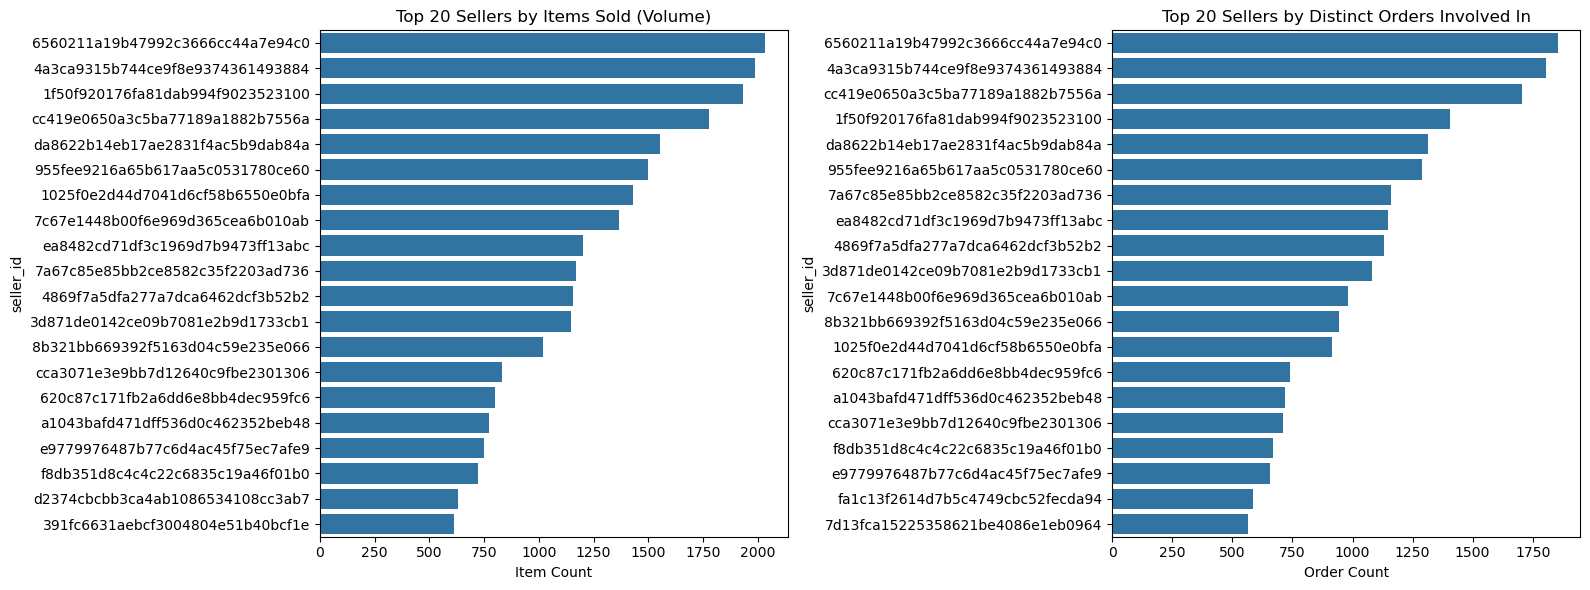

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=seller_check.head(20), y='seller_id', x='item_count', ax=axes[0])
axes[0].set_title('Top 20 Sellers by Items Sold (Volume)')
axes[0].set_xlabel('Item Count')

sns.barplot(data=seller_check.sort_values('order_count', ascending=False).head(20), y='seller_id', x='order_count', ax=axes[1])
axes[1].set_title('Top 20 Sellers by Distinct Orders Involved In')
axes[1].set_xlabel('Order Count')

plt.tight_layout()
plt.show()

Top sellers — item volume vs order reach  

Top seller (6560211a19b47992c3666cc44a7e94c0) is the same across both metrics, but ranking shifts for others — even within the top 20, position order changes between item-count and order-count views.   
This reflects real behavioral differences (some sellers bundle more items per order than others), not noise — a seller with a higher items-per-order ratio ranks relatively higher on volume than on order reach.  
Likely more pronounced further down the ~3,095 total sellers, where smaller order counts make per-seller bundling patterns swing rank more sharply — not directly verified beyond the top 20 shown here.  
All of this is regardless of order_status, since order_items has no status column and no join to orders was done here.

In [35]:
# Single vs multi-item order distribution
query = """WITH order_item_counts AS (
SELECT order_id, COUNT(*) AS items_per_order
FROM olist_order_items_dataset
GROUP BY order_id)
SELECT COUNT(*) FILTER (WHERE items_per_order = 1) AS single_item_orders,
COUNT(*) FILTER (WHERE items_per_order > 1) AS multi_item_orders
FROM order_item_counts"""
order_type_check = pd.read_sql(query, engine)
order_type_check

,single_item_orders,multi_item_orders
0,88863,9803


88,863 orders (~90%) contain exactly 1 item; 9,803 orders (~10%) contain 2 or more items.  
Max items in a single order: 21 (from earlier profiling).   
Confirms most transactions are simple, single-item purchases — multi-item orders are the minority.   
All counts are irrespective of order_status, since order_items has no status column and no join to orders was done here

~10% of orders contain multiple items — some may reflect complementary-product buying, but this alone doesn't confirm it, since unrelated items can also end up in the same order.

In [36]:
# Times each product was ordered — base aggregation
query = """SELECT product_id, COUNT(*) AS times_ordered
FROM olist_order_items_dataset
GROUP BY product_id"""
product_orders = pd.read_sql(query, engine)
product_orders, product_orders['times_ordered'].describe()

(                             product_id  times_ordered
 0      027293c3b6d9e221268d9d6a5ffe5d0b              1
 1      9ad4fb75641c9a71f995a06d0386a6f9              2
 2      5ed2407e517ceac8615bb4d1ea238fe6              1
 3      8e630a6101b33d99671d79b67b87052d              2
 4      cf41f723df264ec6f1c74d1caca1642e              1
 ...                                 ...            ...
 32946  4f27f0b527bb700ed8541270356a38f3              2
 32947  c770c3d5ab511e88a96d387bdb0b6ce0              2
 32948  f663f7a6fc390011dd15492f14205573              1
 32949  df1ff6c9a263464ba1ea7cd3de5e8633              1
 32950  44e6ec37a142be331fe0241006d0b389              3
 
 [32951 rows x 2 columns],
 count    32951.000000
 mean         3.418713
 std         10.619709
 min          1.000000
 25%          1.000000
 50%          1.000000
 75%          3.000000
 max        527.000000
 Name: times_ordered, dtype: float64)

Median times_ordered: 1. 75th percentile: 3. Mean: 3.42, std: 10.62. Max: 527.    
Most products ordered only once or twice — distribution is heavily right-skewed, not a normal spread.    
Gap between 75th percentile (3) and max (527) signals a small set of products ordered far more often than the rest.   
All counts are irrespective of order_status, at the order_item level, since here, Zthe question is whether a product was purchased, not whether it was delivered.

In [37]:
# Percentile scan (80–99) to locate cutoff for "popular"/"bestseller"
import numpy as np
percentiles = np.arange(0.80, 1, 0.01)
for p in percentiles:
    query = f"""WITH product_orders AS (
    SELECT product_id, COUNT(*) AS times_ordered
    FROM olist_order_items_dataset
    GROUP BY product_id)
    SELECT PERCENTILE_CONT({p}) WITHIN GROUP (ORDER BY times_ordered) AS p_{int(p*100)}
    FROM product_orders"""
    check = pd.read_sql(query, engine)
    print(check)

   p_80
0   3.0
   p_81
0   4.0
   p_82
0   4.0
   p_83
0   4.0
   p_84
0   4.0
   p_85
0   4.0
   p_86
0   5.0
   p_87
0   5.0
   p_88
0   5.0
   p_89
0   6.0
   p_90
0   6.0
   p_91
0   7.0
   p_92
0   7.0
   p_93
0   8.0
   p_94
0   9.0
   p_95
0  11.0
   p_96
0  13.0
   p_97
0  15.5
   p_98
0  21.0
   p_99
0  33.0


Checked p80–p99 via PERCENTILE_CONT loop.  
Growth is slow up to ~p90, then accelerates sharply.  
p95 = 11 orders (~1,648 products), p99 = 33 orders (~330 products).  
Using both: top 5% as "popular", top 1% as "bestseller".  
Irrespective of order_status, at order_item level.

In [38]:
# Product tier counts using chosen cutoffs (11, 33)
# popular only (11 to 32), excludes bestsellers
popular = product_orders[(product_orders['times_ordered'] >= 11) & (product_orders['times_ordered'] < 33)].shape[0]
# bestseller only (33+)
bestseller = product_orders[product_orders['times_ordered'] >= 33].shape[0]

print(f"Popular products (11-32 orders): {popular}")
print(f"Bestseller products (33+ orders): {bestseller}")

Popular products (11-32 orders): 1329
Bestseller products (33+ orders): 339


In [39]:
# Product with max times_ordered
product_orders.sort_values('times_ordered', ascending=False).iloc[0]

product_id       aca2eb7d00ea1a7b8ebd4e68314663af
times_ordered                                 527
Name: 32680, dtype: object

In [40]:
# Price check across all instances of max-ordered product
df4['price'][df4['product_id'] == 'aca2eb7d00ea1a7b8ebd4e68314663af'].unique()

array([ 69.9,  75. ,  89.9, 109.9])

Checked max product_id (527 orders) — price varies across instances: 69.9, 75.0, 89.9, 109.9.  
Confirms price isn't fixed per product — can differ across order instances (promotions, time-based changes).  
Freight not checked the same way — freight_value depends on product weight/dimensions but also significantly on distance, so per-instance variation isn't comparable to the price check.

In [41]:
query = """SELECT product_id, COUNT(*) AS times_ordered, AVG(price) AS avg_price,
CASE WHEN COUNT(*) >= 33 THEN 'bestseller'
WHEN COUNT(*) >= 11 THEN 'popular'
ELSE 'regular' END AS product_tier
FROM olist_order_items_dataset
GROUP BY product_id"""
price_vs_orders = pd.read_sql(query, engine)
price_vs_orders

,product_id,times_ordered,avg_price,product_tier
0,027293c3b6d9e221268d9d6a5ffe5d0b,1,699.99,regular
1,9ad4fb75641c9a71f995a06d0386a6f9,2,62.00,regular
2,5ed2407e517ceac8615bb4d1ea238fe6,1,22.99,regular
3,8e630a6101b33d99671d79b67b87052d,2,599.00,regular
4,cf41f723df264ec6f1c74d1caca1642e,1,279.49,regular
...,...,...,...,...
32946,4f27f0b527bb700ed8541270356a38f3,2,28.90,regular
32947,c770c3d5ab511e88a96d387bdb0b6ce0,2,55.00,regular
32948,f663f7a6fc390011dd15492f14205573,1,22.90,regular
32949,df1ff6c9a263464ba1ea7cd3de5e8633,1,23.63,regular


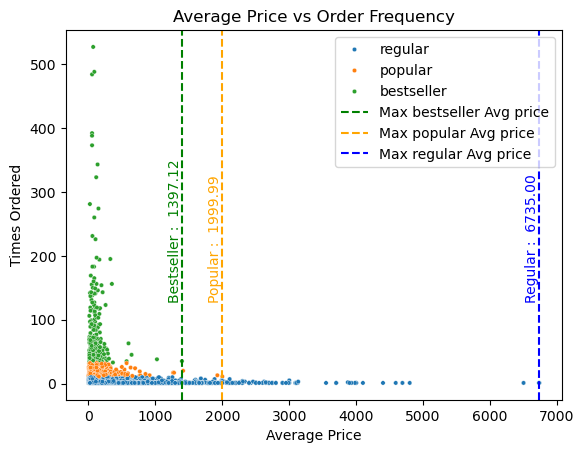

In [42]:
sns.scatterplot(data = price_vs_orders, x = 'avg_price', y = 'times_ordered', s = 10, hue = 'product_tier')
plt.xlabel('Average Price')
plt.ylabel('Times Ordered')
plt.title('Average Price vs Order Frequency')

colors = {'bestseller': 'green', 'popular': 'orange', 'regular': 'blue'}
for tier, color in colors.items():
    max_price = price_vs_orders[price_vs_orders['product_tier'] == tier]['avg_price'].max()
    plt.axvline(max_price, color=color, linestyle='--', label=f'Max {tier} Avg price')
    plt.text(max_price, price_vs_orders['times_ordered'].max() * 0.25, f"{tier.title()} : {max_price : .2f}", color = color, rotation = 90,
            ha = 'right')
plt.legend()
plt.show()

Tiers defined by times_ordered cutoffs (from earlier percentile scan): regular < 11, popular 11–32, bestseller ≥ 33.  
Checked max avg_price per tier via axvline: bestseller ≤ 1397.12, popular ≤ 1999.99, regular ≤ 6735.00 (regular spans full price range, ceiling not meaningful).  
No bestseller or popular product has avg_price above ~2000 — high order volume only occurs at lower prices, but low price alone doesn't guarantee high order volume (regular tier includes cheap products too).

**Imp Note :**
*All of this is irrespective of order_status, based purely on order_items — reflects purchases, not confirmed/delivered orders. Could shift if relational integrity issues exist (e.g. orphan rows, parent order in orders table with no matching child here).*

In [43]:
# olist_order_payments_dataset : ['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

**`olist_order_payments_dataset` — key findings**

- 103,886 rows, 5 columns, no nulls in any column.
- `order_id`: str, 99,440 unique values, top = `fa65dad1b0e818e3ccc5cb0e39231352`, freq 29.
- `payment_sequential`: int64, 29 unique values. Range: min 1, max 29. Mean 1.09, std 0.71. Percentiles: 25% = 1, 50% = 1, 75% = 1.
- `payment_type`: str, 5 unique values, top = `credit_card`, freq 76,795.
- `payment_installments`: int64, 24 unique values. Range: min 0, max 24. Mean 2.85, std 2.69. Percentiles: 25% = 1, 50% = 1, 75% = 4.
- `payment_value`: float64, 29,077 unique values. Range: min 0.00, max 13,664.08. Mean 154.10, std 217.49. Percentiles: 25% = 56.79, 50% = 100.00, 75% = 171.84.

In [44]:
Query = """SELECT order_id, 
CAST(payment_sequential AS INT) AS payment_sequential, payment_type, 
CAST(payment_installments AS INT) AS payment_installments, payment_value
FROM olist_order_payments_dataset"""

df5 = pd.read_sql(Query, engine)
df5

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
...,...,...,...,...,...
103881,0406037ad97740d563a178ecc7a2075c,1,boleto,1,363.31
103882,7b905861d7c825891d6347454ea7863f,1,credit_card,2,96.80
103883,32609bbb3dd69b3c066a6860554a77bf,1,credit_card,1,47.77
103884,b8b61059626efa996a60be9bb9320e10,1,credit_card,5,369.54


In [45]:
query = """SELECT payment_type, COUNT(*) AS count
FROM olist_order_payments_dataset
GROUP BY payment_type
ORDER BY count DESC"""
# could use value_counts() but kept in SQL for consistency
pay_type_check = pd.read_sql(query, engine)
pay_type_check

,payment_type,count
0,credit_card,76795
1,boleto,19784
2,voucher,5775
3,debit_card,1529
4,not_defined,3


payment_type counts are irrespective of order_status — this table has no status column,  
reflects payment behavior only, not linked to order outcome here.

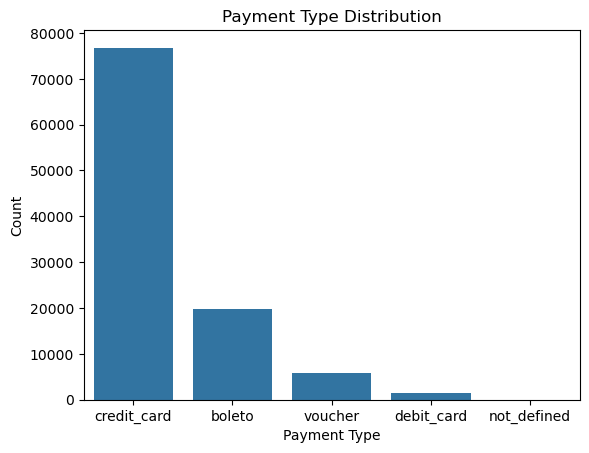

In [46]:
sns.barplot(data = pay_type_check, x = 'payment_type', y = 'count')
plt.xlabel('Payment Type')
plt.ylabel('Count')
plt.title('Payment Type Distribution')
plt.show()

In [47]:
# Investigate the 3 'not_defined' payment_type rows - missing payment method, real value or 0?
query = """SELECT * FROM olist_order_payments_dataset
WHERE payment_type = 'not_defined'"""
not_defined_check = pd.read_sql(query, engine)
not_defined_check

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,4637ca194b6387e2d538dc89b124b0ee,1,not_defined,1,0.0
1,00b1cb0320190ca0daa2c88b35206009,1,not_defined,1,0.0
2,c8c528189310eaa44a745b8d9d26908b,1,not_defined,1,0.0


not_defined rows all have payment_value = 0.0 — missing/placeholder entries, not real payments.

In [48]:
# payment_value_validation
# Check if payment_value <= 0 exists beyond the 3 'not_defined' rows, or is isolated to them
query = """SELECT COUNT(*) AS violations
FROM olist_order_payments_dataset
WHERE payment_value = 0"""
pay_val_check = pd.read_sql(query, engine)
pay_val_check

,violations
0,9


In [49]:
# All 9 payment_value <= 0 rows - checking which payment_types they belong to
query = """SELECT *
FROM olist_order_payments_dataset
WHERE payment_value = 0"""
pay_val_check = pd.read_sql(query, engine)
pay_val_check

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,8bcbe01d44d147f901cd3192671144db,4,voucher,1,0.0
1,fa65dad1b0e818e3ccc5cb0e39231352,14,voucher,1,0.0
2,6ccb433e00daae1283ccc956189c82ae,4,voucher,1,0.0
3,4637ca194b6387e2d538dc89b124b0ee,1,not_defined,1,0.0
4,00b1cb0320190ca0daa2c88b35206009,1,not_defined,1,0.0
5,45ed6e85398a87c253db47c2d9f48216,3,voucher,1,0.0
6,fa65dad1b0e818e3ccc5cb0e39231352,13,voucher,1,0.0
7,c8c528189310eaa44a745b8d9d26908b,1,not_defined,1,0.0
8,b23878b3e8eb4d25a158f57d96331b18,4,voucher,1,0.0


In [50]:
pay_val_check['payment_type'].value_counts()

payment_type
voucher        6
not_defined    3
Name: count, dtype: int64

All known Olist payment methods (credit_card, debit_card, boleto, voucher) involve payment before/at order time — none are cash-on-delivery.   
A payment_value = 0 row is inconsistent with this, though not fully explainable from this table alone.   
3 rows are not_defined payment_type, payment_sequential = 1 — since the payment method itself is unrecorded, the cause of the 0 value is uncertain; may reflect a genuinely unrecorded payment process, not necessarily an error.   
6 rows are voucher, payment_sequential 3–14 — part of a multi-payment order. Voucher is a known, defined method, so a 0 value here raises a different question than the not_defined cases — not yet resolved.   

Will revisit once relational integrity (orphan rows, order_status linkage) is checked in the cross-table section — may clarify whether these tie to canceled/unavailable orders or something else.

In [51]:
# payment_installments validity check 
query = """SELECT COUNT(*) AS violations
FROM olist_order_payments_dataset
WHERE payment_installments < 1"""
pay_inst_check = pd.read_sql(query, engine)
pay_inst_check

,violations
0,2


In [52]:
# full view of violating rows (should never be < 1)
query = """SELECT *
FROM olist_order_payments_dataset
WHERE payment_installments < 1"""
pay_inst_check = pd.read_sql(query, engine)
pay_inst_check

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,744bade1fcf9ff3f31d860ace076d422,2,credit_card,0,58.69
1,1a57108394169c0b47d8f876acc9ba2d,2,credit_card,0,129.94


Both are credit_card, payment_sequential = 2, with a real, non-zero payment_value (58.69 and 129.94).   
payment_installments = 0 is invalid on its own — likely a data quality issue, since the payment itself appears real.   
Order status/integrity not yet checked — will revisit in the cross-table section.

In [53]:
# Checking which payment_types actually use installments > 1 
# not every payment method (e.g. voucher) should logically support installments, so this flags where >1 occurs
query = """SELECT payment_type, COUNT(*) AS count
FROM olist_order_payments_dataset
WHERE payment_installments > 1
GROUP BY payment_type"""
pay_inst_check = pd.read_sql(query, engine)
pay_inst_check

,payment_type,count
0,credit_card,51338


Installments > 1 occur only for credit_card - consistent with the hypothesis that  
Other payment types (voucher, boleto, debit_card) don't support installment splitting.

In [54]:
# Sequential integrity check - payment-row grain
query = """WITH ranked AS (
    SELECT order_id, payment_sequential,
    ROW_NUMBER() OVER (PARTITION BY order_id ORDER BY payment_sequential) AS expected_seq
    FROM olist_order_payments_dataset)
SELECT COUNT(*) AS violations
FROM ranked
WHERE payment_sequential != expected_seq"""
seq_int_check = pd.read_sql(query, engine)
seq_int_check

,violations
0,82


In [55]:
# 82 rows have payment_sequential inconsistencies (gaps/duplicates)

In [56]:
df5_sorted = df5.sort_values('payment_sequential')
df5_sorted['expected_seq'] = df5_sorted.groupby('order_id').cumcount() + 1
violations = df5_sorted[df5_sorted['payment_sequential'] != df5_sorted['expected_seq']]
violations['order_id'].nunique()

80

80 distinct orders affected (order-grain) vs 82 row-level violations (payment-row grain) -
some orders have more than one violating row, but exact distribution not confirmed.

In [57]:
query = """WITH ranked AS (
SELECT order_id, payment_sequential,
ROW_NUMBER() OVER (PARTITION BY order_id ORDER BY payment_sequential) AS expected_seq
FROM olist_order_payments_dataset)
SELECT order_id, COUNT(*) AS violation_count
FROM ranked
WHERE payment_sequential != expected_seq
GROUP BY order_id
HAVING COUNT(*) > 1"""
multiple_violations = pd.read_sql(query, engine)
multiple_violations

,order_id,violation_count
0,a079628ac8002126e75f86b0f87332e4,2
1,a4431cbd79dbddaae7988ce6091cbc3c,2


In [58]:
df5[df5['order_id'].isin(multiple_violations['order_id'])]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
10258,a079628ac8002126e75f86b0f87332e4,3,credit_card,3,102.82
36471,a079628ac8002126e75f86b0f87332e4,2,debit_card,1,50.00
60572,a4431cbd79dbddaae7988ce6091cbc3c,2,debit_card,1,26.20
90465,a4431cbd79dbddaae7988ce6091cbc3c,3,debit_card,1,20.00


In [59]:
# Confirmed: 2 orders each have 2 violating rows. Both orders are missing payment_sequential = 1

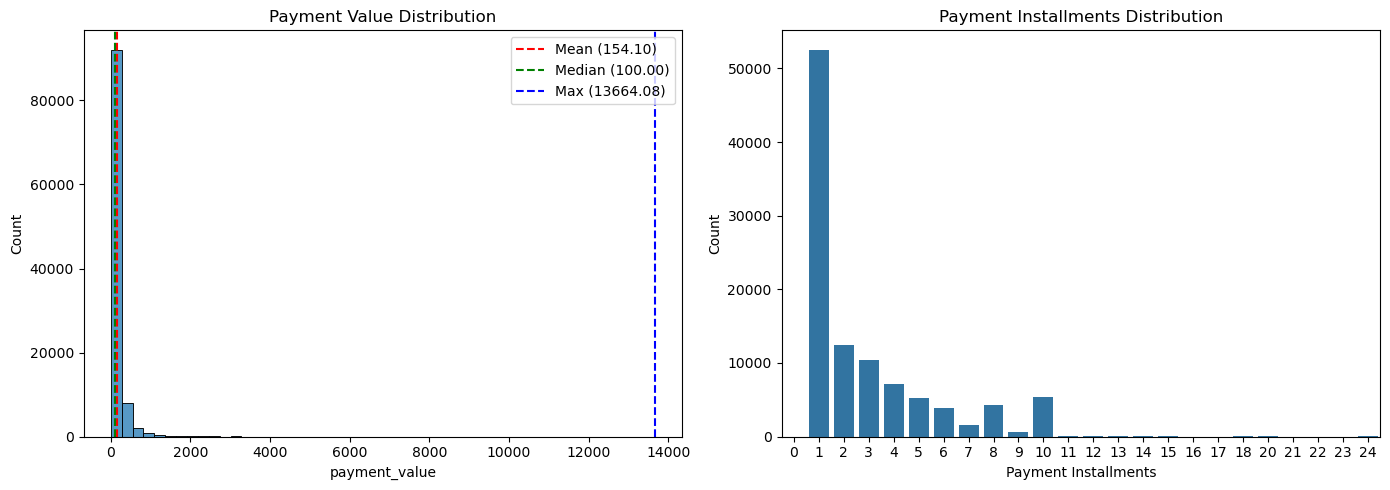

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df5['payment_value'], bins = 50, ax=axes[0])
axes[0].axvline(df5['payment_value'].mean(), color='red', linestyle='--', label=f'Mean ({df5["payment_value"].mean():.2f})')
axes[0].axvline(df5['payment_value'].median(), color='green', linestyle='--', label=f'Median ({df5["payment_value"].median():.2f})')
axes[0].axvline(df5['payment_value'].max(), color='blue', linestyle='--', label=f'Max ({df5["payment_value"].max():.2f})')
axes[0].set_title('Payment Value Distribution')
axes[0].legend(loc = 'upper right')

installment_counts = df5['payment_installments'].value_counts().sort_index()
sns.barplot(x=installment_counts.index, y=installment_counts.values, ax=axes[1])
axes[1].set_title('Payment Installments Distribution')
axes[1].set_xlabel('Payment Installments')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

Both are at payment-record grain (per payment_sequential row, not per order), unfiltered by status.  
payment_installments: mode is 1 (most payments made in full, no splitting); counts decline after that, with some rare values extending out to 24 — likely genuine but sparse, not confirmed further.  
payment_value: extreme right-skew — high volume of low-value payments; mean (154.10) pulled well above median (100.00) by a small number of very large payments, with max (13,664.08) far removed from the bulk of the data.

In [61]:
# Correlation between installments and payment value
df5[['payment_installments', 'payment_value']].corr()

,payment_installments,payment_value
payment_installments,1.000000,0.330811
payment_value,0.330811,1.000000


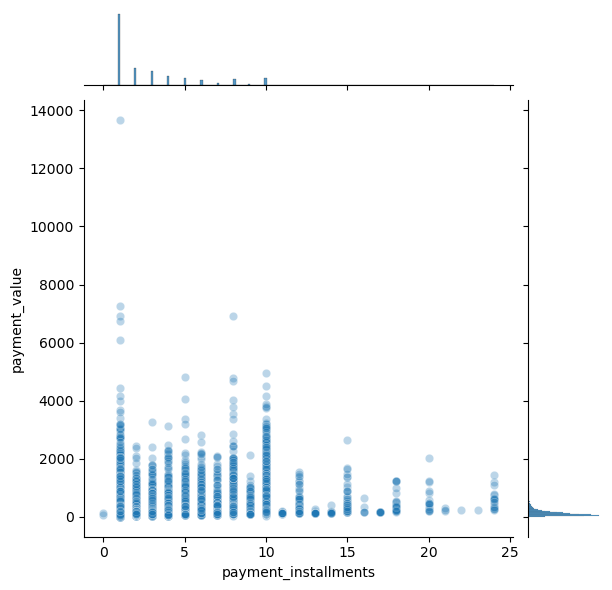

In [62]:
sns.jointplot(data=df5, x='payment_installments', y='payment_value', kind='scatter', alpha=0.3)
plt.show()

Correlation: 0.33 — weak-to-moderate positive relationship, not strong.  
Extreme high-value payments (13,664, ~7,000-7,300) occur at low installment counts (mostly 1) — the largest payments aren't the ones being split into many installments.  
Across most installment counts, payment_value stays similarly bounded   
--> installment count is only weakly related to payment size — customers don't consistently split higher-value payments into more installments.

In [63]:
# olist_order_reviews_dataset : ['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

**`olist_order_reviews_dataset` — key findings**

- 99,224 rows, 7 columns.
- `review_id`: str, 98,410 unique values, top = `c444278834184f72b1484dfe47de7f97`, freq 3, 0 nulls.
- `order_id`: str, 98,673 unique values, top = `c88b1d1b157a9999ce368f218a407141`, freq 3, 0 nulls.
- `review_score`: int64, 5 unique values. Range: min 1, max 5. Mean 4.09, std 1.35. Percentiles: 25% = 4, 50% = 5, 75% = 5. 0 nulls.
- `review_comment_title`: str, 4,527 unique values, top = `Recomendo`, freq 423, 87,656 nulls.
- `review_comment_message`: str, 36,159 unique values, top = `Muito bom`, freq 230, 58,247 nulls.
- `review_creation_date`: str, 636 unique values, top = `2017-12-19 00:00:00`, freq 463, 0 nulls.
- `review_answer_timestamp`: str, 98,248 unique values, top = `2017-06-15 23:21:05`, freq 4, 0 nulls.

In [64]:
Query = """SELECT review_id, order_id,
CAST(review_score AS integer) AS review_score,
review_comment_title,review_comment_message,
CAST(review_creation_date AS timestamp) AS review_creation_date,
CAST(review_answer_timestamp AS timestamp) AS review_answer_timestamp
FROM olist_order_reviews_dataset"""

df6 = pd.read_sql(Query, engine)
df6

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:53
...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01,2018-07-02 12:59:13


##### This table has no order_status column and was not joined to orders - all analysis here is irrespective of order_status and may shift once relational integrity checks (orphan rows, fan-out, order_id with no matching review) are applied in Section 3.

In [65]:
# Review score counts 
query = """SELECT review_score, COUNT(*) AS count_of_reviews
FROM olist_order_reviews_dataset
GROUP BY review_score
ORDER BY count_of_reviews DESC"""
review_score_check = pd.read_sql(query, engine)
review_score_check

,review_score,count_of_reviews
0,5,57328
1,4,19142
2,1,11424
3,3,8179
4,2,3151


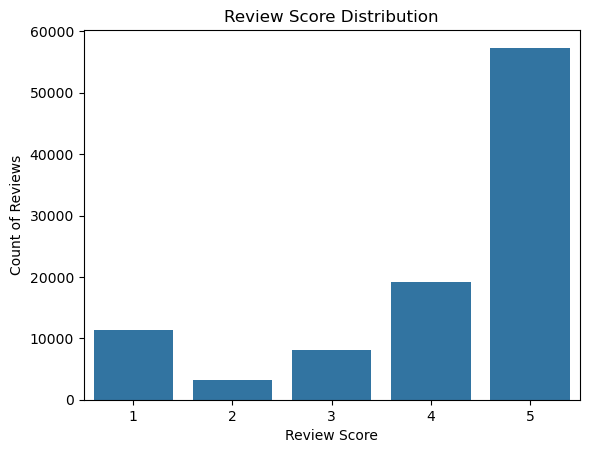

In [66]:
sns.barplot(data = review_score_check, x = 'review_score', y = 'count_of_reviews')
plt.xlabel('Review Score')
plt.ylabel('Count of Reviews')
plt.title('Review Score Distribution')
plt.show()

In [67]:
# Date logic check
query = """SELECT COUNT(*) AS violations
FROM olist_order_reviews_dataset
WHERE CAST(review_creation_date AS TIMESTAMP) > CAST(review_answer_timestamp AS TIMESTAMP)"""
date_check = pd.read_sql(query, engine)
date_check

,violations
0,0


In [68]:
# Composite Key check
total_rows = len(df6)
unique_pairs = len(df6.drop_duplicates(subset=['review_id', 'order_id']))
print(total_rows, unique_pairs)

99224 99224


(review_id, order_id) forms a clean composite key — 99,224 total rows, 99,224 unique pairs, no duplicates.

In [69]:
# Composite key confirmed clean (no repeating pairs) — so any duplication in review_id or order_id must come from one repeating while paired with a different value on the other side
# Checking how many review_ids repeat across different order_ids, and how many order_ids repeat across different review_ids

In [70]:
# Total rows affected by review_id duplication 
int(df6['review_id'].duplicated().sum())

814

In [71]:
# Count of distinct review_ids linked to more than one order_id
query = """WITH review_order_counts AS (
    SELECT review_id, COUNT(DISTINCT order_id) AS distinct_orders
    FROM olist_order_reviews_dataset
    GROUP BY review_id
)
SELECT COUNT(*) AS violations
FROM review_order_counts
WHERE distinct_orders > 1"""
id_check = pd.read_sql(query, engine)
id_check

,violations
0,789


review_id duplication: 814 total rows affected, 789 distinct review_ids linked to more than one order_id.

In [72]:
# Total rows affected by order_id duplication (pandas, df already loaded)
int(df6['order_id'].duplicated().sum())

551

In [73]:
# Count of distinct order_ids linked to more than one review_id
query = """WITH order_review_counts AS (
    SELECT order_id, COUNT(DISTINCT review_id) AS distinct_reviews
    FROM olist_order_reviews_dataset
    GROUP BY order_id
)
SELECT COUNT(*) AS violations
FROM order_review_counts
WHERE distinct_reviews > 1"""
order_check = pd.read_sql(query, engine)
order_check

,violations
0,547


order_id duplication: 551 total rows affected, 547 distinct order_ids linked to more than one review_id.

#### Two related but distinct anomalies - not the same issue viewed twice
##### review_id -> multiple order_ids AND order_id -> multiple review_ids can overlap, creating many-to-many-like behavior in what should be a one-to-many relationship (order -> review)

In [74]:
# When joining reviews with orders, latest review per order_id will be used based on review_answer_timestamp

In [75]:
(df6['review_answer_timestamp'] - df6['review_creation_date']).dt.days.quantile([0.5, 0.75, 0.90, 0.95, 0.99, 1.0])

0.50      1.0
0.75      3.0
0.90      4.0
0.95      6.0
0.99     22.0
1.00    518.0
dtype: float64

In [76]:
query = """SELECT review_id, order_id, review_score,
CAST(review_creation_date AS timestamp) AS review_creation_date,
CAST(review_answer_timestamp AS timestamp) AS review_answer_timestamp,
EXTRACT(DAY FROM (CAST(review_answer_timestamp AS timestamp) - CAST(review_creation_date AS timestamp))) AS response_time,
CASE 
WHEN EXTRACT(DAY FROM (CAST(review_answer_timestamp AS timestamp) - CAST(review_creation_date AS timestamp))) < 6 THEN 'fast'
WHEN EXTRACT(DAY FROM (CAST(review_answer_timestamp AS timestamp) - CAST(review_creation_date AS timestamp))) < 22 THEN 'slow'
ELSE 'very_late'
END AS response_speed
FROM olist_order_reviews_dataset"""
response_df = pd.read_sql(query, engine)
response_df

,review_id,order_id,review_score,review_creation_date,review_answer_timestamp,response_time,response_speed
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,2018-01-18,2018-01-18 21:46:59,0.0,fast
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,2018-03-10,2018-03-11 03:05:13,1.0,fast
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,2018-02-17,2018-02-18 14:36:24,1.0,fast
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,2017-04-21,2017-04-21 22:02:06,0.0,fast
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,2018-03-01,2018-03-02 10:26:53,1.0,fast
...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,2018-07-07,2018-07-14 17:18:30,7.0,slow
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,2017-12-09,2017-12-11 20:06:42,2.0,fast
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,2018-03-22,2018-03-23 09:10:43,1.0,fast
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,2018-07-01,2018-07-02 12:59:13,1.0,fast


In [77]:
query = """WITH ranked AS (
SELECT review_id, order_id, review_score,
CAST(review_creation_date AS timestamp) AS review_creation_date,
CAST(review_answer_timestamp AS timestamp) AS review_answer_timestamp,
EXTRACT(DAY FROM ((CAST(review_answer_timestamp AS timestamp) - CAST(review_creation_date AS timestamp)))) AS response_time,
ROW_NUMBER() OVER (PARTITION BY order_id ORDER BY review_answer_timestamp DESC) AS rn,
CASE 
WHEN EXTRACT(DAY FROM (CAST(review_answer_timestamp AS timestamp) - CAST(review_creation_date AS timestamp))) < 6 THEN 'fast'
WHEN EXTRACT(DAY FROM (CAST(review_answer_timestamp AS timestamp) - CAST(review_creation_date AS timestamp))) < 22 THEN 'slow'
ELSE 'very_late'
END AS response_speed
FROM olist_order_reviews_dataset)
SELECT review_id, order_id, review_score, review_creation_date, review_answer_timestamp, response_time, response_speed
FROM ranked
WHERE rn = 1"""
response_df_latest = pd.read_sql(query, engine)
response_df_latest

,review_id,order_id,review_score,review_creation_date,review_answer_timestamp,response_time,response_speed
0,97ca439bc427b48bc1cd7177abe71365,00010242fe8c5a6d1ba2dd792cb16214,5,2017-09-21,2017-09-22 10:57:03,1.0,fast
1,7b07bacd811c4117b742569b04ce3580,00018f77f2f0320c557190d7a144bdd3,4,2017-05-13,2017-05-15 11:34:13,2.0,fast
2,0c5b33dea94867d1ac402749e5438e8b,000229ec398224ef6ca0657da4fc703e,5,2018-01-23,2018-01-23 16:06:31,0.0,fast
3,f4028d019cb58564807486a6aaf33817,00024acbcdf0a6daa1e931b038114c75,4,2018-08-15,2018-08-15 16:39:01,0.0,fast
4,940144190dcba6351888cafa43f3a3a5,00042b26cf59d7ce69dfabb4e55b4fd9,5,2017-03-02,2017-03-03 10:54:59,1.0,fast
...,...,...,...,...,...,...,...
98668,9185f849f32d82e216a4e025e0c50f5c,fffc94f6ce00a00581880bf54a75a037,5,2018-05-11,2018-05-14 12:53:47,3.0,fast
98669,be803f6a93d64719fd685c1cc610918a,fffcd46ef2263f404302a634eb57f7eb,5,2018-07-24,2018-07-25 09:25:29,1.0,fast
98670,dbdd81cd59a1a9f94a10a990b4d48dce,fffce4705a9662cd70adb13d4a31832d,5,2017-10-29,2017-10-29 21:33:52,0.0,fast
98671,fba117c9ac40d41ca7be54741f471303,fffe18544ffabc95dfada21779c9644f,5,2017-08-17,2017-08-18 12:24:05,1.0,fast


In [78]:
df6.shape[0], df6['order_id'].nunique()

(99224, 98673)

In [79]:
# Number of rows -> verified 

In [80]:
counts_all = response_df.groupby('review_score')['response_speed'].value_counts(normalize=True).reset_index()
counts_latest = response_df_latest.groupby('review_score')['response_speed'].value_counts(normalize=True).reset_index()

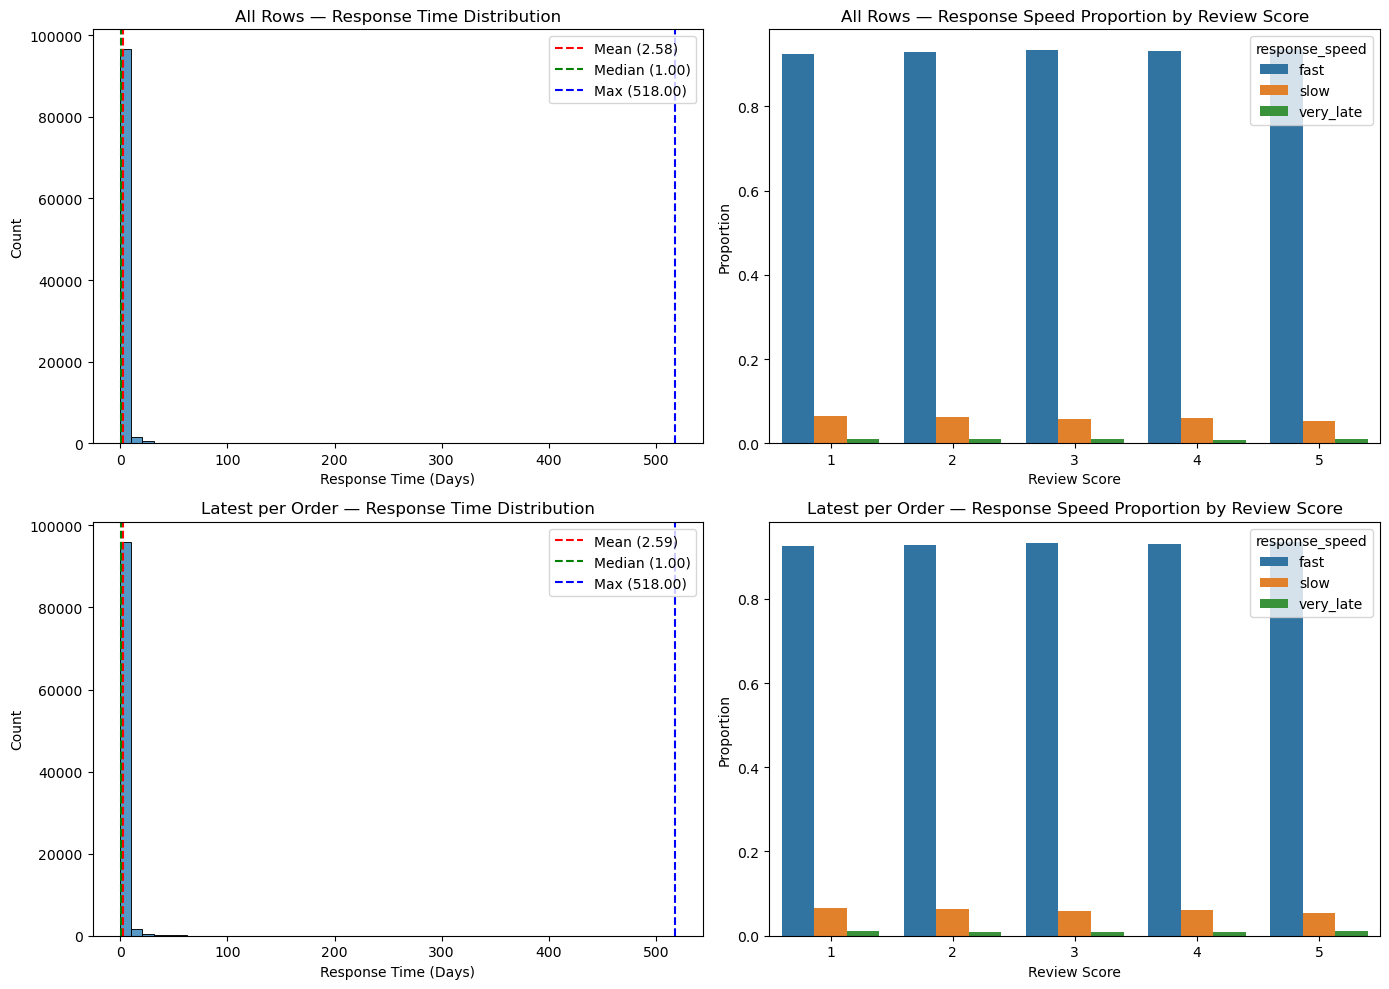

In [81]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# All rows — response_time alone
sns.histplot(response_df['response_time'], bins=50, ax=axes[0,0])
axes[0,0].axvline(response_df['response_time'].mean(), color='red', linestyle='--', label=f"Mean ({response_df['response_time'].mean():.2f})")
axes[0,0].axvline(response_df['response_time'].median(), color='green', linestyle='--', label=f"Median ({response_df['response_time'].median():.2f})")
axes[0,0].axvline(response_df['response_time'].max(), color='blue', linestyle='--', label=f"Max ({response_df['response_time'].max():.2f})")
axes[0,0].set_title('All Rows — Response Time Distribution')
axes[0,0].set_xlabel('Response Time (Days)')
axes[0,0].legend(loc='upper right')

# All rows — response_speed proportion by review_score
sns.barplot(data=counts_all, x='review_score', y='proportion', hue='response_speed', ax=axes[0,1])
axes[0,1].set_title('All Rows — Response Speed Proportion by Review Score')
axes[0,1].set_xlabel('Review Score')
axes[0,1].set_ylabel('Proportion')

# Deduped — response_time alone
sns.histplot(response_df_latest['response_time'], bins=50, ax=axes[1,0])
axes[1,0].axvline(response_df_latest['response_time'].mean(), color='red', linestyle='--', label=f"Mean ({response_df_latest['response_time'].mean():.2f})")
axes[1,0].axvline(response_df_latest['response_time'].median(), color='green', linestyle='--', label=f"Median ({response_df_latest['response_time'].median():.2f})")
axes[1,0].axvline(response_df_latest['response_time'].max(), color='blue', linestyle='--', label=f"Max ({response_df_latest['response_time'].max():.2f})")
axes[1,0].set_title('Latest per Order — Response Time Distribution')
axes[1,0].set_xlabel('Response Time (Days)')
axes[1,0].legend(loc='upper right')

# Deduped — response_speed proportion by review_score
sns.barplot(data=counts_latest, x='review_score', y='proportion', hue='response_speed', ax=axes[1,1])
axes[1,1].set_title('Latest per Order — Response Speed Proportion by Review Score')
axes[1,1].set_xlabel('Review Score')
axes[1,1].set_ylabel('Proportion')

plt.tight_layout()
plt.show()

Mean response time 2.58-2.59 days, median 1 day, max 518 days — heavily right-skewed, all-rows and deduped versions nearly identical.  
Response speed proportions (fast <6, slow 6-22, very_late ≥22 days) are consistent across all review scores — ~92-94% fast, ~5-6% slow, ~1% very_late in every group.  
No meaningful relationship between response time and review score

In [82]:
# olist_products_dataset : ['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

In [83]:
# product_name_lenght, product_description_lenght --> spelling mistake

**`olist_products_dataset` — key findings**

- 32,951 rows, 9 columns.
- `product_id`: str, 32,951 unique values (fully unique)
- `product_category_name`: str, 73 unique values, top = `cama_mesa_banho`, freq 3,029, 610 nulls.
- `product_name_lenght`: float64, 66 unique values. Range: min 5, max 76. Mean 48.48, std 10.25. Percentiles: 25% = 42, 50% = 51, 75% = 57. 610 nulls.
- `product_description_lenght`: float64, 2,960 unique values. Range: min 4, max 3,992. Mean 771.50, std 635.12. Percentiles: 25% = 339, 50% = 595, 75% = 972. 610 nulls.
- `product_photos_qty`: float64, 19 unique values. Range: min 1, max 20. Mean 2.19, std 1.74. Percentiles: 25% = 1, 50% = 1, 75% = 3. 610 nulls.
- `product_weight_g`: float64, 2,204 unique values. Range: min 0, max 40,425. Mean 2,276.47, std 4,282.04. Percentiles: 25% = 300, 50% = 700, 75% = 1,900. 2 nulls.
- `product_length_cm`: float64, 99 unique values. Range: min 7, max 105. Mean 30.82, std 16.91. Percentiles: 25% = 18, 50% = 25, 75% = 38. 2 nulls.
- `product_height_cm`: float64, 102 unique values. Range: min 2, max 105. Mean 16.94, std 13.64. Percentiles: 25% = 8, 50% = 13, 75% = 21. 2 nulls.
- `product_width_cm`: float64, 95 unique values. Range: min 6, max 118. Mean 23.20, std 12.08. Percentiles: 25% = 15, 50% = 20, 75% = 30. 2 nulls.

In [84]:
Query = """SELECT
product_id,
product_category_name,
CAST(product_name_lenght AS integer) AS product_name_length, 
CAST(product_description_lenght AS integer) AS product_description_length,
CAST(product_photos_qty AS integer) AS product_photos_qty,
product_weight_g,
product_length_cm,
product_height_cm,
product_width_cm
FROM olist_products_dataset"""

# spelling mistakes corrected in the dataframe
df7 = pd.read_sql(Query, engine)
df7

,product_id,product_category_name,product_name_length,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0
...,...,...,...,...,...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,45.0,67.0,2.0,12300.0,40.0,40.0,40.0
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,41.0,971.0,1.0,1700.0,16.0,19.0,16.0
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,50.0,799.0,1.0,1400.0,27.0,7.0,27.0
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,60.0,156.0,2.0,700.0,31.0,13.0,20.0


In [85]:
# product_category_name, product_name_lenght, product_description_lenght, product_photos_qty
# All of these have 610 null values
# Checking if these null values for all these columns are for same products or not

In [86]:
query = """SELECT COUNT(*)
FROM olist_products_dataset
WHERE product_category_name IS NULL
AND product_name_lenght IS NULL
AND product_description_lenght IS NULL
AND product_photos_qty IS NULL;"""

check = pd.read_sql(query, engine)
check

,count
0,610


610 products have no category name, name length, description length, or photos qty — same 610 rows across all four columns

In [87]:
# product_weight_g, product_length_cm, product_height_cm, product_width_cm
# All of these have 2 null values
# Checking if these null values for all these columns are for same products or not

In [88]:
query = """SELECT COUNT(*) 
FROM olist_products_dataset
WHERE product_weight_g IS NULL
AND product_length_cm IS NULL
AND product_height_cm IS NULL
AND product_width_cm IS NULL;"""
check = pd.read_sql(query, engine)
check

,count
0,2


2 products have no weight, length, height, or width — same 2 rows across all four columns

In [89]:
dim_cols = ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
df7[df7[dim_cols].isna().all(axis=1)]

,product_id,product_category_name,product_name_length,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
8578,09ff539a621711667c43eba6a3bd8466,bebes,60.0,865.0,3.0,NaN,NaN,NaN,NaN
18851,5eb564652db742ff8f28759cd8d2652a,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [90]:
# Checking if any product has absolutely nothing
query = """SELECT COUNT(*) as violations
FROM olist_products_dataset
WHERE product_category_name IS NULL
AND product_name_lenght IS NULL
AND product_description_lenght IS NULL
AND product_photos_qty IS NULL
AND product_weight_g IS NULL
AND product_length_cm IS NULL
AND product_height_cm IS NULL
AND product_width_cm IS NULL;"""

check = pd.read_sql(query, engine)
check

,violations
0,1


1 product has no information at all — every column is null except product_id — a completely empty row

In [91]:
df7[df7.drop(columns='product_id').isna().all(axis=1)]

,product_id,product_category_name,product_name_length,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
18851,5eb564652db742ff8f28759cd8d2652a,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Unique null-pattern groups in products:  
1 row -> completely empty (all columns null except product_id)  
609 rows -> only category, name length, description length, and photos qty missing  
1 row -> only weight, length, height, and width missing

In [92]:
# Product category distribution
query = """WITH cte AS (
SELECT COALESCE(product_category_name, 'Missing') AS product_category_name, COUNT(*) as count,
((SUM(COUNT(*)) OVER(ORDER BY COUNT(*) DESC ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) * 1.0) / SUM(COUNT(*)) OVER()) AS cumulative_distribution
FROM olist_products_dataset
GROUP BY COALESCE(product_category_name, 'Missing')),
cte2 AS (
SELECT *, LAG(cumulative_distribution) OVER (ORDER BY count DESC) AS prev_cum
FROM cte)
SELECT product_category_name, count, cumulative_distribution FROM cte2
WHERE cumulative_distribution <= 0.8 OR prev_cum <= 0.8
ORDER BY count DESC;"""

check = pd.read_sql(query, engine)
check

,product_category_name,count,cumulative_distribution
0,cama_mesa_banho,3029,0.091924
1,esporte_lazer,2867,0.178932
2,moveis_decoracao,2657,0.259567
3,beleza_saude,2444,0.333738
4,utilidades_domesticas,2335,0.404601
5,automotivo,1900,0.462262
6,informatica_acessorios,1639,0.512003
7,brinquedos,1411,0.554824
8,relogios_presentes,1329,0.595156
9,telefonia,1134,0.629571


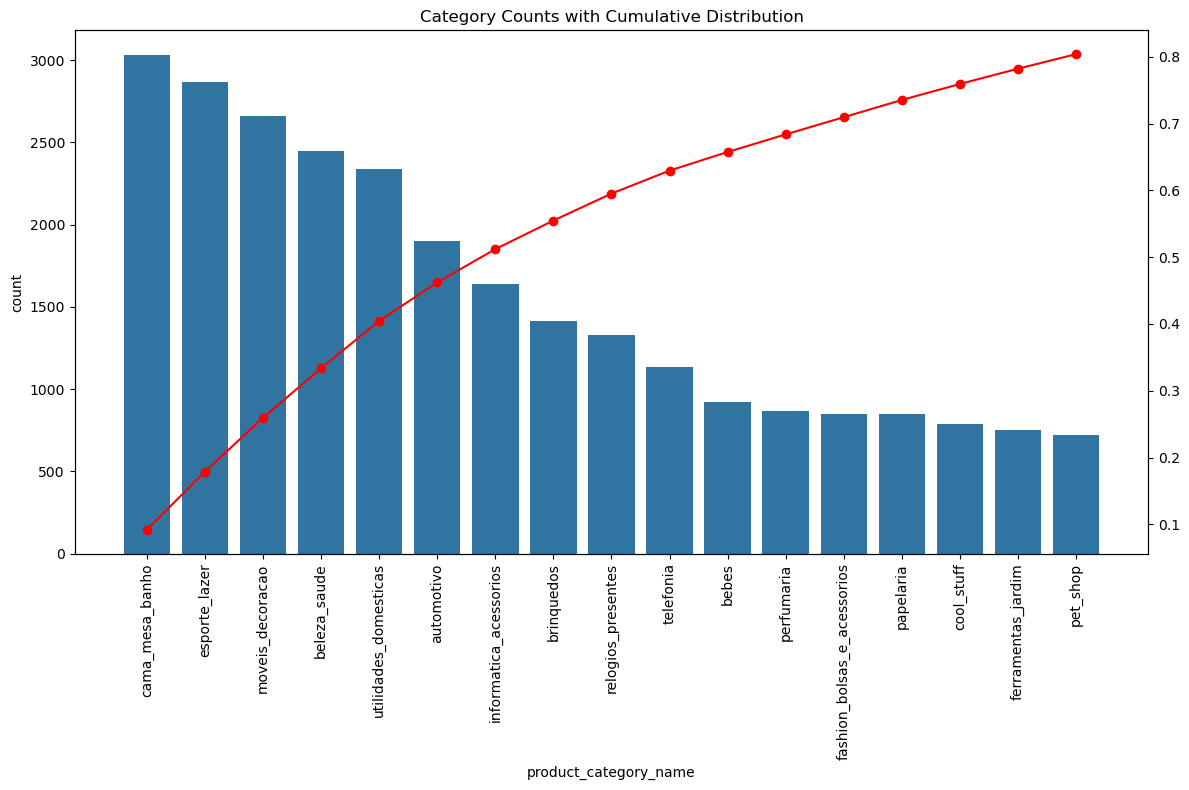

In [93]:
fig, ax1 = plt.subplots(figsize=(12,8))

sns.barplot(data=check, x='product_category_name', y='count', ax=ax1)
plt.xticks(rotation=90)

ax1_twin = ax1.twinx()
ax1_twin.plot(check['product_category_name'], check['cumulative_distribution'], marker='o', color='red')

plt.title('Category Counts with Cumulative Distribution')
plt.tight_layout()
plt.show()

Top 17 categories (out of 74, including "Missing") account for ~80% of all products. cama_mesa_banho, esporte_lazer, and moveis_decoracao are the top 3 contributors.   
The cumulative curve rises steadily through the top 10-12 categories before flattening — a small subset of categories carries most of the product catalog.

In [94]:
# Dimension validity check — length/height/width already have valid positive minimums 
# so only weight needs checking for zero values
query = """SELECT COUNT(*) as violations FROM olist_products_dataset
WHERE product_weight_g = 0;"""
dimension_violations = pd.read_sql(query, engine)
dimension_violations

,violations
0,4


4 products have product_weight_g = 0 — a data quality issue, since weight can't genuinely be zero for a physical product.

In [95]:
df7[df7['product_weight_g'] == 0]

,product_id,product_category_name,product_name_length,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
9769,81781c0fed9fe1ad6e8c81fca1e1cb08,cama_mesa_banho,51.0,529.0,1.0,0.0,30.0,25.0,30.0
13683,8038040ee2a71048d4bdbbdc985b69ab,cama_mesa_banho,48.0,528.0,1.0,0.0,30.0,25.0,30.0
14997,36ba42dd187055e1fbe943b2d11430ca,cama_mesa_banho,53.0,528.0,1.0,0.0,30.0,25.0,30.0
32079,e673e90efa65a5409ff4196c038bb5af,cama_mesa_banho,53.0,528.0,1.0,0.0,30.0,25.0,30.0


4 products have product_weight_g = 0, all in cama_mesa_banho with near-identical dimensions (30x25x30 cm) and similar name/description lengths.  
Given this is the largest category (3,029 products), one idea is that these represent the same or similar product listed by multiple sellers — larger categories naturally have more opportunity for this kind of repeated listing.   
#### Not confirmed from available columns

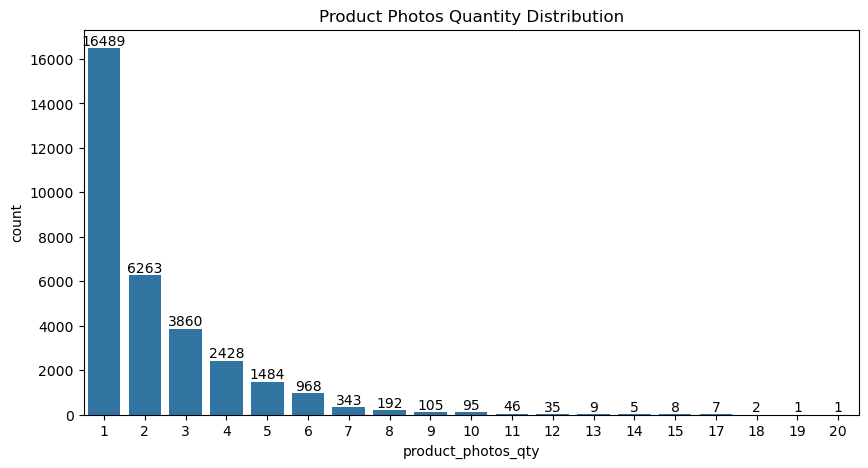

In [96]:
plt.figure(figsize=(10,5))
sns.countplot(x=df7['product_photos_qty'].dropna().astype(int))
for i, value in enumerate(df7['product_photos_qty'].value_counts().sort_index()):
    plt.text(i, value, str(value), ha = 'center', va = 'bottom')
plt.title('Product Photos Quantity Distribution')
plt.show()

In [97]:
# olist_sellers_dataset : ['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state']

**`olist_sellers_dataset` — key findings**

- 3,095 rows, 4 columns, no nulls in any column.
- `seller_id`: str, 3,095 unique values (fully unique), top = `3442f8959a84dea7ee197c632cb2df15`, freq 1.
- `seller_zip_code_prefix`: int64, 2,246 unique values. Range: min 1,001, max 99,730. Mean 32,291.06, std 32,713.45. Percentiles: 25% = 7,093.5, 50% = 14,940, 75% = 64,552.5.
- `seller_city`: str, 611 unique values, top = `sao paulo`, freq 694.
- `seller_state`: str, 23 unique values, top = `SP`, freq 1,849.

Comparable to customers (which also had top city = sao paulo, top state = SP) — both customers and sellers concentrate heavily in São Paulo state, consistent with SP being Brazil's largest commercial hub. 

In [98]:
Query = """SELECT seller_id,
CAST(seller_zip_code_prefix AS text) AS seller_zip_code_prefix,
TRIM(LOWER(seller_city)) AS seller_city,
TRIM(UPPER(seller_state)) AS seller_state
FROM olist_sellers_dataset"""
df8 = pd.read_sql(Query, engine)
df8

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP
...,...,...,...,...
3090,98dddbc4601dd4443ca174359b237166,87111,sarandi,PR
3091,f8201cab383e484733266d1906e2fdfa,88137,palhoca,SC
3092,74871d19219c7d518d0090283e03c137,4650,sao paulo,SP
3093,e603cf3fec55f8697c9059638d6c8eb5,96080,pelotas,RS


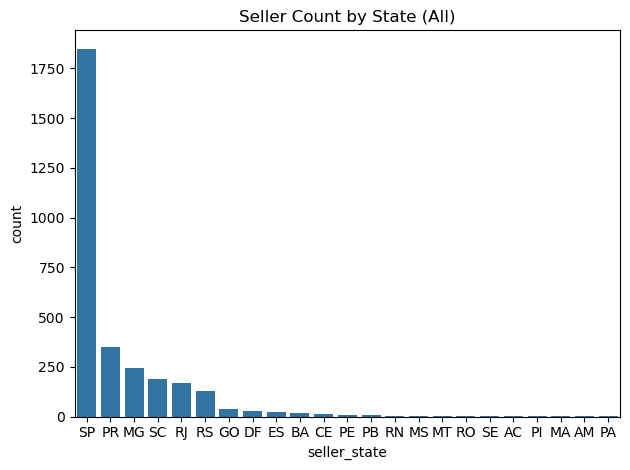

In [99]:
state_counts = df8['seller_state'].value_counts()


sns.barplot(x = state_counts.index, y = state_counts.values, )
plt.title('Seller Count by State (All)')
plt.xlabel('seller_state')
plt.ylabel('count')

plt.tight_layout()
plt.show()

In [100]:
# product_category_name_translation : ['product_category_name', 'product_category_name_english']

**`product_category_name_translation` — key findings**

- 71 rows, 2 columns, no nulls in any column.
- `product_category_name`: str, 71 unique values (fully unique), top = `beleza_saude`, freq 1.
- `product_category_name_english`: str, 71 unique values (fully unique), top = `health_beauty`, freq 1.   
(Note: products table has 73 categories, 2 more than this table's 71 — a cross-table mismatch)

In [101]:
Query = """SELECT * FROM product_category_name_translation"""
df9 = pd.read_sql(Query, engine)
df9

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor
...,...,...
66,flores,flowers
67,artes_e_artesanato,arts_and_craftmanship
68,fraldas_higiene,diapers_and_hygiene
69,fashion_roupa_infanto_juvenil,fashion_childrens_clothes


Product Category Name Translation table has 71 unique category-to-English mappings, while the Products table has 73 unique category names — a mismatch of 2 categories, to be investigated in the relational integrity phase.  
Separately, the Products table has 610 rows where product_category_name (along with name length, description length, and photos qty) is null — meaning those 610 products have no category assigned at all, and therefore can't be matched against this translation table regardless of the 2-category mismatch.

In [102]:
df_customers = df1
df_geolocation = df2
df_orders = df3
df_order_items = df4
df_payments = df5
df_reviews = df6
df_products = df7
df_sellers = df8
df_translation = df9

## Relational Integrity

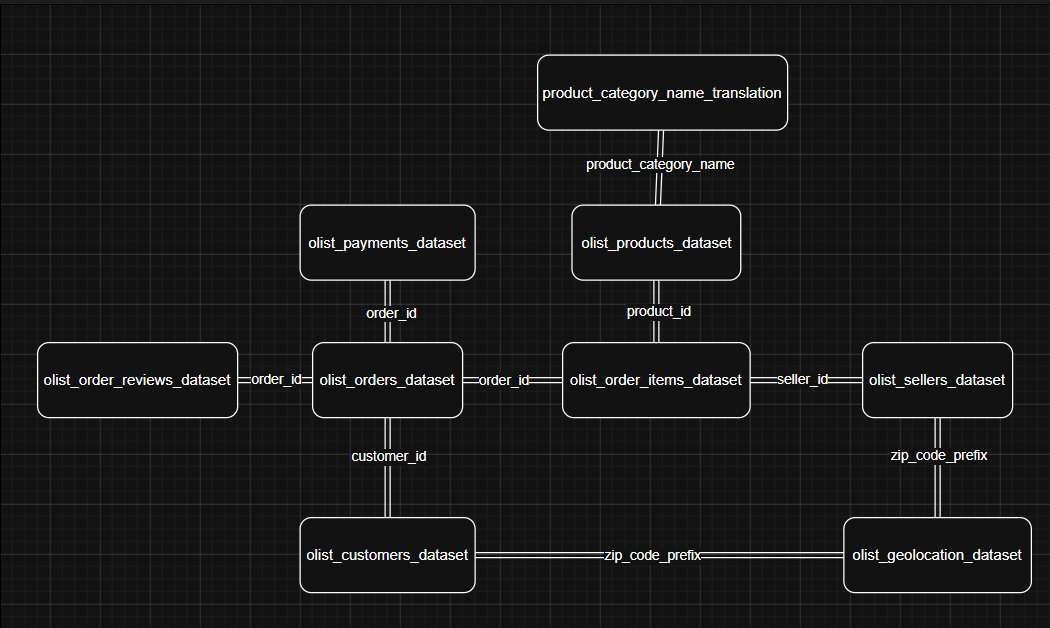

Column names of the tables

olist_customers_dataset : ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

olist_geolocation_dataset : ['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']

olist_orders_dataset : ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

olist_order_items_dataset : ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

olist_order_payments_dataset : ['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

olist_order_reviews_dataset : ['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

olist_products_dataset : ['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

olist_sellers_dataset : ['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state']

product_category_name_translation : ['product_category_name', 'product_category_name_english']

```
olist_customers_dataset / df_customers
    Primary key: customer_id
    Foreign key: none

olist_orders_dataset / df_orders
    Primary key: order_id
    Foreign key: customer_id -> df_customers

olist_order_items_dataset / df_order_items
    Primary key: order_id + order_item_id (composite)
    Foreign key: order_id -> df_orders
    Foreign key: product_id -> df_products
    Foreign key: seller_id -> df_sellers

olist_order_payments_dataset / df_payments
    Primary key: order_id + payment_sequential (composite)
    Foreign key: order_id -> df_orders

olist_order_reviews_dataset / df_reviews
    Primary key: none (review_id is NOT a unique identifier)
    (data quality issue: 789 review_ids mapped to multiple order_ids)
    (547 order_ids affected — same issue, different view)
    Foreign key: order_id -> df_orders

olist_products_dataset / df_products
    Primary key: product_id
    Foreign key: product_category_name -> df_translation

olist_sellers_dataset / df_sellers
    Primary key: seller_id
    Foreign key: none

olist_geolocation_dataset / df_geolocation
    Primary key: none (no column or combination forms a clean unique key)
    Foreign key: none

product_category_name_translation / df_translation
    Primary key: product_category_name
    Foreign key: none
```

#### Orphan Check

In [103]:
# Check for customers and Orders

In [104]:
query = """SELECT COUNT(*) AS orphaned_orders
FROM olist_orders_dataset o 
LEFT JOIN olist_customers_dataset c
ON o.customer_id = c.customer_id
WHERE c.customer_id IS NULL"""
check = pd.read_sql(query,engine)
check

,orphaned_orders
0,0


In [105]:
# Result: 0 orphaned rows
# All customer_ids in the orders exist in the customers table

In [106]:
# Check for Orders and Order_items

In [107]:
query = """SELECT COUNT(*) AS orphaned_order_items
FROM olist_order_items_dataset oi 
LEFT JOIN olist_orders_dataset o 
ON oi.order_id = o.order_id
WHERE o.order_id IS NULL"""
check = pd.read_sql(query,engine)
check

,orphaned_order_items
0,0


In [108]:
# Result: 0 orphaned rows
# All order_ids in the order_items exist in the orders table

In [109]:
# Check for Orders and Payments

In [110]:
query = """SELECT COUNT(*) AS orphaned_payments
FROM olist_order_payments_dataset p
LEFT JOIN olist_orders_dataset o 
ON p.order_id = o.order_id
WHERE o.order_id IS NULL"""
check = pd.read_sql(query,engine)
check

,orphaned_payments
0,0


In [111]:
# Result: 0 orphaned rows
# All order_ids in the order_payments exist in the orders table

In [112]:
# Check for Products and Order_items

In [113]:
query = """SELECT COUNT(*) as orphaned_order_items
FROM olist_order_items_dataset oi
LEFT JOIN olist_products_dataset p 
ON oi.product_id = p.product_id
WHERE p.product_id IS NULL"""
check = pd.read_sql(query,engine)
check

,orphaned_order_items
0,0


In [114]:
# Result: 0 orphaned rows
# All product_ids in the order_items exist in the products table

In [115]:
# Check for sellers and Order_items

In [116]:
query = """SELECT COUNT(*) as orphaned_order_items
FROM olist_order_items_dataset oi
LEFT JOIN olist_sellers_dataset s
ON oi.seller_id = s.seller_id
WHERE s.seller_id IS NULL"""
check = pd.read_sql(query,engine)
check

,orphaned_order_items
0,0


In [117]:
# Result: 0 orphaned rows
# All seller_ids in the order_items exist in the sellers table

In [118]:
# Check between orders and reviews

In [119]:
query = """SELECT COUNT(*) AS orphaned_reviews
FROM olist_order_reviews_dataset r
LEFT JOIN olist_orders_dataset o
ON r.order_id = o.order_id
WHERE o.order_id IS NULL"""
check = pd.read_sql(query,engine)
check

,orphaned_reviews
0,0


In [120]:
# Result: 0 orphaned records — clean
# Note: separate duplicate mapping issue exists (789 review_ids, 547 order_ids)
# That is a different data quality issue, not an orphan issue

In [121]:
# Check between products and translations 
query = """SELECT COUNT(*) as orphaned_products
FROM olist_products_dataset p
LEFT JOIN product_category_name_translation t
ON p.product_category_name = t.product_category_name
WHERE t.product_category_name IS NULL"""
check = pd.read_sql(query,engine)
check

,orphaned_products
0,623


In [122]:
# Result: 623 orphaned products = 623 products have category names with no matching translation
# Breakdown: 610 of these already had NULL product_category_name (found in profiling phase)
# NULL can never match, so this isn't a real mapping mismatch
# Remaining ~13 products have a real category name that's simply missing from the translation table 
# (73 categories in products, 71 in translation table)
# These products will have NULL english category name when joined

In [123]:
query = """SELECT p.product_category_name, COUNT(*) AS orphaned_products_in_this_category
FROM olist_products_dataset p
LEFT JOIN product_category_name_translation t
ON p.product_category_name = t.product_category_name
WHERE t.product_category_name IS NULL
GROUP BY p.product_category_name
ORDER BY orphaned_products_in_this_category DESC;"""
check = pd.read_sql(query,engine)
check

,product_category_name,orphaned_products_in_this_category
0,NaN,610
1,portateis_cozinha_e_preparadores_de_alimentos,10
2,pc_gamer,3


In [124]:
# Result: 623 orphaned products broken down as:
# - 610 products have NULL category name (found in profiling phase)
# - 13 products belong to 2 categories missing from translation table
# these will show NULL for english category name when joined

In [125]:
# Coverage check (not a strict orphan check - geolocation has no primary key on zip/state/city):
# does every customer's zip + state + city combination exist together in the geolocation table?
# No Brazil bounding-box filter applied here - checking raw existence only
query = """SELECT COUNT(*) AS unmatched_customers
FROM olist_customers_dataset c
LEFT JOIN (SELECT DISTINCT geolocation_zip_code_prefix, geolocation_state, geolocation_city FROM olist_geolocation_dataset) g
ON c.customer_zip_code_prefix = g.geolocation_zip_code_prefix
AND c.customer_state = g.geolocation_state
AND c.customer_city = g.geolocation_city
WHERE g.geolocation_zip_code_prefix IS NULL"""
check = pd.read_sql(query, engine)
check

,unmatched_customers
0,318


In [126]:
# 318 customers have no matching zip + state + city combination anywhere in geolocation.
# These customers cannot be reliably geo-located via this join.

In [127]:
# Coverage check (not a strict orphan check - geolocation has no primary key on zip/state/city):
# does every seller's zip + state + city combination exist together in the geolocation table?
# No Brazil bounding-box filter applied here - checking raw existence only
query = """SELECT COUNT(*) AS unmatched_sellers
FROM olist_sellers_dataset s
LEFT JOIN (SELECT DISTINCT geolocation_zip_code_prefix, geolocation_state, geolocation_city FROM olist_geolocation_dataset) g
ON s.seller_zip_code_prefix = g.geolocation_zip_code_prefix
AND s.seller_state = g.geolocation_state
AND s.seller_city = g.geolocation_city
WHERE g.geolocation_zip_code_prefix IS NULL"""
check = pd.read_sql(query, engine)
check

,unmatched_sellers
0,137


In [128]:
# 137 sellers have no matching zip + state + city combination anywhere in geolocation.
# These sellers cannot be reliably geo-located via this join.

No column combination in geolocation forms a clean key (zip alone, zip+state, zip+city+state, even lat+lng and full-row dedup all fall short of the table's 1,000,163 rows) —   
so these coverage checks only confirm existence of a matching zip+state+city combination, not a guaranteed unique or reliable match.  
Any future join for coordinates would still need to handle multiple matching rows per zip+state+city.

In [129]:
query = """SELECT customer_unique_id,
COUNT(DISTINCT customer_id) AS order_count,
COUNT(DISTINCT customer_city) AS distinct_cities,
COUNT(DISTINCT customer_state) AS distinct_states
FROM olist_customers_dataset
GROUP BY customer_unique_id
HAVING COUNT(DISTINCT customer_id) > 1
ORDER BY distinct_cities DESC"""
city_check = pd.read_sql(query, engine)
city_check

,customer_unique_id,order_count,distinct_cities,distinct_states
0,d44ccec15f5f86d14d6a2cfa67da1975,3,3,3
1,8b433c0e7b7d2a1f1148b4277cc673f8,2,2,2
2,2410195f6521688005612363835a2671,2,2,2
3,547d0504ca415eb4864fa3030f73d3f3,2,2,2
4,4cfa5155cf7cff8eb15e0b12041d058e,2,2,1
...,...,...,...,...
2992,0a61b571f594b6919601bcf3380da7f7,3,1,1
2993,0aa1ab39ff2b837c05d7c9ff85b6d983,2,1,1
2994,0aadc1d26d1c8b88a52c39a533ccea93,2,1,1
2995,0abee71cd257861a0944e2a81cea4a50,2,1,1


_____________

In [131]:
# Cardinality Check

In [132]:
# Logical Check:

# Customers -> Orders: one to one (each customer_id appears once in both tables)
    # BUT customer_unique_id → Orders: one to many (same real customer can place many orders)
# Orders -> Order Items: one to many (one order can have multiple products)
# Orders -> Payments: one to many (one order can have multiple payment methods)
# Orders -> Reviews: expected one to one, actual one to many (547 orders have multiple reviews - data quality issue) 
    # (789 reviews are mapped to multiple orders)
# Order Items -> Products: many to one (many order items can reference same product)
# Order Items -> Sellers: many to one (many order items can reference same seller)
# Products -> Translation: many to one (many products belong to one category, one category has one english translation)
    # 610 products have NULL category name - No translation possible
    # 13 products belongs to 2 categories missing from translation table
    # These will show NULL English category translations when joined

# Customers → Geolocation: many to many 
    # (multiple customers can share a zip_code_prefix, and that same zip may have multiple rows in geolocation, as there is no possible primary key  (composite)) - 
    # genuinely different from other relationships here, since neither side has a clean unique key on zip.
# Same applies for Sellers → Geolocation.

In [133]:
# Confirmations

In [134]:
# Customers -> Orders: one to one
# customer_id is unique in both tables and no orphan rows found in orphan check phase
# Customers -> Orders: one to one confirmed

In [135]:
# Orders -> Order Items: one to many
# Checking many side - max items per order
query = """WITH item_counts AS (
SELECT order_id, COUNT(*) AS item_count
FROM olist_order_items_dataset
GROUP BY order_id)
SELECT MAX(item_count) AS max_items
FROM item_counts"""
check = pd.read_sql(query, engine)
check
# Orders side - order_id is unique identifier, already confirmed in data understanding phase
# Orphan check: 0 orphaned order_items found earlier (all order_ids in order_items exist in orders)

,max_items
0,21


In [136]:
# Orders -> Order Items: one to many confirmed

In [137]:
# Orders -> Order Items: one to many 
# Checking many side - max payments per order
query = """WITH payment_counts AS (
    SELECT order_id, COUNT(*) as payment_count
    FROM olist_order_payments_dataset
    GROUP BY order_id
)
SELECT MAX(payment_count) as max_payments
FROM payment_counts;"""
check = pd.read_sql(query, engine)
check
# Orders side - order_id is unique identifier, already confirmed in data understanding phase

,max_payments
0,29


In [138]:
# Orders -> Order Items: one to many confirmed

In [139]:
# Order Items -> Products: many to one
# Checking many side - max order items per product
query = """WITH product_counts AS (
SELECT product_id, COUNT(*) as item_count
FROM olist_order_items_dataset
GROUP BY product_id)
SELECT MAX(item_count) as max_items_per_product
FROM product_counts;"""
check = pd.read_sql(query, engine)
check
# Products side - product_id is unique identifier, already confirmed in data understanding phase
# Orphan check: 0 orphaned order_items found earlier (all product_ids in order_items exist in products)

,max_items_per_product
0,527


In [140]:
# Order Items -> Products: many to one confirmed (Products -> Order Items: one to mony)

In [141]:
# Orders -> Reviews: expected one to one, actual one to many
# Checking many side - max reviews per order
query = """WITH review_counts AS (
    SELECT order_id, COUNT(*) as review_count
    FROM olist_order_reviews_dataset
    GROUP BY order_id
)
SELECT MAX(review_count) as max_reviews
FROM review_counts;"""
check = pd.read_sql(query, engine)
check

# Orders side - order_id is unique identifier, already confirmed in data understanding phase
    # Expected one to one but actual one to many - data quality issue already found in profiling phase
    # 547 orders mapped to multiple reviews, 789 review_ids mapped to multiple orders
# Orphan check: 0 orphaned reviews found earlier (all order_ids in reviews exist in orders)

,max_reviews
0,3


In [142]:
# Orders -> Reviews: expected one to one, actual one to many confirmed

In [143]:
# Order Items -> Sellers: many to one
# Checking many side - max order items per seller
query = """WITH seller_counts AS (
SELECT seller_id, COUNT(*) as item_count
FROM olist_order_items_dataset
GROUP BY seller_id)
SELECT MAX(item_count) as max_items_per_seller
FROM seller_counts;"""
check = pd.read_sql(query, engine)
check
# Sellers side - seller_id is unique identifier, already confirmed in data understanding phase
# Orphan check: 0 orphaned order_items found earlier (all seller_ids in order_items exist in sellers)

,max_items_per_seller
0,2033


In [144]:
# Order Items -> Sellers: many to one confirmed

In [145]:
# Products -> Translation: many to one
# Checking many side - max products per category
query = """WITH category_counts AS (
SELECT product_category_name, COUNT(*) as product_count
FROM olist_products_dataset
WHERE product_category_name IS NOT NULL
GROUP BY product_category_name)
SELECT MAX(product_count) as max_products_per_category
FROM category_counts;"""
check = pd.read_sql(query, engine)
check
# Translation side - product_category_name is unique identifier, already confirmed in data understanding phase
    # 610 products have null category name - no translation possible
    # 13 products belong to 2 categories missing from translation table

,max_products_per_category
0,3029


In [146]:
# Products -> Translation: many to one confirmed

____________________

In [147]:
# Many to Many ones

In [148]:
# Customers: count of zip prefixes with more than 1 distinct city
city_counts = df_customers.groupby('customer_zip_code_prefix')['customer_city'].nunique()
print(len(city_counts[city_counts > 1]))
# Customers: count of zip prefixes with more than 1 distinct state
state_counts = df_customers.groupby('customer_zip_code_prefix')['customer_state'].nunique()
print(len(state_counts[state_counts > 1]))

39
0


In [149]:
# Sellers: count of zip prefixes with more than 1 distinct state
state_counts_s = df_sellers.groupby('seller_zip_code_prefix')['seller_state'].nunique()
print(len(state_counts_s[state_counts_s > 1]))
# Sellers: count of zip prefixes with more than 1 distinct city
city_counts_s = df_sellers.groupby('seller_zip_code_prefix')['seller_city'].nunique()
print(len(city_counts_s[city_counts_s > 1]))

17
34


In [150]:
# Max rows per zip+state+city combination in geolocation (strictest grouping confirmed)
query = """WITH geo_location_counts AS (
    SELECT geolocation_zip_code_prefix, geolocation_state, geolocation_city, COUNT(*) AS geo_row_count
    FROM olist_geolocation_dataset
    GROUP BY geolocation_zip_code_prefix, geolocation_state, geolocation_city
)
SELECT MAX(geo_row_count) AS max_geo_rows_per_location
FROM geo_location_counts"""
check = pd.read_sql(query, engine)
check

,max_geo_rows_per_location
0,997


In [151]:
# Confirming many-to-many: customers side - stricter grouping (zip+state+city) for consistency
# Geolocation side already confirmed as "many" via earlier uniqueness checks (no unique key
# at zip, zip+state, or zip+state+city) - no need to re-verify that side here.
query = """WITH interaction_counts AS (
SELECT customer_zip_code_prefix, customer_state, customer_city, COUNT(*) AS interaction_count
FROM olist_customers_dataset
GROUP BY customer_zip_code_prefix, customer_state, customer_city)
SELECT MAX(interaction_count) AS max_interactions_per_location
FROM interaction_counts"""
check = pd.read_sql(query, engine)
check

,max_interactions_per_location
0,142


In [152]:
# Confirming many-to-many: sellers side - stricter grouping (zip+state+city)
query = """WITH seller_location_counts AS (
SELECT seller_zip_code_prefix, seller_state, seller_city, COUNT(*) AS seller_count
FROM olist_sellers_dataset
GROUP BY seller_zip_code_prefix, seller_state, seller_city)
SELECT MAX(seller_count) AS max_sellers_per_location
FROM seller_location_counts"""
check = pd.read_sql(query, engine)
check

,max_sellers_per_location
0,49


#### Why zip+state+city, not zip alone
Zip alone spans multiple cities in real cases — 39 customer zip prefixes and 34 seller zip prefixes cover more than one distinct city.   
Zip alone can also span multiple states, though far less often — 0 cases for customers, 17 for sellers.  
Zip+city and zip+state can each break independently, so zip alone would lump together rows that don't actually belong to the same place.  
Zip+state+city is the strictest combination with confirmed data behind it, giving a real count of location-level duplication instead of an inflated one from a looser grouping.

#### Data constraint behind this choice
Geolocation has no confirmed unique key at any level tested — not zip, not zip+state, not zip+state+city, not lat/lng.  
Customers and sellers only guarantee uniqueness on their own ID column, never on any location field.

#### Many-to-many, confirmed on both sides
Customers <-> Geolocation: up to 142 customer rows and up to 997 geolocation rows share the same zip+state+city.  
Sellers <-> Geolocation: up to 49 seller rows and up to 997 geolocation rows share the same zip+state+city.  
Both sides show real duplication at the strictest key tested — this is many-to-many by evidence, not by default because a key was missing.

_______________

In [153]:
# Fan-Out and Data Loss Checks

`orders` and `order_items` are both central tables in this data model, at different grains —   
`orders` at order-level (status, timestamps, customer link),   
`order_items` at item-level (one row per product per order).  
For each relationship checked below, the LEFT JOIN's starting table depends on which side is being tested — this isn't a fixed rule, just the convention followed here for consistency:
- Orphan checks start from the "many" side, to check if child rows have a matching parent.
- Fan-out/data-loss checks start from the "one" side, to check if its rows multiply or go missing when joined outward.

  -> Each check only shows what happens to its own starting side's rows, so both directions are run together per relationship to get the full picture.

In [154]:
# Fan out and data loss check: Customers -> Orders
query = """WITH joined AS (
SELECT c.customer_id, o.order_id
FROM olist_customers_dataset c
LEFT JOIN olist_orders_dataset o
ON c.customer_id = o.customer_id)
SELECT (SELECT COUNT(*) FROM olist_customers_dataset) as original_rows,
COUNT(*) as joined_rows,
COUNT(*) FILTER (WHERE joined.order_id IS NULL) as unmatched_rows,
CASE WHEN COUNT(*) > (SELECT COUNT(*) FROM olist_customers_dataset) THEN 'Yes' 
ELSE 'No' 
END AS fan_out_occurred,
CASE WHEN COUNT(*) FILTER (WHERE joined.order_id IS NULL) > 0 THEN 'Yes' 
ELSE 'No' 
END AS data_loss_occurred
FROM joined;"""
check = pd.read_sql(query, engine)
check

,original_rows,joined_rows,unmatched_rows,fan_out_occurred,data_loss_occurred
0,99441,99441,0,No,No


In [155]:
# Customers → Orders: 99,441 original rows, 99,441 joined rows, 0 unmatched. 
# No fan-out, no data loss — join is clean, confirms one-to-one cardinality.

In [156]:
# Fan out and data loss check: Orders -> Order_Items
query = """WITH joined AS (
SELECT o.order_id, oi.order_item_id
FROM olist_orders_dataset o
LEFT JOIN olist_order_items_dataset oi
ON o.order_id = oi.order_id)
SELECT (SELECT COUNT(*) FROM olist_orders_dataset) as original_rows,
COUNT(*) as joined_rows,
COUNT(*) FILTER (WHERE joined.order_item_id IS NULL) as unmatched_rows,
CASE WHEN COUNT(*) > (SELECT COUNT(*) FROM olist_orders_dataset) THEN 'Yes' ELSE 'No' END AS fan_out_occurred,
CASE WHEN COUNT(*) FILTER (WHERE joined.order_item_id IS NULL) > 0 THEN 'Yes' ELSE 'No' END AS data_loss_occurred
FROM joined;"""
check = pd.read_sql(query, engine)
check

,original_rows,joined_rows,unmatched_rows,fan_out_occurred,data_loss_occurred
0,99441,113425,775,Yes,Yes


In [157]:
# Result: Fan-out AND data loss both occurred
# Fan-out reason: One-to-many relationship - one order can have multiple items,
# so one order row multiplies into as many rows as it has items - expected and normal
# Data loss reason: 775 unmatched orders - orders with no items recorded
# Quick status check below to confirm which order_status these unmatched orders belong to

In [158]:
query = """WITH joined AS (
SELECT o.order_id, o.order_status, oi.order_item_id
FROM olist_orders_dataset o
LEFT JOIN olist_order_items_dataset oi
ON o.order_id = oi.order_id)
SELECT joined.order_status, COUNT(*) as unmatched_orders
FROM joined
WHERE joined.order_item_id IS NULL
GROUP BY joined.order_status
ORDER BY unmatched_orders DESC"""
check = pd.read_sql(query, engine)
check

,order_status,unmatched_orders
0,unavailable,603
1,canceled,164
2,created,5
3,invoiced,2
4,shipped,1


In [159]:
# Original orders per status 
df_orders['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [160]:
# DATA QUALITY ISSUE - 775 orders have no items in order_items table/dataset

Comparing unmatched orders against total orders per status:
- unavailable: 603 of 609 missing items
- canceled: 164 of 625 missing items
- created: 5 of 5 missing items
- invoiced: 2 of 314 missing items
- shipped: 1 of 1107  missing items

Since some unavailable orders and a real portion of canceled orders DO have item rows recorded, missing items is not an inherent rule of these statuses — items can and do get attached before an order becomes unavailable or canceled.   
This means the orders missing items within these statuses represent a genuine data quality issue, not expected business behavior.

created orders are a complete gap (100% missing) 

Delivered orders are entirely unaffected (0 missing) — item-level and revenue analysis on delivered orders remains safe.

In [161]:
# Fan-out is expected (1 order → multiple items)
# price and freight_value are item-level; safe for analysis at order-item grain.

In [162]:
# Fan out and data loss check: Orders -> Payments
query = """WITH joined AS (
SELECT o.order_id, p.payment_sequential
FROM olist_orders_dataset o
LEFT JOIN olist_order_payments_dataset p
ON o.order_id = p.order_id)
SELECT (SELECT COUNT(*) FROM olist_orders_dataset) as original_rows,
COUNT(*) as joined_rows,
COUNT(*) FILTER (WHERE joined.payment_sequential IS NULL) as unmatched_rows,
CASE WHEN COUNT(*) > (SELECT COUNT(*) FROM olist_orders_dataset) THEN 'Yes' 
ELSE 'No' 
END AS fan_out_occurred,
CASE WHEN COUNT(*) FILTER (WHERE joined.payment_sequential IS NULL) > 0 THEN 'Yes' 
ELSE 'No' 
END AS data_loss_occurred
FROM joined;"""
check = pd.read_sql(query, engine)
check

,original_rows,joined_rows,unmatched_rows,fan_out_occurred,data_loss_occurred
0,99441,103887,1,Yes,Yes


In [163]:
# Status: Fan-out occurred — expected, one order can have multiple payment methods
# 1 order has no payment recorded — minor data quality issue
# This order will be excluded from payment level analysis

In [164]:
query = """WITH joined AS (
SELECT o.order_id, o.order_status, p.payment_sequential
FROM olist_orders_dataset o
LEFT JOIN olist_order_payments_dataset p
ON o.order_id = p.order_id)
SELECT order_status, COUNT(*) AS unmatched_orders
FROM joined
WHERE payment_sequential IS NULL
GROUP BY order_status"""
check = pd.read_sql(query, engine)
check

,order_status,unmatched_orders
0,delivered,1


Fan-out confirmed (103,887 joined rows vs 99,441 orders) — expected, one order can have multiple payment rows (split payments/installments).   
1 unmatched order (no payment recorded), and its order_status is "delivered" — unusual, since a completed/delivered order would normally have a successful payment on record.  
This single order will be excluded from payment-level analysis; treated as a data quality issue.

In [165]:
query = """SELECT o.order_id
FROM olist_orders_dataset o
LEFT JOIN olist_order_payments_dataset p
ON o.order_id = p.order_id
WHERE p.payment_sequential IS NULL;"""
check = pd.read_sql(query, engine)
check

,order_id
0,bfbd0f9bdef84302105ad712db648a6c


In [166]:
# 1 unmatched delivered order found — order ID: [bfbd0f9bdef84302105ad712db648a6c]
# Delivered order with no payment recorded

In [167]:
# Fan out and data loss check: Orders -> Reviews
query = """WITH joined AS (
SELECT o.order_id, r.review_id
FROM olist_orders_dataset o
LEFT JOIN olist_order_reviews_dataset r
ON o.order_id = r.order_id)
SELECT (SELECT COUNT(*) FROM olist_orders_dataset) as original_rows,
COUNT(*) as joined_rows,
COUNT(*) FILTER (WHERE joined.review_id IS NULL) as unmatched_rows,
CASE WHEN COUNT(*) > (SELECT COUNT(*) FROM olist_orders_dataset) THEN 'Yes' 
ELSE 'No' 
END AS fan_out_occurred,
CASE WHEN COUNT(*) FILTER (WHERE joined.review_id IS NULL) > 0 THEN 'Yes' 
ELSE 'No' 
END AS data_loss_occurred
FROM joined;"""
check = pd.read_sql(query, engine)
check

,original_rows,joined_rows,unmatched_rows,fan_out_occurred,data_loss_occurred
0,99441,99992,768,Yes,Yes


Orders → Reviews: fan-out and data loss both occurred (expected).  
Fan-out: 547 orders have multiple reviews (found in profiling phase).  
Data loss: 768 orders have no review — normal, not every customer leaves one.  
Separately, from the reviews side: 789 review_ids map to multiple order_ids — a distinct anomaly from the 547 orders-with-multiple-reviews finding, not the same issue.   
**Whether these two sets of rows overlap has not been confirmed.**  
Decision: use the latest review per order_id (by review_answer_timestamp) when joining, to resolve the order-side duplication for any order-grain analysis.

In [168]:
query = """WITH dup_review AS (
SELECT review_id 
FROM olist_order_reviews_dataset 
GROUP BY review_id 
HAVING COUNT(DISTINCT order_id) > 1),
dup_order AS (
SELECT order_id 
FROM olist_order_reviews_dataset 
GROUP BY order_id 
HAVING COUNT(DISTINCT review_id) > 1)
SELECT COUNT(*) AS overlapping_rows
FROM olist_order_reviews_dataset
WHERE review_id IN (SELECT review_id FROM dup_review)
AND order_id IN (SELECT order_id FROM dup_order)"""
overlap_check = pd.read_sql(query, engine)
overlap_check

,overlapping_rows
0,649


649 rows are involved in both anomalies simultaneously — these rows have a review_id that maps to multiple orders AND belong to an order_id that maps to multiple reviews.   
Confirms the two anomalies aren't fully separate; they partially share the same rows.

In [169]:
query = """SELECT o.order_status, COUNT(*) AS review_count
FROM olist_orders_dataset o
JOIN olist_order_reviews_dataset r
ON o.order_id = r.order_id
GROUP BY o.order_status
ORDER BY review_count DESC"""
status_check = pd.read_sql(query, engine)
status_check

,order_status,review_count
0,delivered,96361
1,shipped,1043
2,canceled,609
3,unavailable,597
4,invoiced,313
5,processing,296
6,created,3
7,approved,2


Reviews exist on non-delivered orders too — 2,863 reviews (shipped 1,043, canceled 609, unavailable 597, invoiced 313, processing 296, created 3, approved 2), not just delivered.  
Not clear why — could be a platform behavior (review requests not tied strictly to delivery) or a data issue. Not confirmed either way.

Note: Although the dataset contains a small number of reviews linked to non-delivered orders (approximately 2.9% of reviewed orders), review-based analyses in this project were restricted to delivered orders to ensure that review scores reflect completed purchase experiences.

In [170]:
# Fan out and data loss check: Sellers -> Order_Items 
query = """WITH joined AS (
SELECT s.seller_id, oi.order_item_id
FROM olist_sellers_dataset s
LEFT JOIN olist_order_items_dataset oi
ON s.seller_id = oi.seller_id)
SELECT
(SELECT COUNT(*) FROM olist_sellers_dataset) as original_rows,
COUNT(*) as joined_rows,
COUNT(*) FILTER (WHERE order_item_id IS NULL) as unmatched_rows,
CASE WHEN COUNT(*) > (SELECT COUNT(*) FROM olist_sellers_dataset) THEN 'Yes' ELSE 'No' END AS fan_out_occurred,
CASE WHEN COUNT(*) FILTER (WHERE order_item_id IS NULL) > 0 THEN 'Yes' ELSE 'No' END AS data_loss_occurred
FROM joined;"""
check_sellers = pd.read_sql(query, engine)
check_sellers

,original_rows,joined_rows,unmatched_rows,fan_out_occurred,data_loss_occurred
0,3095,112650,0,Yes,No


In [171]:
# Expected result because: no null seller_ids in order_items, no orphaned seller_ids found in the earlier orphan check, 
# seller_id is a unique identifier in sellers, and every seller has at least one recorded sale.  
# Fan-out is normal here — one seller can have many item sales, not a data quality issue.

In [172]:
# Fan out and data loss check: Products -> Order_Items (does every product have at least one sale?)
query = """WITH joined AS (
SELECT p.product_id, oi.order_item_id
FROM olist_products_dataset p
LEFT JOIN olist_order_items_dataset oi
ON p.product_id = oi.product_id)
SELECT (SELECT COUNT(*) FROM olist_products_dataset) as original_rows,
COUNT(*) as joined_rows,
COUNT(*) FILTER (WHERE order_item_id IS NULL) as unmatched_rows,
CASE WHEN COUNT(*) > (SELECT COUNT(*) FROM olist_products_dataset) THEN 'Yes' ELSE 'No' END AS fan_out_occurred,
CASE WHEN COUNT(*) FILTER (WHERE order_item_id IS NULL) > 0 THEN 'Yes' ELSE 'No' END AS data_loss_occurred
FROM joined;"""
check = pd.read_sql(query, engine)
check

,original_rows,joined_rows,unmatched_rows,fan_out_occurred,data_loss_occurred
0,32951,112650,0,Yes,No


In [173]:
# Expected result because: no null product_ids in order_items, no orphaned product_ids found in the earlier orphan check,
# product_id is a unique identifier in products, and every product has at least one recorded sale.
# Fan-out is normal here — one product can appear in multiple order_items rows, not a data quality issue.

In [174]:
# Fan-out and data loss check: translation → products
query = """WITH joined AS (
SELECT c.product_category_name, p.product_id
FROM product_category_name_translation c
LEFT JOIN olist_products_dataset p
ON p.product_category_name = c.product_category_name)
SELECT (SELECT COUNT(*) FROM product_category_name_translation) as original_rows,
COUNT(*) as joined_rows,
COUNT(*) FILTER (WHERE product_id IS NULL) as unmatched_rows,
CASE WHEN COUNT(*) > (SELECT COUNT(*) FROM product_category_name_translation) THEN 'Yes' 
ELSE 'No' 
END AS fan_out_occurred,
CASE WHEN COUNT(*) FILTER (WHERE product_id IS NULL) > 0 THEN 'Yes' 
ELSE 'No' 
END AS data_loss_occurred
FROM joined;"""
check = pd.read_sql(query, engine)
check

,original_rows,joined_rows,unmatched_rows,fan_out_occurred,data_loss_occurred
0,71,32328,0,Yes,No


In [175]:
# Status: Fan-out occurred (expected), no data loss
# All 71 translation categories are used by at least one product — no unused categories
# One category maps to many products — normal one-to-many relationship
# Separately (from earlier orphan check, products → translation direction): 623 products have no matching translation
#   - 610 of these have NULL category_name (can't match anything, not a real mapping gap)
#   - ~13 have a real category name that's simply missing from the translation table (73 categories in products vs 71 in translation)

Customers/Sellers ↔ Geolocation excluded from the completeness table above — geolocation has no primary key, so this isn't a strict parent-child relationship, just a coverage check (already done earlier: 318 customers, 137 sellers unmatched).

### Completeness Summary 
(excludes Customers/Sellers <-> Geolocation -- many-to-many, no parent side)

Completeness = orphaned rows (child row with no matching parent) + data loss (parent row with no matching child).   
Different from cardinality, which describes relationship shape (one-to-one, one-to-many, many-to-one), not whether rows are missing.

| Relationship | Orphaned rows (no parent) | Data loss (parent with no child) |
|---|---|---|
| Customers -> Orders | 0 | 0 |
| Orders -> Order Items | 0 | 775 orders (see status breakdown — mostly unavailable/canceled) |
| Orders -> Payments | 0 | 1 order |
| Orders -> Reviews | 0 | 768 orders |
| Sellers -> Order Items | 0 | 0 sellers unmatched |
| Products -> Order Items | 0 | 0 products unmatched |
| Translation -> Products | 623 products | 0 categories unmatched |

___________

Column names of the tables

olist_customers_dataset : ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

olist_geolocation_dataset : ['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']

olist_orders_dataset : ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

olist_order_items_dataset : ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

olist_order_payments_dataset : ['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

olist_order_reviews_dataset : ['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

olist_products_dataset : ['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

olist_sellers_dataset : ['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state']

product_category_name_translation : ['product_category_name', 'product_category_name_english']

## Phase: Cross-Table Business Analysis

Structured into 10 working sections for the notebook (Revenue & Order Volume, Order Outcomes, Regional Patterns, Temporal Patterns, Payments, Delivery & Fulfillment, Seller Performance, Category Analysis, Reviews & Satisfaction, Customer Behavior & Retention). 

Base filters: "gross" = all orders, no exclusions. "clean" = excludes canceled + unavailable orders.  
Additional filters (date logic violations, geolocation exclusions, known missing-payment/sequential rows) applied per-analysis as needed.

Denominators are decided per metric, stated explicitly at the point of each rate calculation — not fixed globally.

`geolocation` table excluded from all analysis here — no clean key, already documented as unreliable.

### Section 1: Revenue & Order Volume

In [176]:
# Gross Revenue, Clean Revenue, and Revenue Gap in one query
query = """SELECT SUM(p.payment_value) AS gross_revenue,
SUM(p.payment_value) FILTER (WHERE o.order_status NOT IN ('unavailable', 'canceled')) AS clean_revenue,
SUM(p.payment_value) FILTER (WHERE o.order_status IN ('unavailable', 'canceled')) AS revenue_gap
FROM olist_orders_dataset o
JOIN olist_order_payments_dataset p
ON o.order_id = p.order_id"""
revenue_summary = pd.read_sql(query, engine)
revenue_summary

,gross_revenue,clean_revenue,revenue_gap
0,16008872.12,15739137.01,269735.11


### Known issues affecting revenue
- 9 rows have payment_value = 0 (3 explained as 'not_defined' type, 6 unexplained)
- 1 delivered order has no payment row at all
- 82 rows / 80 orders have payment_sequential inconsistencies

In [177]:
# Zero-value rows: no impact either way (adding/removing 0 doesn't change the sum)
# 1 missing-payment order: automatically excluded by the INNER JOIN, already handled
# Only the 82-row/80-order sequential inconsistency needs checking - now against both clean and gross revenue

In [178]:
query = """WITH sequential_issues AS (
SELECT order_id, payment_sequential,
ROW_NUMBER() OVER (PARTITION BY order_id ORDER BY payment_sequential) AS expected_seq
FROM olist_order_payments_dataset),
bad_orders AS (
SELECT DISTINCT order_id FROM sequential_issues WHERE payment_sequential != expected_seq)
SELECT SUM(p.payment_value) AS gross_revenue_excl_bad_orders,
SUM(p.payment_value) FILTER (WHERE o.order_status NOT IN ('unavailable', 'canceled')) AS clean_revenue_excl_bad_orders,
SUM(p.payment_value) FILTER (WHERE o.order_status IN ('unavailable', 'canceled')) AS revenue_gap_excl_bad_orders
FROM olist_orders_dataset o
JOIN olist_order_payments_dataset p ON o.order_id = p.order_id
WHERE o.order_id NOT IN (SELECT order_id FROM bad_orders)"""
revenue_check = pd.read_sql(query, engine)
revenue_check

,gross_revenue_excl_bad_orders,clean_revenue_excl_bad_orders,revenue_gap_excl_bad_orders
0,1.599543e+07,1.572584e+07,269586.16


In [179]:
metrics = {
    'Gross': ('gross_revenue', 'gross_revenue_excl_bad_orders'),
    'Clean': ('clean_revenue', 'clean_revenue_excl_bad_orders'),
    'Gap': ('revenue_gap', 'revenue_gap_excl_bad_orders')
}

for label, (original_col, excl_col) in metrics.items():
    original_val = revenue_summary[original_col].iloc[0]
    excl_val = revenue_check[excl_col].iloc[0]
    diff = original_val - excl_val
    pct_diff = (diff / original_val) * 100
    print(f"{label} — Absolute Difference: {diff:.2f}, Percentage Impact: {pct_diff:.2f}%")

Gross — Absolute Difference: 13443.89, Percentage Impact: 0.08%
Clean — Absolute Difference: 13294.94, Percentage Impact: 0.08%
Gap — Absolute Difference: 148.95, Percentage Impact: 0.06%


Checked whether the 82-row payment_sequential inconsistency (80 distinct orders) affects revenue: excluding those orders changes Gross by 13,443.89 (0.08%), Clean by 13,294.94 (0.08%), and Gap by 148.95 (0.06%) — all negligible.  
Confirms the sequential numbering issue doesn't reflect corrupted payment_value data — those orders' revenue is legitimate, only the sequence labeling is inconsistent.  
Revenue figures (gross, clean, gap) are kept as originally calculated, including these orders.

In [180]:
# Total clean orders
# All statuses except unavailable and canceled - includes the delivered order with no payment row,
# since this is order grain, not payment grain
query = """SELECT COUNT(*) AS clean_orders
FROM olist_orders_dataset
WHERE order_status NOT IN ('unavailable', 'canceled')"""
clean_orders = pd.read_sql(query, engine)
clean_orders

,clean_orders
0,98207


In [181]:
# Monthly Clean Revenue + Revenue Gap Trend
# INNER JOIN excludes the 1 delivered order with no payment row (consistent with earlier revenue queries)
# Sequential-numbering issue already confirmed negligible impact (0.06-0.08%), not excluded here
# Grouped by purchase month
query = """SELECT DATE_TRUNC('month', o.order_purchase_timestamp::TIMESTAMP) AS month_sort,
TO_CHAR(o.order_purchase_timestamp::TIMESTAMP, 'fmMon-YYYY') AS month_year,
COALESCE(SUM(p.payment_value) FILTER (WHERE o.order_status NOT IN ('canceled', 'unavailable')), 0) AS clean_revenue,
COALESCE(SUM(p.payment_value) FILTER (WHERE o.order_status IN ('canceled', 'unavailable')), 0) AS revenue_gap
FROM olist_orders_dataset o
JOIN olist_order_payments_dataset p
ON o.order_id = p.order_id
GROUP BY month_sort, month_year
ORDER BY month_sort"""
monthly_revenue = pd.read_sql(query, engine)
monthly_revenue

# Dataset spans 2016-09-04 to 2018-10-17 - first (Sep 2016) and last (Oct 2018) months may be partial, may show artificially low values, not a real trend dip

,month_sort,month_year,clean_revenue,revenue_gap
0,2016-09-01,Sep-2016,136.23,116.01
1,2016-10-01,Oct-2016,51657.53,7432.95
2,2016-12-01,Dec-2016,19.62,0.00
3,2017-01-01,Jan-2017,137006.76,1481.28
4,2017-02-01,Feb-2017,283621.94,8286.07
5,2017-03-01,Mar-2017,425656.40,24207.20
6,2017-04-01,Apr-2017,405988.38,11799.65
7,2017-05-01,May-2017,582926.16,9992.66
8,2017-06-01,Jun-2017,499827.47,11448.91
9,2017-07-01,Jul-2017,578858.58,13524.34


In [354]:
# Monthly Order Volume Trend - Clean Orders + Failed Orders
# Failed = unavailable + canceled (consistent with clean/gap revenue split)
# First (Sep 2016) and last (Oct 2018) calendar months may be partial 
query = """SELECT DATE_TRUNC('month', order_purchase_timestamp::TIMESTAMP) AS month_sort,
TO_CHAR(order_purchase_timestamp::TIMESTAMP, 'fmMon-YYYY') AS month_year,
COUNT(*) FILTER (WHERE order_status NOT IN ('unavailable', 'canceled')) AS clean_orders,
COUNT(*) FILTER (WHERE order_status IN ('unavailable', 'canceled')) AS failed_orders
FROM olist_orders_dataset
GROUP BY month_sort, month_year
ORDER BY month_sort"""
monthly_orders = pd.read_sql(query, engine)
monthly_orders

,month_sort,month_year,clean_orders,failed_orders
0,2016-09-01,Sep-2016,2,2
1,2016-10-01,Oct-2016,293,31
2,2016-12-01,Dec-2016,1,0
3,2017-01-01,Jan-2017,787,13
4,2017-02-01,Feb-2017,1718,62
5,2017-03-01,Mar-2017,2617,65
6,2017-04-01,Apr-2017,2377,27
7,2017-05-01,May-2017,3640,60
8,2017-06-01,Jun-2017,3205,40
9,2017-07-01,Jul-2017,3946,80


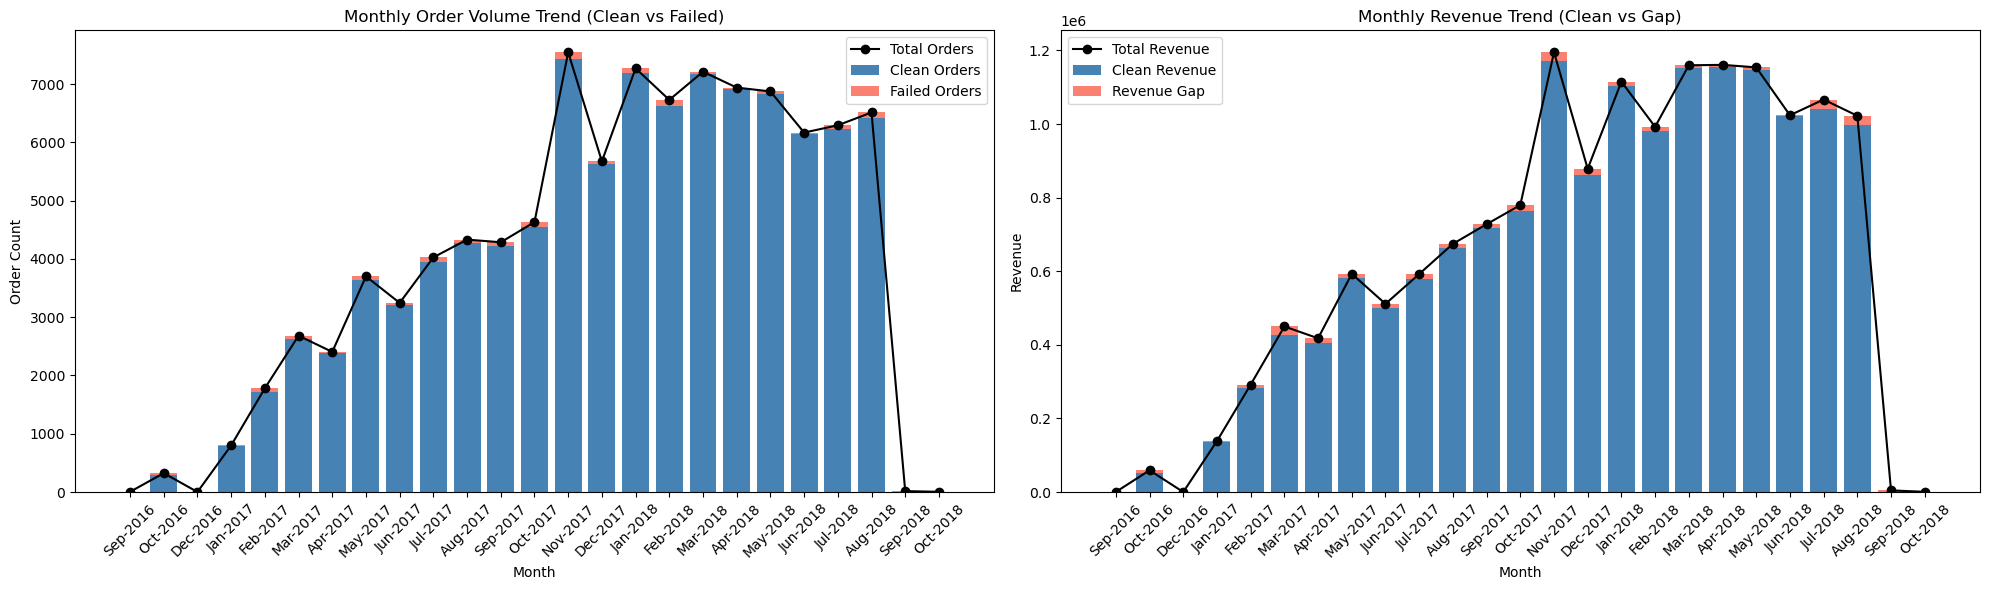

In [183]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

axes[0].bar(monthly_orders['month_year'], monthly_orders['clean_orders'], label='Clean Orders', color='steelblue')
axes[0].bar(monthly_orders['month_year'], monthly_orders['failed_orders'], bottom=monthly_orders['clean_orders'], label='Failed Orders', color='salmon')
axes[0].plot(monthly_orders['month_year'], monthly_orders['clean_orders'] + monthly_orders['failed_orders'], color='black', marker='o', label='Total Orders')
axes[0].set_title('Monthly Order Volume Trend (Clean vs Failed)')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Order Count')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

axes[1].bar(monthly_revenue['month_year'], monthly_revenue['clean_revenue'], label='Clean Revenue', color='steelblue')
axes[1].bar(monthly_revenue['month_year'], monthly_revenue['revenue_gap'], bottom=monthly_revenue['clean_revenue'], label='Revenue Gap', color='salmon')
axes[1].plot(monthly_revenue['month_year'], monthly_revenue['clean_revenue'] + monthly_revenue['revenue_gap'], color='black', marker='o', label='Total Revenue')
axes[1].set_title('Monthly Revenue Trend (Clean vs Gap)')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Revenue')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()

#### Data quality issue: Nov 2016 has essentially zero orders

Monthly order volume trend shows a complete gap for Nov 2016 — no meaningful order count that month, unlike the genuine partial-month edge effect seen at the very start (Sep 2016) and end (Oct 2018) of the dataset. This is a real data gap, not explainable by dataset boundary timing.

#### Order volume and revenue trends diverge in specific months

Jul 2018 vs Aug 2018: order volume was lower in Jul 2018 than Aug 2018, but revenue (both total and clean) was higher in Jul 2018 than Aug 2018 — opposite direction.  
Aug 2017 vs Sep 2017: order volume was slightly lower in Sep 2017 than Aug 2017, but revenue (both total and clean) was higher in Sep 2017 than Aug 2017 — also opposite direction.  
Both suggest average order value shifted between these month pairs — to be confirmed with an AOV check.

In [260]:
# 9 payment_value=0 rows - which months they fall in
query = """SELECT p.order_id, order_status, payment_type, 
TO_CHAR(o.order_purchase_timestamp::TIMESTAMP, 'fmMon-YYYY') AS month_year
FROM olist_order_payments_dataset p
JOIN olist_orders_dataset o ON p.order_id = o.order_id
WHERE p.payment_value = 0
ORDER BY month_year"""
zero_payment_check = pd.read_sql(query, engine)
zero_payment_check

,order_id,order_status,payment_type,month_year
0,fa65dad1b0e818e3ccc5cb0e39231352,shipped,voucher,Apr-2017
1,fa65dad1b0e818e3ccc5cb0e39231352,shipped,voucher,Apr-2017
2,c8c528189310eaa44a745b8d9d26908b,canceled,not_defined,Aug-2018
3,00b1cb0320190ca0daa2c88b35206009,canceled,not_defined,Aug-2018
4,8bcbe01d44d147f901cd3192671144db,delivered,voucher,Jan-2018
5,45ed6e85398a87c253db47c2d9f48216,delivered,voucher,Jun-2017
6,b23878b3e8eb4d25a158f57d96331b18,delivered,voucher,May-2017
7,6ccb433e00daae1283ccc956189c82ae,delivered,voucher,Oct-2017
8,4637ca194b6387e2d538dc89b124b0ee,canceled,not_defined,Sep-2018


The order with 29 payment rows (flagged earlier in profiling as the highest-frequency order_id) includes 2 of the 9 zero-value rows — its heavy split-payment structure is what surfaces both anomalies together,

In [185]:
query = """SELECT p.order_id, o.order_status, COUNT(*) AS total_payment_rows,
COUNT(*) FILTER (WHERE p.payment_value = 0) AS zero_value_rows,
COUNT(*) FILTER (WHERE p.payment_value > 0) AS nonzero_value_rows
FROM olist_order_payments_dataset p
JOIN olist_orders_dataset o ON p.order_id = o.order_id
WHERE p.order_id IN (SELECT DISTINCT order_id FROM olist_order_payments_dataset WHERE payment_value = 0)
GROUP BY p.order_id, o.order_status
ORDER BY p.order_id"""
zero_payment_full_context = pd.read_sql(query, engine)
zero_payment_full_context

,order_id,order_status,total_payment_rows,zero_value_rows,nonzero_value_rows
0,00b1cb0320190ca0daa2c88b35206009,canceled,1,1,0
1,45ed6e85398a87c253db47c2d9f48216,delivered,3,1,2
2,4637ca194b6387e2d538dc89b124b0ee,canceled,1,1,0
3,6ccb433e00daae1283ccc956189c82ae,delivered,4,1,3
4,8bcbe01d44d147f901cd3192671144db,delivered,4,1,3
5,b23878b3e8eb4d25a158f57d96331b18,delivered,4,1,3
6,c8c528189310eaa44a745b8d9d26908b,canceled,1,1,0
7,fa65dad1b0e818e3ccc5cb0e39231352,shipped,29,2,27


In [186]:
query = """WITH sequential_issues AS (
SELECT order_id, payment_sequential,
ROW_NUMBER() OVER (PARTITION BY order_id ORDER BY payment_sequential) AS expected_seq
FROM olist_order_payments_dataset),
bad_orders AS (
SELECT DISTINCT order_id FROM sequential_issues WHERE payment_sequential != expected_seq)
SELECT TO_CHAR(o.order_purchase_timestamp::TIMESTAMP, 'fmMon-YYYY') AS month_year,
o.order_status, COUNT(DISTINCT o.order_id) AS affected_orders,
SUM(p.payment_value) AS affected_value
FROM bad_orders b
JOIN olist_orders_dataset o ON b.order_id = o.order_id
JOIN olist_order_payments_dataset p ON o.order_id = p.order_id
GROUP BY month_year, o.order_status
ORDER BY month_year"""
sequential_issue_summary = pd.read_sql(query, engine)
sequential_issue_summary

,month_year,order_status,affected_orders,affected_value
0,Apr-2017,delivered,1,84.59
1,Apr-2018,delivered,18,2891.67
2,Apr-2018,processing,1,261.97
3,Dec-2017,delivered,1,94.40
4,Feb-2018,delivered,10,1499.97
5,Jan-2018,delivered,10,1433.70
6,Jul-2018,delivered,11,2974.56
7,Jun-2018,delivered,10,1885.92
8,Mar-2018,delivered,5,656.53
9,May-2018,delivered,8,859.22


In [187]:
query = """WITH sequential_issues AS (
SELECT order_id, payment_sequential,
ROW_NUMBER() OVER (PARTITION BY order_id ORDER BY payment_sequential) AS expected_seq
FROM olist_order_payments_dataset),
bad_orders AS (
SELECT DISTINCT order_id FROM sequential_issues WHERE payment_sequential != expected_seq),
affected_by_month AS (
SELECT TO_CHAR(o.order_purchase_timestamp::TIMESTAMP, 'fmMon-YYYY') AS month_year,
COUNT(DISTINCT o.order_id) AS affected_orders,
COALESCE(SUM(p.payment_value), 0) AS affected_value_gross,
COALESCE(SUM(p.payment_value) FILTER (WHERE o.order_status NOT IN ('unavailable', 'canceled')), 0) AS affected_value_clean,
COALESCE(SUM(p.payment_value) FILTER (WHERE o.order_status IN ('unavailable', 'canceled')), 0) AS affected_value_failed
FROM bad_orders b
JOIN olist_orders_dataset o ON b.order_id = o.order_id
JOIN olist_order_payments_dataset p ON o.order_id = p.order_id
GROUP BY month_year),
month_totals AS (
SELECT TO_CHAR(o.order_purchase_timestamp::TIMESTAMP, 'fmMon-YYYY') AS month_year,
COALESCE(SUM(p.payment_value), 0) AS gross_revenue,
COALESCE(SUM(p.payment_value) FILTER (WHERE o.order_status NOT IN ('unavailable', 'canceled')), 0) AS clean_revenue,
COALESCE(SUM(p.payment_value) FILTER (WHERE o.order_status IN ('unavailable', 'canceled')), 0) AS failed_revenue
FROM olist_orders_dataset o
JOIN olist_order_payments_dataset p ON o.order_id = p.order_id
GROUP BY month_year)
SELECT a.month_year, a.affected_orders,
a.affected_value_gross, m.gross_revenue, ROUND(CAST((100.0 * a.affected_value_gross / NULLIF(m.gross_revenue, 0)) AS NUMERIC), 3) AS gross_impact_pct,
a.affected_value_clean, m.clean_revenue, ROUND(CAST((100.0 * a.affected_value_clean / NULLIF(m.clean_revenue, 0)) AS NUMERIC), 3) AS clean_impact_pct,
a.affected_value_failed, m.failed_revenue, ROUND(CAST((100.0 * a.affected_value_failed / NULLIF(m.failed_revenue, 0)) AS NUMERIC), 3) AS failed_impact_pct
FROM affected_by_month a
JOIN month_totals m ON a.month_year = m.month_year
ORDER BY gross_impact_pct DESC"""
check = pd.read_sql(query, engine)
check

,month_year,affected_orders,affected_value_gross,gross_revenue,gross_impact_pct,affected_value_clean,clean_revenue,clean_impact_pct,affected_value_failed,failed_revenue,failed_impact_pct
0,Jul-2018,11,2974.56,1066540.75,0.279,2974.56,1039880.16,0.286,0.00,26660.59,0.000
1,Apr-2018,19,3153.64,1160785.48,0.272,3153.64,1156303.91,0.273,0.00,4481.57,0.000
2,Jun-2018,10,1885.92,1023880.50,0.184,1885.92,1020494.29,0.185,0.00,3386.21,0.000
3,Feb-2018,10,1499.97,992463.34,0.151,1499.97,979966.23,0.153,0.00,12497.11,0.000
4,Jan-2018,10,1433.70,1115004.18,0.129,1433.70,1102639.41,0.130,0.00,12364.77,0.000
5,May-2018,9,1008.17,1153982.15,0.087,859.22,1145748.63,0.075,148.95,8233.52,1.809
6,Oct-2017,3,525.32,779677.88,0.067,525.32,764785.28,0.069,0.00,14892.60,0.000
7,Mar-2018,5,656.53,1159652.12,0.057,656.53,1152736.74,0.057,0.00,6915.38,0.000
8,Apr-2017,1,84.59,417788.03,0.020,84.59,405988.38,0.021,0.00,11799.65,0.000
9,Sep-2017,1,127.09,727762.45,0.017,127.09,717195.22,0.018,0.00,10567.23,0.000


Sequential-numbering issues concentrate in 2018 orders, peaking at 0.28% of gross revenue in Jul-2018 — still negligible in absolute terms, consistent with the overall 0.06–0.08% impact confirmed earlier, but worth noting the issue isn't evenly spread across the dataset's timeline.

Excludes the 9 payment_value = 0 rows:
3 belong to canceled orders with payment_type = 'not_defined' and only zero-value payment records.
5 delivered/shipped orders have additional positive payment rows, so excluding the zero rows
does not change their order value.
This avoids treating zero-value payment records as valid monetary transactions in AOV.

80 orders with payment sequence integrity issues were assessed separately.
Their contribution to monthly gross and clean revenue remained below 1% in every month
(maximum gross impact ≈ 0.28%), so they are retained in the analysis.


In [261]:
# Monthly AOV (Gross, Clean, Failed) - order grain, sum valid payment_value by order_id first

# Orders with no payment records (1 delivered order) are naturally excluded by the INNER JOIN.

query = """WITH order_totals AS (
SELECT o.order_id, o.order_status,
SUM(p.payment_value) AS order_value,
DATE_TRUNC('month', o.order_purchase_timestamp::TIMESTAMP) AS month_sort,
TO_CHAR(o.order_purchase_timestamp::TIMESTAMP, 'fmMon-YYYY') AS month_year
FROM olist_orders_dataset o
JOIN olist_order_payments_dataset p
ON o.order_id = p.order_id
WHERE p.payment_value > 0
GROUP BY o.order_id, o.order_status, month_sort, month_year)
SELECT month_sort, month_year,
COALESCE(SUM(order_value) / NULLIF(COUNT(*),0),0) AS gross_aov,
COALESCE(SUM(order_value) FILTER (WHERE order_status NOT IN ('unavailable','canceled')) 
/ NULLIF(COUNT(*) FILTER (WHERE order_status NOT IN ('unavailable','canceled')),0),0) AS clean_aov,
COALESCE(SUM(order_value) FILTER (WHERE order_status IN ('unavailable','canceled')) 
/ NULLIF(COUNT(*) FILTER (WHERE order_status IN ('unavailable','canceled')),0),0) AS failed_aov
FROM order_totals
GROUP BY month_sort, month_year
ORDER BY month_sort"""
monthly_aov = pd.read_sql(query, engine)
monthly_aov

,month_sort,month_year,gross_aov,clean_aov,failed_aov
0,2016-09-01,Sep-2016,84.080000,136.230000,58.005000
1,2016-10-01,Oct-2016,182.378025,176.305563,239.772581
2,2016-12-01,Dec-2016,19.620000,19.620000,0.000000
3,2017-01-01,Jan-2017,173.110050,174.087370,113.944615
4,2017-02-01,Feb-2017,163.993264,165.088440,133.646290
5,2017-03-01,Mar-2017,167.734377,162.650516,372.418462
6,2017-04-01,Apr-2017,173.788698,170.798645,437.024074
7,2017-05-01,May-2017,160.248330,160.144549,166.544333
8,2017-06-01,Jun-2017,157.558206,155.952409,286.222750
9,2017-07-01,Jul-2017,147.139324,146.695028,169.054250


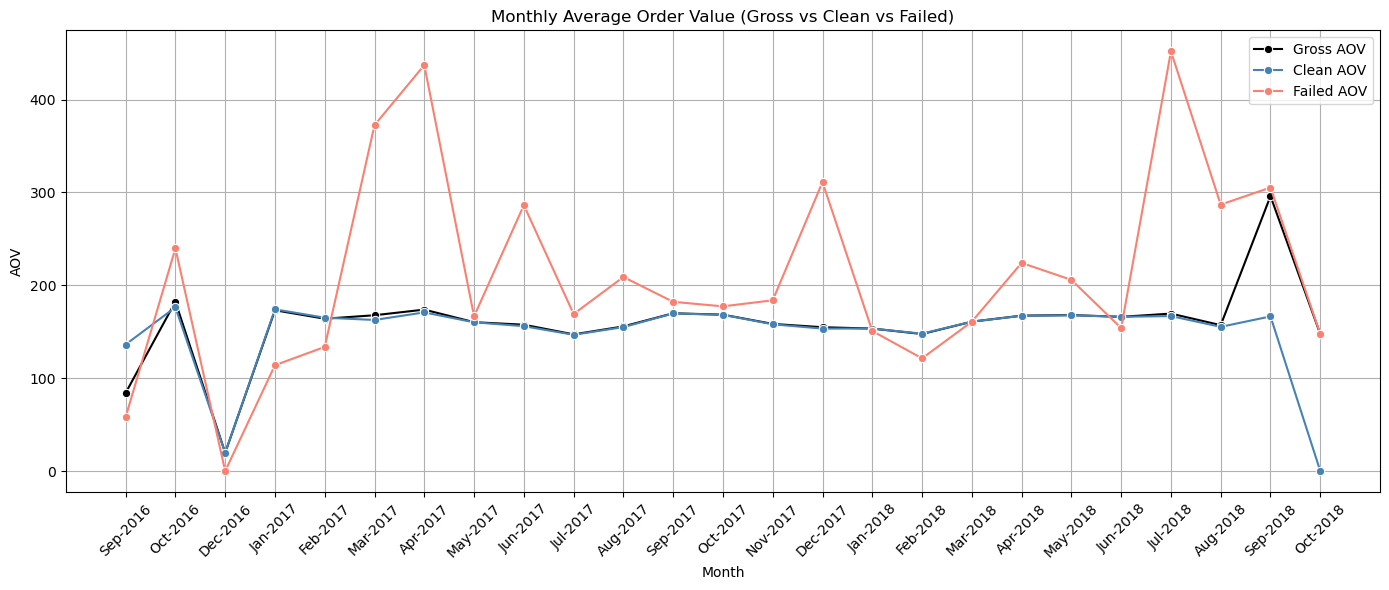

In [262]:
plt.figure(figsize=(14, 6))
sns.lineplot(x='month_year', y='gross_aov', data=monthly_aov, marker='o', label='Gross AOV', color='black')
sns.lineplot(x='month_year', y='clean_aov', data=monthly_aov, marker='o', label='Clean AOV', color='steelblue')
sns.lineplot(x='month_year', y='failed_aov', data=monthly_aov, marker='o', label='Failed AOV', color='salmon')
plt.title('Monthly Average Order Value (Gross vs Clean vs Failed)')
plt.xlabel('Month')
plt.ylabel('AOV')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### AOV vs earlier suspected divergence

Jul 2018 vs Aug 2018: clean_aov fell from 166.83 to 155.26 — consistent with revenue being higher in Jul despite similar/lower order volume.  
Aug 2017 vs Sep 2017: clean_aov rose from 154.98 to 169.67 — consistent with Sep revenue beating Aug despite slightly fewer orders.

Failed AOV appears higher than Clean AOV in most months on the chart — an observed pattern, not statistically verified (exact month count not checked, no significance test run).

The 80 sequential-issue orders have a high % impact on failed revenue in some months (up to 70%), but were not excluded — same as they weren't excluded from clean revenue, where their impact is much smaller (under 1% every month).   
This gap exists because failed revenue is a much smaller base each month, not because the data is worse.

### Section 2: Order Outcomes

In [263]:
# Total Failed Orders (unavailable + canceled)
# Canceled -> often customer-initiated cancellation (unconfirmed — no reason field in dataset)
# Unavailable -> often seller-side issue (unconfirmed — no reason field in dataset)
# Consistent with the clean/failed split already used for revenue_gap
query = """SELECT COUNT(*) AS failed_orders
FROM olist_orders_dataset
WHERE order_status IN ('unavailable', 'canceled')"""
failed_orders = pd.read_sql(query, engine)
failed_orders

,failed_orders
0,1234


In [193]:
# Order status breakdown
query = """SELECT order_status, COUNT(order_id) AS order_count,
100.0 * COUNT(order_id) / SUM(COUNT(order_id)) OVER () AS status_share
FROM olist_orders_dataset
GROUP BY order_status
ORDER BY order_count DESC;"""
check = pd.read_sql(query, engine)
check

,order_status,order_count,status_share
0,delivered,96478,97.020344
1,shipped,1107,1.113223
2,canceled,625,0.628513
3,unavailable,609,0.612423
4,invoiced,314,0.315765
5,processing,301,0.302692
6,created,5,0.005028
7,approved,2,0.002011


In [191]:
# Cancellation Rate - canceled orders as % of all orders
query = """SELECT 100.0 * COUNT(*) FILTER(WHERE order_status = 'canceled')/ COUNT(*) AS cancellation_rate 
FROM olist_orders_dataset"""
Customer_cancellation_rate = pd.read_sql(query, engine)
Customer_cancellation_rate

,cancellation_rate
0,0.628513


In [192]:
# Unavailability Rate - unavailable orders as % of all orders
query = """SELECT 100.0 * COUNT(*) FILTER (WHERE order_status = 'unavailable') / COUNT(*) AS unavailability_rate
FROM olist_orders_dataset"""
unavailability_rate = pd.read_sql(query, engine)
unavailability_rate

,unavailability_rate
0,0.612423


### Section 3: Regional Patterns

In [264]:
# Revenue by State (Clean + Gap) and Order Count by State (Clean + Failed)
# Clean + Gap = total revenue, Clean + Failed = total orders, per state
# Cumulative distribution added on clean orders/revenue - shows how many states together cross a given % of the total.
query = """WITH optimized_payments AS (
SELECT order_id, SUM(payment_value) AS total_payment_value
FROM olist_order_payments_dataset
GROUP BY order_id),
state_totals AS (
SELECT c.customer_state,
COUNT(o.order_id) FILTER (WHERE o.order_status NOT IN ('unavailable', 'canceled')) AS clean_orders,
COUNT(o.order_id) FILTER (WHERE o.order_status IN ('unavailable', 'canceled')) AS failed_orders,
COALESCE(SUM(p.total_payment_value) FILTER (WHERE o.order_status NOT IN ('unavailable', 'canceled')), 0) AS clean_revenue,
COALESCE(SUM(p.total_payment_value) FILTER (WHERE o.order_status IN ('unavailable', 'canceled')), 0) AS revenue_gap
FROM olist_orders_dataset o
JOIN olist_customers_dataset c ON o.customer_id = c.customer_id
JOIN optimized_payments p ON o.order_id = p.order_id
GROUP BY c.customer_state)
SELECT customer_state, clean_orders, failed_orders, clean_revenue, revenue_gap,
ROUND((100.0 * SUM(clean_orders) OVER (ORDER BY clean_orders DESC, customer_state ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW)
/ SUM(clean_orders) OVER ())::numeric, 4) AS cumulative_order_pct,
ROUND((100.0 * SUM(clean_revenue) OVER (ORDER BY clean_revenue DESC, customer_state ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW)
/ SUM(clean_revenue) OVER ())::numeric, 4) AS cumulative_clean_revenue_pct
FROM state_totals
ORDER BY clean_orders DESC"""
state_summary = pd.read_sql(query, engine)
state_summary

,customer_state,clean_orders,failed_orders,clean_revenue,revenue_gap,cumulative_order_pct,cumulative_clean_revenue_pct
0,SP,41126,619,5878935.99,119290.97,41.8773,37.3523
1,RJ,12698,154,2115994.28,28385.41,54.8072,50.7965
2,MG,11496,139,1843460.37,28796.89,66.5132,62.5091
3,RS,5417,49,877803.80,13094.74,72.0292,68.0863
4,PR,4983,62,794653.20,16503.18,77.1032,73.1352
5,SC,3600,37,608180.51,14905.92,80.7690,76.9993
6,BA,3344,36,607041.45,9604.37,84.1741,80.8562
7,DF,2121,19,351487.63,3653.45,86.3338,83.0894
8,ES,2018,15,323105.75,2861.80,88.3887,87.3065
9,GO,1998,22,340626.24,9466.07,90.4232,85.2536


In [195]:
# NOTE: results here are sorted by clean_orders DESC (order-based cumulative is correctly ordered)
# cumulative_revenue_pct is correct in value, but table row order still follows clean_orders rank -
# for viewing/plotting cumulative_revenue_pct specifically, re-sort by clean_revenue DESC first (e.g. df.sort_values())

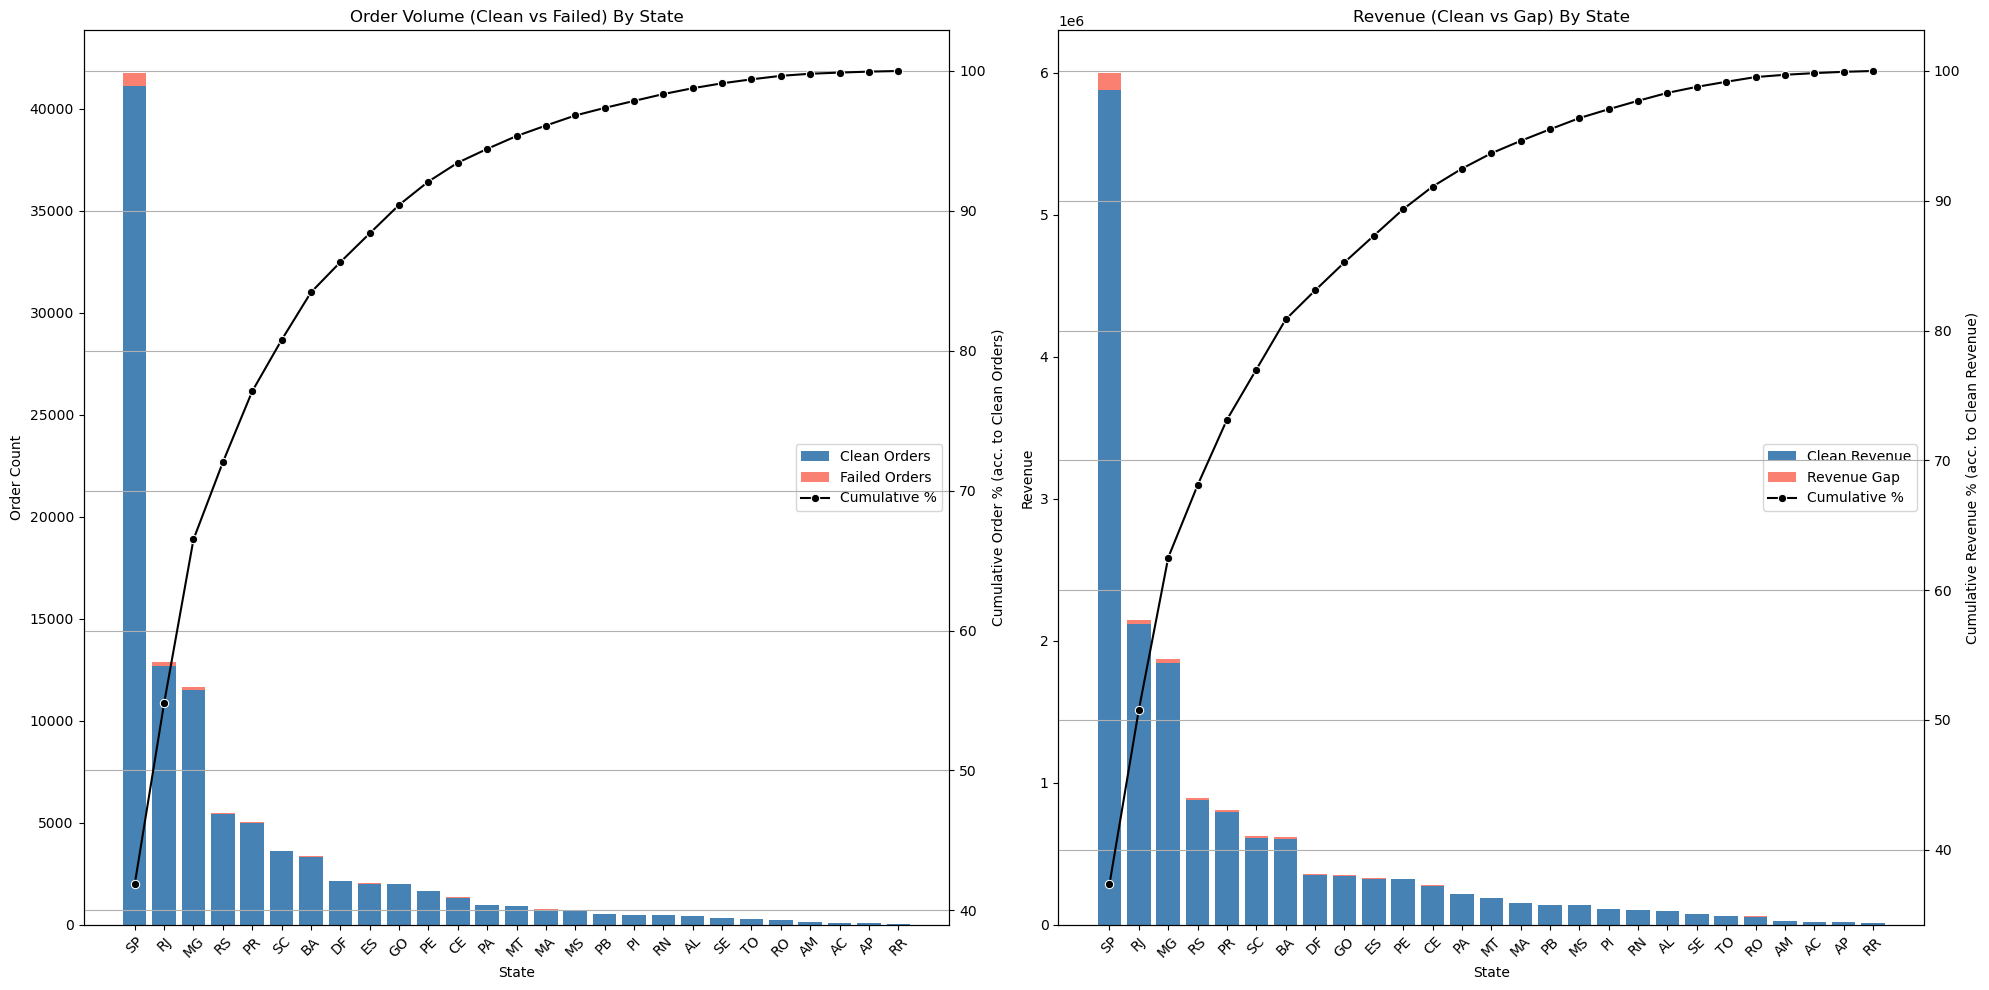

In [196]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

axes[0].bar(state_summary['customer_state'], state_summary['clean_orders'], label='Clean Orders', color='steelblue')
axes[0].bar(state_summary['customer_state'], state_summary['failed_orders'], bottom=state_summary['clean_orders'], 
            label='Failed Orders', color='salmon')
axes[0].set_title('Order Volume (Clean vs Failed) By State')
axes[0].set_xlabel('State')
axes[0].set_ylabel('Order Count')
axes[0].tick_params(axis='x', rotation=45)

ax0_twin = axes[0].twinx()
sns.lineplot(data=state_summary, x='customer_state', y='cumulative_order_pct', color='black', 
             marker='o', label='Cumulative %', ax=ax0_twin, legend = False)
ax0_twin.set_ylabel('Cumulative Order % (acc. to Clean Orders)')
ax0_twin.grid(axis = 'y')
# combine legend
lines1, labels1 = axes[0].get_legend_handles_labels()
lines2, labels2 = ax0_twin.get_legend_handles_labels()
axes[0].legend(lines1 + lines2, labels1 + labels2, loc='center right')

# re-sorted by clean_revenue 
state_summary_by_revenue = state_summary.sort_values('clean_revenue', ascending=False)

axes[1].bar(state_summary_by_revenue['customer_state'], state_summary_by_revenue['clean_revenue'], 
            label='Clean Revenue', color='steelblue')
axes[1].bar(state_summary_by_revenue['customer_state'], state_summary_by_revenue['revenue_gap'], 
            bottom=state_summary_by_revenue['clean_revenue'], label='Revenue Gap', color='salmon')
axes[1].set_title('Revenue (Clean vs Gap) By State')
axes[1].set_xlabel('State')
axes[1].set_ylabel('Revenue')
axes[1].tick_params(axis='x', rotation=45)

ax1_twin = axes[1].twinx()
sns.lineplot(data=state_summary_by_revenue, x='customer_state', y='cumulative_clean_revenue_pct', color='black', 
             marker='o', label='Cumulative %', ax=ax1_twin, legend = False)
ax1_twin.set_ylabel('Cumulative Revenue % (acc. to Clean Revenue)')
ax1_twin.grid(axis = 'y')

lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2, loc='center right')


plt.tight_layout()
plt.show()

- SP alone accounts for ~41.9% of clean orders and ~37.4% of clean revenue — the single largest state by a wide margin, more than 3x the second-ranked state (RJ).
- Top 3 states (SP, RJ, MG) already cover ~66.5% of order volume and ~62.5% of revenue — over half the business concentrated in just three states.
- Top 5 states cross the 75-77% mark for both metrics, meaning the remaining 22 states together contribute only around a quarter of total volume and revenue.

Note: cumulative % axis is not zero-based (auto-scaled ~30–40 start) — visual slope of the cumulative line is steeper in reality than it appears. 

In [197]:
state_summary[['clean_orders', 'clean_revenue']].corr()

,clean_orders,clean_revenue
clean_orders,1.000000,0.998524
clean_revenue,0.998524,1.000000


Correlation between clean_orders and clean_revenue across states: 0.9985 — near-perfect, indicating order volume and revenue scale together across states, with little to no state showing a probable high-volume-low-revenue or low-volume-high-revenue pattern.   
Correlation between clean_orders and clean_revenue: 0.9985 — expected, since both scale with a state's overall order volume; checks for exceptions to that pattern, not a meaningful relationship beyond scale.

In [198]:
# AOV by State 

In [199]:
# 9 payment_value=0 rows - which state they fall in
query = """SELECT p.order_id, o.order_status, payment_type, customer_state
FROM olist_order_payments_dataset p
JOIN olist_orders_dataset o
ON p.order_id = o.order_id
JOIN olist_customers_dataset c
ON o.customer_id = c.customer_id
WHERE p.payment_value = 0
ORDER BY p.order_id"""
zero_payment_check = pd.read_sql(query, engine)
zero_payment_check

,order_id,order_status,payment_type,customer_state
0,00b1cb0320190ca0daa2c88b35206009,canceled,not_defined,SP
1,45ed6e85398a87c253db47c2d9f48216,delivered,voucher,GO
2,4637ca194b6387e2d538dc89b124b0ee,canceled,not_defined,SP
3,6ccb433e00daae1283ccc956189c82ae,delivered,voucher,RJ
4,8bcbe01d44d147f901cd3192671144db,delivered,voucher,RJ
5,b23878b3e8eb4d25a158f57d96331b18,delivered,voucher,ES
6,c8c528189310eaa44a745b8d9d26908b,canceled,not_defined,SP
7,fa65dad1b0e818e3ccc5cb0e39231352,shipped,voucher,MT
8,fa65dad1b0e818e3ccc5cb0e39231352,shipped,voucher,MT


In [200]:
query = """SELECT p.order_id, o.order_status, COUNT(*) AS total_rows,
COUNT(*) FILTER (WHERE p.payment_value > 0) AS positive_payment_rows,
COUNT(*) FILTER (WHERE p.payment_value = 0) AS zero_rows
FROM olist_order_payments_dataset p
JOIN olist_orders_dataset o
ON p.order_id = o.order_id
WHERE p.order_id IN (SELECT DISTINCT order_id FROM olist_order_payments_dataset WHERE payment_value = 0)
GROUP BY p.order_id, o.order_status
ORDER BY p.order_id"""
zero_payment_check = pd.read_sql(query, engine)
zero_payment_check

,order_id,order_status,total_rows,positive_payment_rows,zero_rows
0,00b1cb0320190ca0daa2c88b35206009,canceled,1,0,1
1,45ed6e85398a87c253db47c2d9f48216,delivered,3,2,1
2,4637ca194b6387e2d538dc89b124b0ee,canceled,1,0,1
3,6ccb433e00daae1283ccc956189c82ae,delivered,4,3,1
4,8bcbe01d44d147f901cd3192671144db,delivered,4,3,1
5,b23878b3e8eb4d25a158f57d96331b18,delivered,4,3,1
6,c8c528189310eaa44a745b8d9d26908b,canceled,1,0,1
7,fa65dad1b0e818e3ccc5cb0e39231352,shipped,29,27,2


In [201]:
query = """WITH sequential_issues AS (
SELECT order_id, payment_sequential,
ROW_NUMBER() OVER (PARTITION BY order_id ORDER BY payment_sequential) AS expected_seq
FROM olist_order_payments_dataset),
bad_orders AS (
SELECT DISTINCT order_id
FROM sequential_issues
WHERE payment_sequential != expected_seq)
SELECT c.customer_state, order_status,
COUNT(DISTINCT o.order_id) AS affected_orders,
SUM(p.payment_value) AS affected_value
FROM bad_orders b
JOIN olist_orders_dataset o ON b.order_id = o.order_id
JOIN olist_customers_dataset c ON o.customer_id = c.customer_id
JOIN olist_order_payments_dataset p ON o.order_id = p.order_id
GROUP BY c.customer_state, o.order_status
ORDER BY c.customer_state"""
sequential_issue_summary = pd.read_sql(query, engine)
sequential_issue_summary

,customer_state,order_status,affected_orders,affected_value
0,BA,delivered,2,304.07
1,CE,delivered,2,379.83
2,ES,delivered,1,34.13
3,GO,delivered,1,584.33
4,MA,delivered,2,438.34
5,MG,delivered,7,1148.55
6,MT,delivered,1,88.72
7,PA,delivered,5,602.37
8,PE,delivered,3,643.97
9,PI,delivered,5,480.70


In [265]:
query = """WITH seq_issues AS (
SELECT order_id, payment_sequential, 
ROW_NUMBER() OVER (PARTITION BY order_id ORDER BY payment_sequential) AS expected_seq
FROM olist_order_payments_dataset),
bad_orders AS (
SELECT DISTINCT order_id FROM seq_issues WHERE payment_sequential != expected_seq),
affect_states AS (
SELECT c.customer_state, COUNT(DISTINCT b.order_id) AS affected_orders,
COALESCE(SUM(p.payment_value), 0) AS affected_gross_value,
COALESCE(SUM(p.payment_value) FILTER (WHERE o.order_status NOT IN ('unavailable', 'canceled')), 0) AS affected_clean_value,
COALESCE(SUM(p.payment_value) FILTER (WHERE o.order_status IN ('unavailable', 'canceled')), 0) AS affected_failed_value
FROM bad_orders b
JOIN olist_orders_dataset o ON b.order_id = o.order_id
JOIN olist_order_payments_dataset p ON b.order_id = p.order_id
JOIN olist_customers_dataset c ON o.customer_id = c.customer_id
GROUP BY c.customer_state),
state_totals AS (
SELECT customer_state, COALESCE(SUM(payment_value), 0) AS gross_revenue,
COALESCE(SUM(payment_value) FILTER (WHERE order_status NOT IN ('unavailable', 'canceled')), 0) AS clean_revenue,
COALESCE(SUM(payment_value) FILTER (WHERE order_status IN ('unavailable', 'canceled')), 0) AS failed_revenue
FROM olist_orders_dataset o
JOIN olist_order_payments_dataset p 
ON o.order_id = p.order_id
JOIN olist_customers_dataset c
ON o.customer_id = c.customer_id
GROUP BY customer_state)
SELECT a.customer_state, a.affected_orders,
a.affected_gross_value, s.gross_revenue, 
ROUND(CAST((100.0 * a.affected_gross_value / NULLIF(s.gross_revenue, 0)) AS NUMERIC), 3) AS gross_impact_pct,
a.affected_clean_value, s.clean_revenue, 
ROUND(CAST((100.0 * a.affected_clean_value / NULLIF(s.clean_revenue, 0)) AS NUMERIC), 3) AS clean_impact_pct,
a.affected_failed_value, s.failed_revenue, 
ROUND(CAST((100.0 * a.affected_failed_value / NULLIF(s.failed_revenue, 0)) AS NUMERIC), 3) AS failed_impact_pct
FROM affect_states a
JOIN state_totals s 
ON a.customer_state = s.customer_state
ORDER BY gross_impact_pct DESC"""
check = pd.read_sql(query, engine)
check

,customer_state,affected_orders,affected_gross_value,gross_revenue,gross_impact_pct,affected_clean_value,clean_revenue,clean_impact_pct,affected_failed_value,failed_revenue,failed_impact_pct
0,SE,1,847.38,75246.25,1.126,847.38,73032.32,1.160,0.00,2213.93,0.000
1,PI,6,742.67,108523.97,0.684,742.67,107859.45,0.689,0.00,664.52,0.000
2,MA,2,438.34,152523.02,0.287,438.34,150691.70,0.291,0.00,1831.32,0.000
3,TO,1,172.98,61485.33,0.281,172.98,61103.85,0.283,0.00,381.48,0.000
4,PA,5,602.37,218295.85,0.276,602.37,217484.52,0.277,0.00,811.33,0.000
5,PE,3,643.97,324850.44,0.198,643.97,321120.88,0.201,0.00,3729.56,0.000
6,GO,1,584.33,350092.31,0.167,584.33,340626.24,0.172,0.00,9466.07,0.000
7,CE,2,379.83,279464.03,0.136,379.83,274549.81,0.138,0.00,4914.22,0.000
8,SC,3,539.97,623086.43,0.087,539.97,608180.51,0.089,0.00,14905.92,0.000
9,RJ,10,1707.76,2144379.69,0.080,1707.76,2115994.28,0.081,0.00,28385.41,0.000


Sequential-issue impact spans 19 states, concentrated in SP (10 orders, ₹1,707.76) and RJ — consistent with these being the highest-volume states overall, not a state-specific anomaly.

SE's 1.126% impact looks large next to the earlier dataset-wide 0.08%, but this is a small-state denominator effect — SE's total gross revenue (75,246) is tiny, so even 1 affected order at 847 moves the percentage sharply. Same pattern for PI, MA, TO. Absolute values (affected_value column) confirm these are still small-dollar issues, not real state-level risk.

In [203]:
# State AOV (Gross, Clean, Failed) - order grain, sum valid payment_value by order_id first

# Excludes the 9 payment_value = 0 rows:
# - 3 belong to canceled orders with payment_type = 'not_defined' and only zero-value payment records.
# - 5 delivered/shipped orders contain additional positive payment rows, so excluding the zero rows
#   does not change their order value.
# This avoids treating zero-value payment records as valid monetary transactions in AOV.

# 80 orders with payment sequence integrity issues were assessed separately.
# Their contribution to state-level gross and clean revenue remained negligible,
# so they are retained in the analysis.

# Orders with no payment records (1 delivered order) are naturally excluded by the INNER JOIN.

query = """WITH order_totals AS (
SELECT o.order_id, o.order_status, c.customer_state, 
SUM(p.payment_value) AS order_value
FROM olist_orders_dataset o
JOIN olist_order_payments_dataset p ON o.order_id = p.order_id
JOIN olist_customers_dataset c ON o.customer_id = c.customer_id
WHERE p.payment_value > 0
GROUP BY o.order_id, o.order_status, c.customer_state)
SELECT customer_state,
COALESCE(SUM(order_value) / NULLIF(COUNT(*),0),0) AS gross_aov,
COALESCE(SUM(order_value) FILTER (WHERE order_status NOT IN ('unavailable','canceled')) 
/ NULLIF(COUNT(*) FILTER (WHERE order_status NOT IN ('unavailable','canceled')),0),0) AS clean_aov,
COALESCE(SUM(order_value) FILTER (WHERE order_status IN ('unavailable','canceled')) 
/ NULLIF(COUNT(*) FILTER (WHERE order_status IN ('unavailable','canceled')),0),0) AS failed_aov
FROM order_totals
GROUP BY customer_state
ORDER BY clean_aov DESC"""
state_aov = pd.read_sql(query, engine)
state_aov

,customer_state,gross_aov,clean_aov,failed_aov
0,PB,264.077836,264.631959,205.230000
1,AC,242.970617,242.970617,0.000000
2,AP,239.158824,239.158824,0.000000
3,AL,234.774964,234.191484,354.680000
4,RO,240.577866,233.469390,490.390000
5,PA,223.893179,224.442229,135.221667
6,RR,218.796087,221.088222,115.650000
7,PI,219.240343,220.121327,132.904000
8,TO,219.590464,219.798022,190.740000
9,SE,214.989286,211.687884,442.786000


Failed AOV swings wildly by state — this reflects tiny sample sizes (a handful of failed orders per state), not a real regional pattern. Not reliable for comparison at this grain

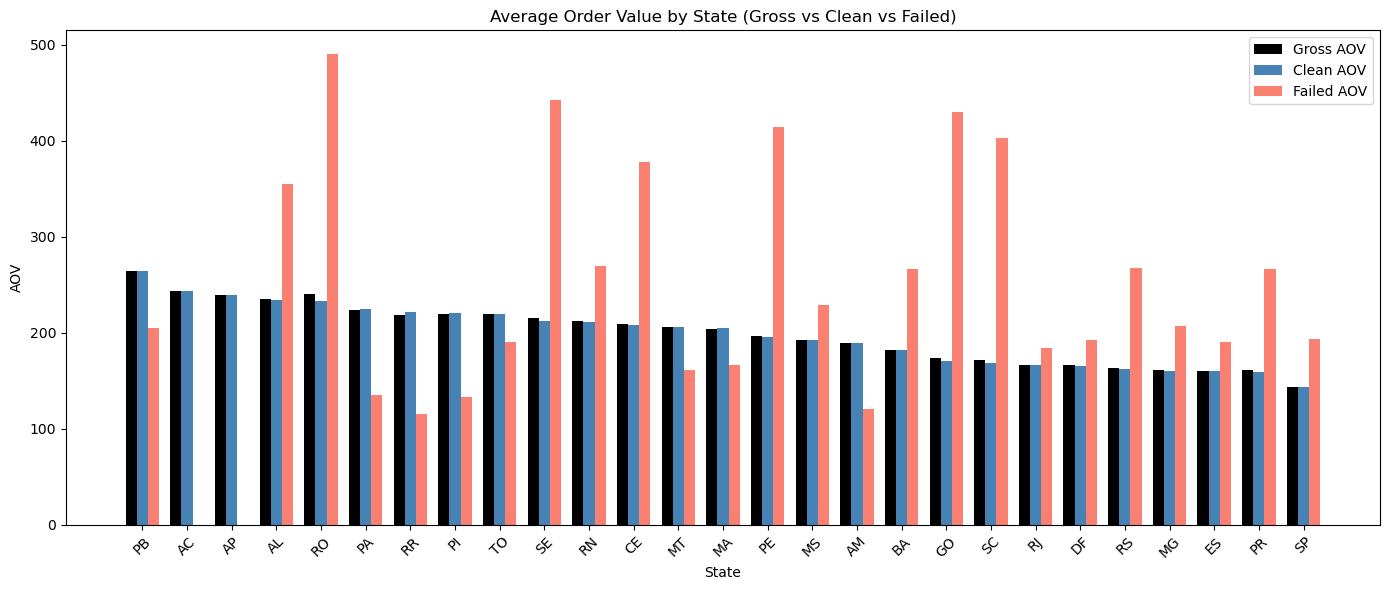

In [204]:
fig, ax = plt.subplots(figsize=(14, 6))
x = range(len(state_aov))
width = 0.25

ax.bar([i - width for i in x], state_aov['gross_aov'], width=width, label='Gross AOV', color='black')
ax.bar(x, state_aov['clean_aov'], width=width, label='Clean AOV', color='steelblue')
ax.bar([i + width for i in x], state_aov['failed_aov'], width=width, label='Failed AOV', color='salmon')

ax.set_xticks(x)
ax.set_xticklabels(state_aov['customer_state'], rotation=45)
ax.set_title('Average Order Value by State (Gross vs Clean vs Failed)')
ax.set_xlabel('State')
ax.set_ylabel('AOV')
ax.legend()
plt.tight_layout()
plt.show()

SP dominates by volume and revenue but has the lowest AOV of any state — high order count, individually lower-value orders. Small states like PB, AC, AP show the opposite: few orders, but each worth more on average.

The AOV differences between high- and low-volume states may partly reflect real regional pricing/purchasing behavior, but low-volume states (PB, AC, AP, RO, PI — all near the bottom of the order volume chart) are more susceptible to small-sample distortion: a single high- or low-value order swings their average far more than it would for SP or RJ. 

## Understanding Regional Sales Patterns

The previous analysis showed noticeable differences in revenue, order volume, and average order value (AOV) across states. The following analyses explore a few possible factors that may help interpret these regional patterns.

- **Freight Cost** – Variation in freight charges across states.
- **Seller Concentration** – Distribution of sellers across states.
- **Items per Order** – Differences in basket size.
- **Order Value Distribution** – Variation in customer spending patterns.

In [205]:
# Order-Level Freight Analysis by State

# Freight is aggregated from the item level to the order level.
# All recorded orders are included, as freight is treated as an order characteristic rather than a completed-sales metric.

query = """WITH order_freight AS (
SELECT order_id, SUM(freight_value) AS freight_per_order
FROM olist_order_items_dataset
GROUP BY order_id)
SELECT customer_state, MIN(freight_per_order) AS min_freight,
AVG(freight_per_order) AS mean_freight,
PERCENTILE_CONT(0.50) WITHIN GROUP (ORDER BY freight_per_order) AS median_freight,
MAX(freight_per_order) AS max_freight
FROM order_freight f
JOIN olist_orders_dataset o ON f.order_id = o.order_id
JOIN  olist_customers_dataset c ON c.customer_id = o.customer_id
GROUP BY customer_state
ORDER BY median_freight DESC"""
freight_state = pd.read_sql(query, engine)
freight_state

,customer_state,min_freight,mean_freight,median_freight,max_freight
0,AC,24.35,45.515432,39.270,167.04
1,RO,0.00,46.224211,38.310,217.53
2,PB,0.00,48.345357,36.015,1794.96
3,MA,0.00,42.599689,35.050,711.33
4,RN,0.00,39.128838,34.975,312.41
5,PI,0.00,43.038945,34.430,409.68
6,TO,0.00,42.052616,34.150,301.12
7,AL,0.00,38.721630,34.150,314.40
8,RR,25.38,48.591087,32.290,167.92
9,SE,0.00,40.902812,31.980,251.32


PB's max freight (1,794.96) is a clear outlier vs. every other state's max (all under 1,010)

In [266]:
# Seller Concentration Analysis by State

# Count unique sellers by state and calculate the cumulative seller contribution
# using a row-wise cumulative sum.

query = """SELECT seller_state, COUNT(*) AS seller_count,
100.0 * SUM(COUNT(*)) OVER (ORDER BY COUNT(*) DESC, seller_state ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) 
/ SUM(COUNT(*)) OVER () AS cumulative_dist
FROM olist_sellers_dataset
GROUP BY seller_state
ORDER BY seller_count DESC;"""
state_sellers = pd.read_sql(query, engine)
state_sellers

,seller_state,seller_count,cumulative_dist
0,SP,1849,59.741519
1,PR,349,71.017771
2,MG,244,78.901454
3,SC,190,85.040388
4,RJ,171,90.565428
5,RS,129,94.733441
6,GO,40,96.025848
7,DF,30,96.995153
8,ES,23,97.738288
9,BA,19,98.352181


SP alone = 59.7% of all sellers, and top 3 states (SP, PR, MG) = ~79%

SP has ~42% of orders/revenue but ~60% of sellers

In [207]:
# Order-Level Items Analysis by State

# Items are aggregated from item level to order level.
# Each order's item count is calculated first, then summarized by customer state.

query = """WITH order_items AS (
SELECT order_id, COUNT(order_item_id) AS items_per_order
FROM olist_order_items_dataset
GROUP BY order_id)
SELECT customer_state, COUNT(*) AS total_orders_gross,
MIN(items_per_order) AS min_items,
AVG(items_per_order) AS mean_items,
PERCENTILE_DISC(0.50) WITHIN GROUP (ORDER BY items_per_order) AS median_items,
MAX(items_per_order) AS max_items
FROM order_items oi
JOIN olist_orders_dataset o ON oi.order_id = o.order_id
JOIN olist_customers_dataset c ON c.customer_id = o.customer_id
GROUP BY customer_state
ORDER BY mean_items DESC;"""
items_state = pd.read_sql(query, engine)
items_state

,customer_state,total_orders_gross,min_items,mean_items,median_items,max_items
0,AP,68,1,1.205882,1,5
1,MT,903,1,1.168328,1,6
2,GO,2007,1,1.162431,1,20
3,SC,3612,1,1.156146,1,12
4,MS,709,1,1.155148,1,6
5,PR,4998,1,1.148459,1,15
6,RS,5432,1,1.147828,1,10
7,SP,41375,1,1.146804,1,21
8,RJ,12762,1,1.142376,1,10
9,MG,11544,1,1.137301,1,12


Mean items/order is remarkably consistent across all states (1.08–1.21

In [208]:
# Product Price Mix Analysis by State

# A representative selling price is calculated for each product using its
# weighted average transaction price across the entire marketplace.

# Global price benchmarks are used to create product price segments, 
# ensuring a consistent basis for comparison across all customer states.
# State-specific price thresholds are intentionally avoided, as the dataset does not contain income or purchasing power information.

In [209]:
# Representative Product Price Calculation

# Each row in the order_items table represents one purchased item.
# Since repeated purchases are stored as separate rows (not a quantity column),
# the average price of each product naturally reflects its overall selling price.

query = """SELECT product_id, AVG(price) AS representative_price
FROM olist_order_items_dataset
GROUP BY product_id"""
rep_price_prod = pd.read_sql(query, engine)
rep_price_prod

,product_id,representative_price
0,027293c3b6d9e221268d9d6a5ffe5d0b,699.99
1,9ad4fb75641c9a71f995a06d0386a6f9,62.00
2,5ed2407e517ceac8615bb4d1ea238fe6,22.99
3,8e630a6101b33d99671d79b67b87052d,599.00
4,cf41f723df264ec6f1c74d1caca1642e,279.49
...,...,...
32946,4f27f0b527bb700ed8541270356a38f3,28.90
32947,c770c3d5ab511e88a96d387bdb0b6ce0,55.00
32948,f663f7a6fc390011dd15492f14205573,22.90
32949,df1ff6c9a263464ba1ea7cd3de5e8633,23.63


In [210]:
query = """WITH rep_prod AS (
SELECT product_id, AVG(price) AS representative_price
FROM olist_order_items_dataset
GROUP BY product_id)
SELECT MIN(representative_price) AS min_rep_price,
PERCENTILE_CONT (0.25) WITHIN GROUP (ORDER BY representative_price) AS p25_rep_price,
PERCENTILE_CONT (0.50) WITHIN GROUP (ORDER BY representative_price) AS p50_rep_price,
PERCENTILE_CONT (0.75) WITHIN GROUP (ORDER BY representative_price) AS p75_rep_price,
MAX(representative_price) AS max_rep_price
FROM rep_prod"""
rep_price_prod = pd.read_sql(query, engine)
rep_price_prod

,min_rep_price,p25_rep_price,p50_rep_price,p75_rep_price,max_rep_price
0,0.85,39.9,79.0,154.9,6735.0


In [211]:
p_tiles = np.arange(0.70, 0.995, 0.01)
for i in p_tiles:
    query = f"""WITH rep_prod AS (
    SELECT product_id, AVG(price) AS representative_price
    FROM olist_order_items_dataset
    GROUP BY product_id) 
    SELECT PERCENTILE_CONT({i:.2f}) WITHIN GROUP (ORDER BY representative_price) AS p_{int(100 * i)}
    FROM rep_prod"""
    check = pd.read_sql(query, engine)
    print(check)

      p_70
0  133.475
    p_71
0  139.0
    p_72
0  140.0
         p_73
0  146.653333
    p_74
0  149.9
    p_75
0  154.9
    p_76
0  159.9
    p_77
0  165.0
    p_78
0  169.9
         p_79
0  177.116429
     p_80
0  179.99
    p_81
0  189.0
    p_82
0  195.0
    p_83
0  199.9
    p_84
0  209.0
    p_85
0  219.9
     p_86
0  229.99
         p_87
0  246.052273
    p_88
0  259.0
         p_89
0  276.583333
      p_90
0  295.225
       p_91
0  313.9475
         p_92
0  341.985714
    p_93
0  375.0
    p_94
0  405.0
      p_95
0  479.945
         p_96
0  567.813333
       p_97
0  673.6875
    p_98
0  829.0
     p_99
0  1199.0


Re-running the percentile scan here (this time on AVG(price) per product rather than times_ordered) to independently derive price-tier cutoffs for the state-level product mix analysis below.

In [212]:
# Product Price Segmentation

# Products are grouped into Low-, Medium-, and High-price categories using representative product prices. 
# The thresholds (200 and 500) were selected after examining the overall price distribution and higher percentiles,
# where the upper tail showed a noticeable increase in price spread.

query = """WITH product_categories AS (
SELECT product_id, 
CASE WHEN AVG(price) >= 500 THEN 'High'
WHEN AVG(price) >= 200 THEN 'Medium'
ELSE 'Low'
END AS price_category
FROM olist_order_items_dataset
GROUP BY product_id)
SELECT c.customer_state,
ROUND(100.0 * COUNT(*) FILTER (WHERE pc.price_category = 'Low') / COUNT(*), 2) AS low_pct,
ROUND(100.0 * COUNT(*) FILTER (WHERE pc.price_category = 'Medium') / COUNT(*), 2) AS medium_pct,
ROUND(100.0 * COUNT(*) FILTER (WHERE pc.price_category = 'High') / COUNT(*), 2) AS high_pct
FROM olist_order_items_dataset oi
JOIN olist_orders_dataset o ON oi.order_id = o.order_id
JOIN olist_customers_dataset c ON o.customer_id = c.customer_id
JOIN product_categories pc ON oi.product_id = pc.product_id
GROUP BY c.customer_state
ORDER BY COUNT(*)"""
price_cat_state = pd.read_sql(query, engine)
price_cat_state

,customer_state,low_pct,medium_pct,high_pct
0,RR,69.23,25.00,5.77
1,AP,80.49,12.20,7.32
2,AC,76.09,15.22,8.70
3,AM,86.06,9.70,4.24
4,RO,82.01,12.23,5.76
5,TO,81.90,12.70,5.40
6,SE,81.30,14.29,4.42
7,AL,77.48,14.64,7.88
8,RN,80.53,13.04,6.43
9,PI,78.78,14.94,6.27


In [213]:
# distribution check
query = """WITH price_cat AS (
SELECT product_id, AVG(price) AS representative_price,
CASE WHEN AVG(price) >= 500 THEN 'High'
WHEN AVG(price) >= 200 AND AVG(price) < 500 THEN 'Medium'
ELSE 'Low' 
END AS price_category
FROM olist_order_items_dataset
GROUP BY product_id)
SELECT price_category, COUNT(*) AS product_count,
ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct_products
FROM price_cat
GROUP BY price_category
ORDER BY pct_products"""
price_cat = pd.read_sql(query,engine)
price_cat

,price_category,product_count,pct_products
0,High,1523,4.62
1,Medium,3921,11.90
2,Low,27507,83.48


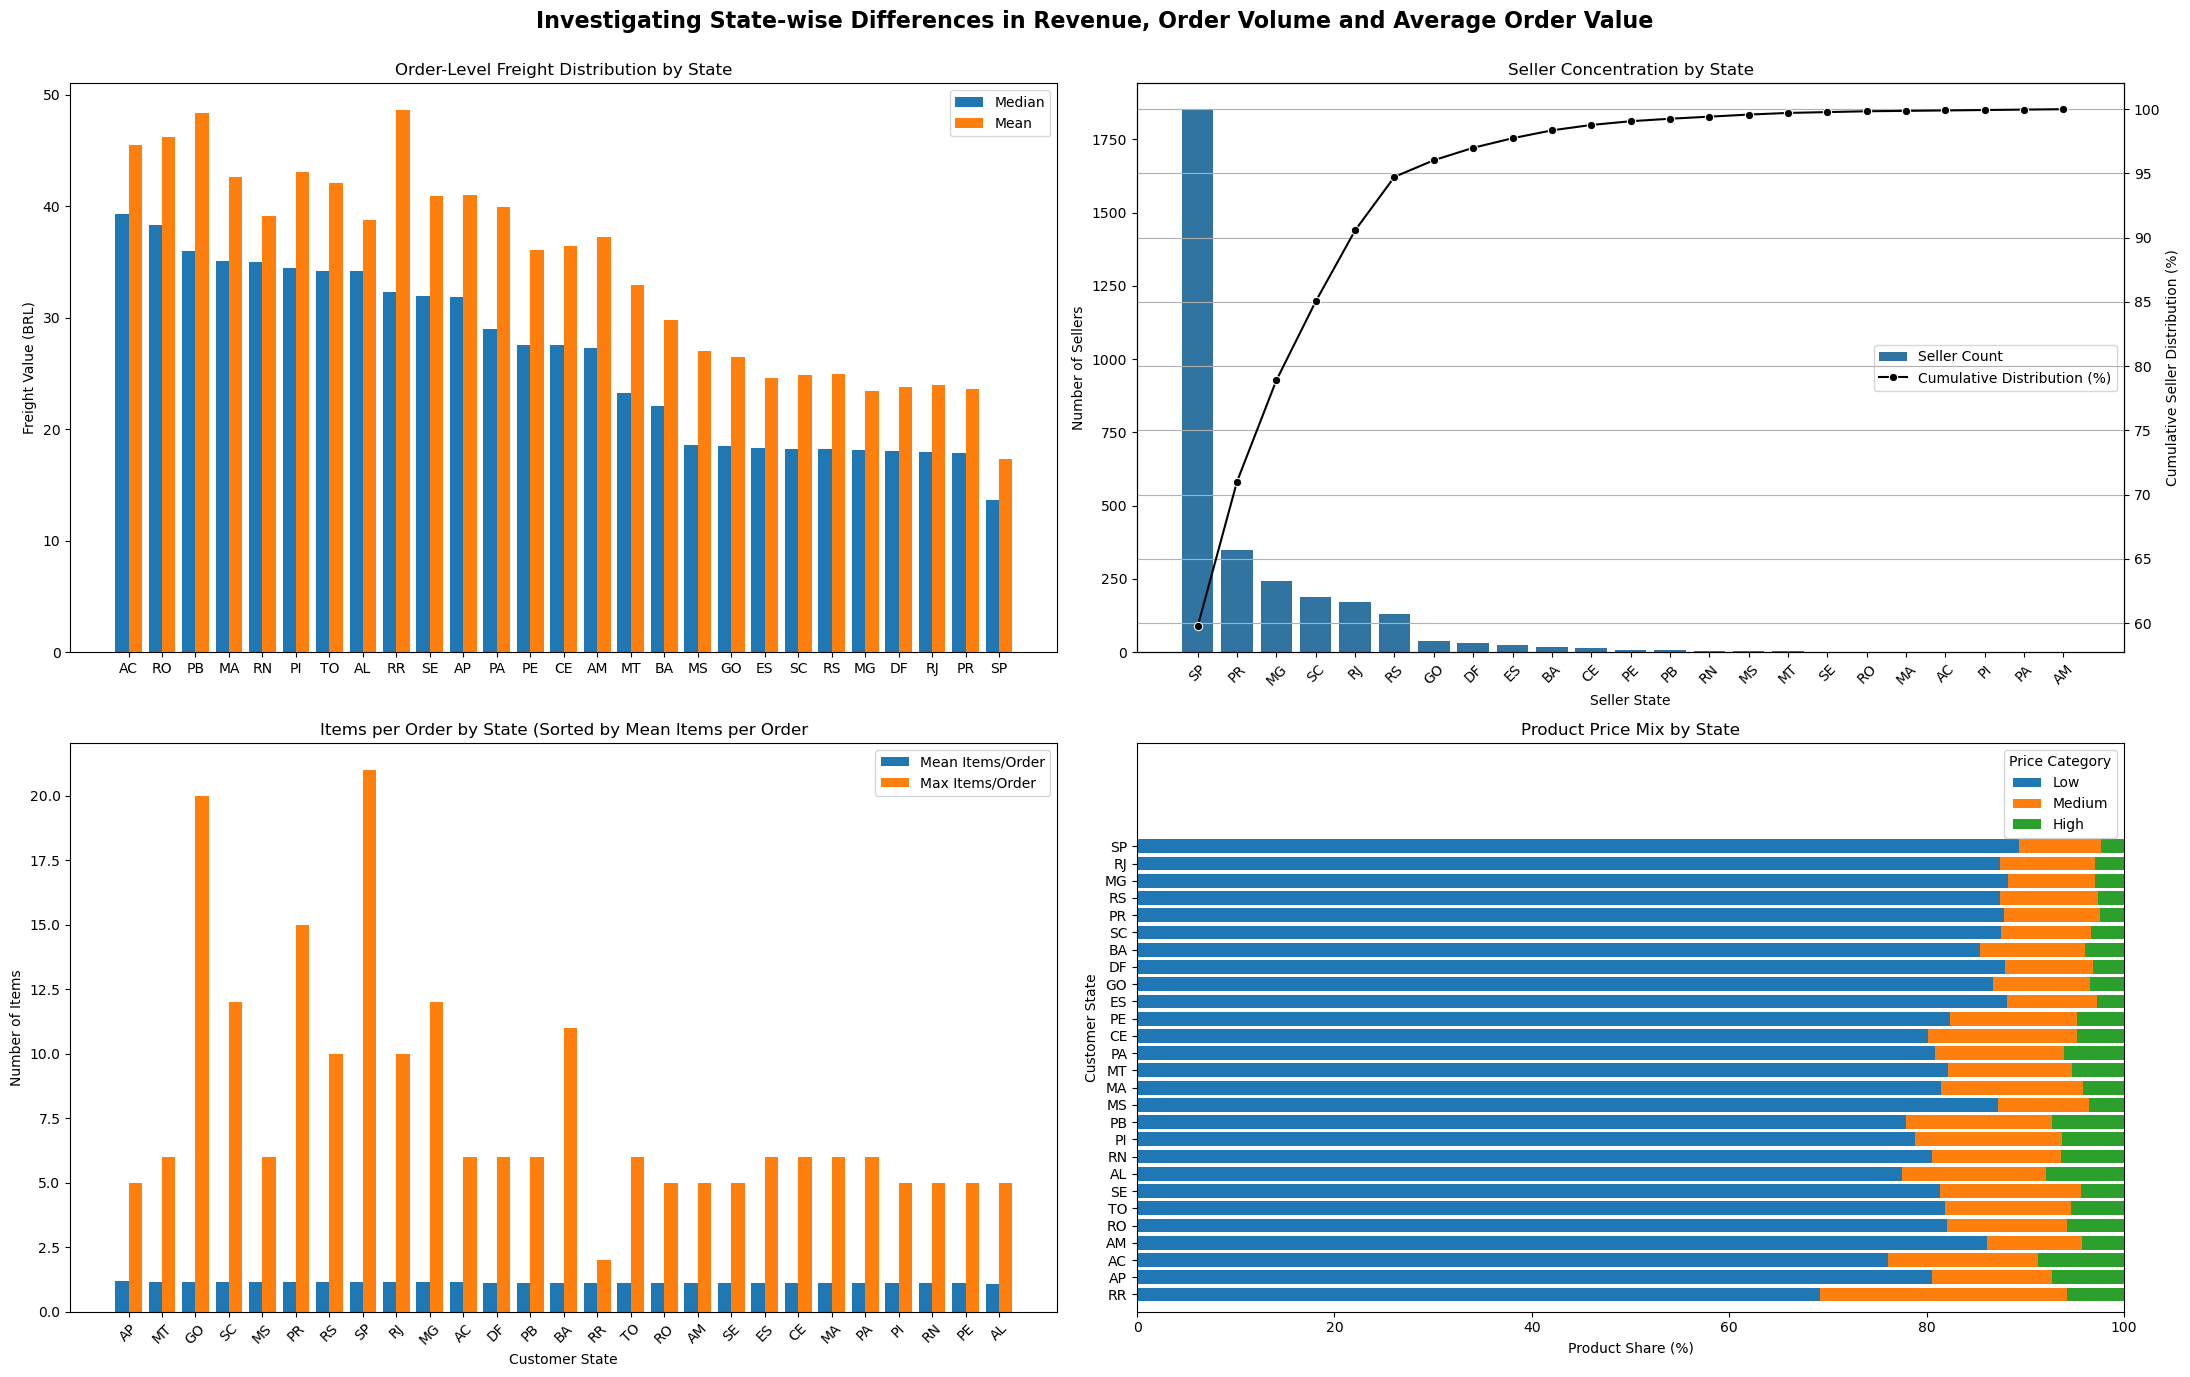

In [214]:
fig, axes = plt.subplots(2, 2, figsize=(22, 14))
fig.suptitle("Investigating State-wise Differences in Revenue, Order Volume and Average Order Value", fontsize=16, fontweight='bold')

x = np.arange(len(freight_state)) 
w = 0.4
axes[0, 0].bar(x - w/2, freight_state["median_freight"], width = w, label="Median")
axes[0, 0].bar(x + w/2, freight_state["mean_freight"], width = w, label="Mean")
# Maximum freight values were retained to identify extreme cases, but due to large outliers they are not included in the comparison chart.
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(freight_state["customer_state"])
axes[0, 0].set_ylabel("Freight Value (BRL)")
axes[0, 0].set_title("Order-Level Freight Distribution by State")
axes[0, 0].legend()

sns.barplot(data = state_sellers, x = "seller_state", y = "seller_count", label="Seller Count", ax = axes[0,1], legend = False)
axes[0, 1].set_xlabel("Seller State")
axes[0, 1].set_ylabel("Number of Sellers")
axes[0, 1].tick_params(axis="x", rotation=45)
ax2_twin = axes[0, 1].twinx()
sns.lineplot(data = state_sellers, x = "seller_state", y = "cumulative_dist", color = "black", marker="o", markerfacecolor = "black",
             label="Cumulative Distribution (%)", ax=ax2_twin, legend = False)
ax2_twin.set_ylabel("Cumulative Seller Distribution (%)")
ax2_twin.grid(axis = 'y')
axes[0,1].set_title("Seller Concentration by State")
# Combined legend
bars, labels = axes[0,1].get_legend_handles_labels()
lines, labels2 = ax2_twin.get_legend_handles_labels()
axes[0,1].legend( bars + lines, labels + labels2, loc="center right")

x = np.arange(len(items_state))
axes[1, 0].bar(x - w/2, items_state["mean_items"], width = w, label="Mean Items/Order")
axes[1, 0].bar(x + w/2,items_state["max_items"], width = w,label="Max Items/Order")
# Median is excluded from visualization as it is constant (1 item/order) across all states
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(items_state["customer_state"],rotation=45,ha="center")
axes[1, 0].set_ylabel("Number of Items")
axes[1, 0].set_xlabel("Customer State")
axes[1, 0].set_title("Items per Order by State (Sorted by Mean Items per Order")
axes[1, 0].legend()

axes[1, 1].barh(price_cat_state["customer_state"], price_cat_state["low_pct"], label="Low")
axes[1, 1].barh(price_cat_state["customer_state"], price_cat_state["medium_pct"], left=price_cat_state["low_pct"], label="Medium")
axes[1, 1].barh(price_cat_state["customer_state"],  price_cat_state["high_pct"], 
                left=price_cat_state["low_pct"] + price_cat_state["medium_pct"],label="High")
axes[1, 1].set_xlim(0, 100)
axes[1, 1].set_ylim(-1, len(price_cat_state["customer_state"]) + 5) 
axes[1, 1].set_xlabel("Product Share (%)")
axes[1, 1].set_ylabel("Customer State")
axes[1, 1].set_title("Product Price Mix by State")
axes[1, 1].legend(title="Price Category")

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

RR shows a visibly different price mix from other states — lowering share of Low-tier products 

Low-order-volume states show consistently higher freight and a costlier product mix (less Low-tier share) compared to high-volume states like SP — while basket size (items/order) stays flat across all states. This suggests freight and price-tier composition, not basket size, are the more likely drivers of the AOV differences seen earlier by state. 
Correlational, not decomposed — small-sample caution still applies for low-volume states.

In [267]:
# Data Quality Check - Delivered Orders with Missing Delivery Dates

# Check whether any delivered orders have missing actual or estimated delivery dates.
# This is used to validate the denominator and late delivery rate calculation.

query = """SELECT COUNT(*) AS delivered_orders,
COUNT(*) FILTER (WHERE order_delivered_customer_date IS NULL) AS null_delivered_date,
COUNT(*) FILTER (WHERE order_estimated_delivery_date IS NULL) AS null_estimated_date,
COUNT(*) FILTER (WHERE order_delivered_customer_date IS NULL OR order_estimated_delivery_date IS NULL) 
AS orders_with_missing_dates
FROM olist_orders_dataset
WHERE order_status = 'delivered'"""
delivery_date_check = pd.read_sql(query, engine)
delivery_date_check

,delivered_orders,null_delivered_date,null_estimated_date,orders_with_missing_dates
0,96478,8,0,8


In [216]:
# Data quality check confirmed that only 8 delivered orders have missing delivery dates (~0.008%).
# These orders are excluded from the late-order classification by applying NULL checks,
# while the delivered order count continues to follow the recorded order status.

In [217]:
# Late Delivery Rate by State

query = """WITH state_delivery AS (
SELECT customer_state, COUNT(*) AS total_delivered_orders,
COUNT(*) FILTER (WHERE o.order_delivered_customer_date IS NOT NULL 
AND o.order_delivered_customer_date > o.order_estimated_delivery_date) AS late_orders
FROM olist_orders_dataset o
JOIN olist_customers_dataset c
ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered'
GROUP BY customer_state)
SELECT *,
ROUND(100.0 * late_orders / total_delivered_orders, 2) AS late_delivery_rate
FROM state_delivery
ORDER BY late_delivery_rate DESC"""
late_delivery_state = pd.read_sql(query, engine)
late_delivery_state

,customer_state,total_delivered_orders,late_orders,late_delivery_rate
0,AL,397,95,23.93
1,MA,717,141,19.67
2,PI,476,76,15.97
3,CE,1279,196,15.32
4,SE,335,51,15.22
5,BA,3256,457,14.04
6,RJ,12350,1664,13.47
7,TO,274,35,12.77
8,PA,946,117,12.37
9,ES,1995,244,12.23


In [218]:
# Cancellation Rate by State

# Cancellation rate is calculated using all recorded orders.
# Orders with the status 'canceled' are classified as cancelled orders.

query = """WITH state_orders AS (
SELECT customer_state, COUNT(*) AS total_orders,
COUNT(*) FILTER (WHERE o.order_status = 'canceled') AS cancelled_orders
FROM olist_orders_dataset o
JOIN olist_customers_dataset c
ON o.customer_id = c.customer_id
GROUP BY c.customer_state)
SELECT *,
ROUND(100.0 * cancelled_orders / total_orders, 2) AS cancellation_rate
FROM state_orders
ORDER BY cancellation_rate DESC"""

cancellation_state = pd.read_sql(query, engine)
cancellation_state

,customer_state,total_orders,cancelled_orders,cancellation_rate
0,RR,46,1,2.17
1,RO,253,3,1.19
2,PI,495,4,0.81
3,SP,41746,327,0.78
4,RJ,12852,86,0.67
5,GO,2020,13,0.64
6,MG,11635,64,0.55
7,MA,747,4,0.54
8,CE,1336,7,0.52
9,SC,3637,19,0.52


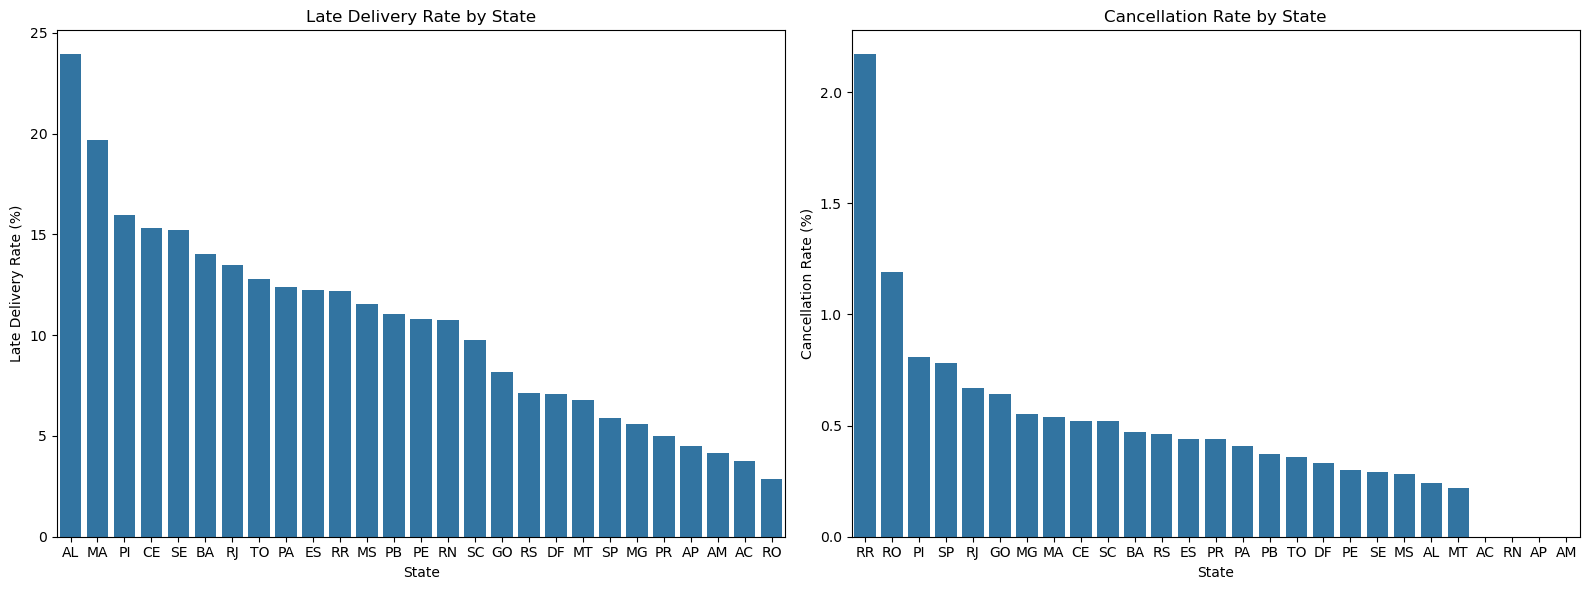

In [219]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=late_delivery_state, x="customer_state", y="late_delivery_rate", ax=ax[0])
ax[0].set_title("Late Delivery Rate by State")
ax[0].set_xlabel("State")
ax[0].set_ylabel("Late Delivery Rate (%)")

sns.barplot(data=cancellation_state, x="customer_state", y="cancellation_rate", ax=ax[1])

ax[1].set_title("Cancellation Rate by State")
ax[1].set_xlabel("State")
ax[1].set_ylabel("Cancellation Rate (%)")

plt.tight_layout()
plt.show()

**Note:** These are percentage-based metrics and should be interpreted along with their underlying counts (total delivered orders, late orders, total orders, and cancelled orders), especially for states with relatively low order volumes where small count differences can have a larger impact on the percentages.

ate delivery shows wide variance among low-volume states rather than a consistent direction. AL (23.93%) and MA (19.67%) top the chart, both small-order states — but RO (2.88%), AC (3.75%), and AM (4.14%) sit at the very bottom, also small-order states. High-volume states (SP, MG, PR, RJ) stay clustered in a narrower mid-to-low band, never hitting either extreme. This points to small-sample volatility at the state level rather than a "low volume = worse delivery" effect 

RR (2.17%) and RO (1.19%) top the cancellation chart, but both come from very small order counts — RR's rate is driven by just 1 cancellation out of 46 total orders, not a reliable signal. AC, RN, AP, and AM show exactly 0%, again because their order counts are too low for any cancellation to have occurred yet.

In [220]:
# State-wise Delivery Metrics + Clean AOV

query = """WITH delivery_cte AS (
SELECT customer_state,
ROUND(PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY EXTRACT(EPOCH FROM (order_delivered_customer_date::TIMESTAMP - 
order_purchase_timestamp::TIMESTAMP)) / 86400.0)::NUMERIC, 2) AS median_delivery_days,
ROUND(100.0 * COUNT(*) FILTER (WHERE order_delivered_customer_date::TIMESTAMP > order_estimated_delivery_date::TIMESTAMP
) / COUNT(*), 2) AS late_delivery_rate
FROM olist_orders_dataset o
JOIN olist_customers_dataset c ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered'
AND order_delivered_customer_date IS NOT NULL
AND order_delivered_customer_date::TIMESTAMP >= order_purchase_timestamp::TIMESTAMP
GROUP BY c.customer_state),
revenue_cte AS (
SELECT customer_state,
COUNT(DISTINCT o.order_id) AS clean_orders,
SUM(p.payment_value) AS clean_revenue
FROM olist_orders_dataset o
JOIN olist_customers_dataset c ON o.customer_id = c.customer_id
JOIN olist_order_payments_dataset p ON o.order_id = p.order_id
WHERE order_status NOT IN ('canceled','unavailable')
GROUP BY c.customer_state)
SELECT d.customer_state, d.median_delivery_days, d.late_delivery_rate, r.clean_orders, 
ROUND(r.clean_revenue::NUMERIC,2) AS clean_revenue,
ROUND((r.clean_revenue / r.clean_orders)::NUMERIC,2) AS clean_aov
FROM delivery_cte d
JOIN revenue_cte r ON d.customer_state = r.customer_state
ORDER BY d.median_delivery_days DESC;"""

state_delivery_analysis = pd.read_sql(query, engine)
state_delivery_analysis

,customer_state,median_delivery_days,late_delivery_rate,clean_orders,clean_revenue,clean_aov
0,AM,25.88,4.14,147,27846.44,189.43
1,RR,25.01,12.20,45,9948.97,221.09
2,AP,24.35,4.48,68,16262.80,239.16
3,AL,22.33,23.93,411,96252.70,234.19
4,PA,21.08,12.37,969,217484.52,224.44
5,MA,19.19,19.67,736,150691.70,204.74
6,AC,18.36,3.75,81,19680.62,242.97
7,CE,18.21,15.32,1323,274549.81,207.52
8,PB,18.15,11.03,531,140519.57,264.63
9,SE,18.01,15.22,345,73032.32,211.69


 AM has the longest median delivery time (25.88 days, highest of all states) but only a 4.14% late rate - well below AL (22.33 days, but 23.93% late) or MA (19.19 days, 19.67% late). Similarly, RO takes 17.58 days on median (mid-pack) but has the lowest late rate at 2.88%.

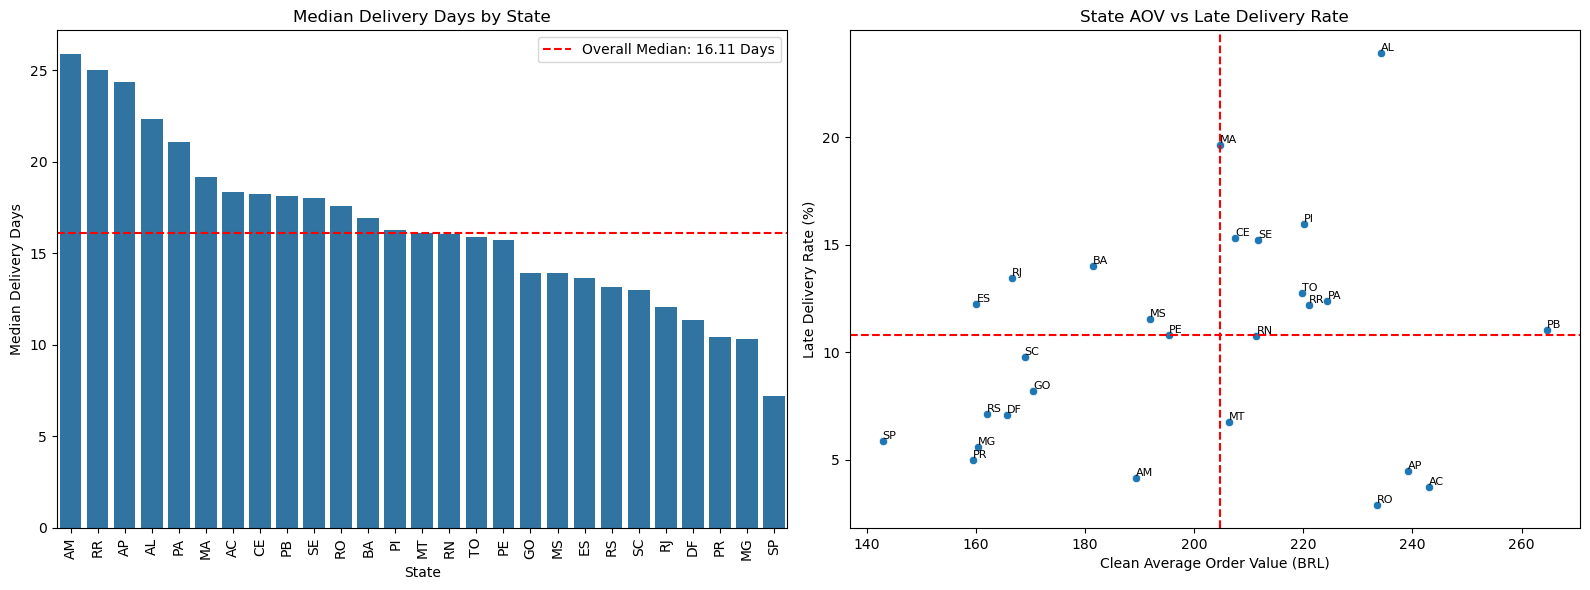

In [271]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=state_delivery_analysis, x="customer_state", y="median_delivery_days", ax=axes[0])
axes[0].axhline(state_delivery_analysis["median_delivery_days"].median(), color="red", linestyle="--",
                label=f"Overall Median: {state_delivery_analysis["median_delivery_days"].median()} Days")
axes[0].set_title("Median Delivery Days by State")
axes[0].set_xlabel("State")
axes[0].set_ylabel("Median Delivery Days")
axes[0].tick_params(axis="x", rotation=90)
axes[0].legend(loc="upper right")

for _, row in state_delivery_analysis.iterrows():
    axes[1].text(row["clean_aov"], row["late_delivery_rate"], row["customer_state"],
                 fontsize=8, ha="left", va="bottom")

sns.scatterplot(data=state_delivery_analysis,x="clean_aov", y="late_delivery_rate", ax=axes[1])
axes[1].axvline(state_delivery_analysis["clean_aov"].median(), color="red", linestyle="--")
axes[1].axhline(state_delivery_analysis["late_delivery_rate"].median(), color="red", linestyle="--")
axes[1].set_title("State AOV vs Late Delivery Rate")
axes[1].set_xlabel("Clean Average Order Value (BRL)")
axes[1].set_ylabel("Late Delivery Rate (%)")

plt.tight_layout()
plt.show()

States split into four groups based on median clean AOV (~205 BRL) and median late delivery rate (~10.8%):
Efficient (Low AOV, Low Late Rate)
SP, MG, PR, RS, DF, MT, AM, GO
Underperforming (Low AOV, High Late Rate)
MA, BA, RJ, ES, MS, PE, RN
Strong (High AOV, Low Late Rate)
AP, AC, RO, PB
At-Risk (High AOV, High Late Rate)
AL, CE, SE, PI, TO, PA, RR

In [270]:
# Data Quality Check - City and State Relationship

# Check whether city names are uniquely mapped to states,
# As repeated city names across states may affect city-level aggregation.
query = """WITH combined_locations AS (
SELECT customer_city AS city, customer_state AS state, 'customer' AS source
FROM olist_customers_dataset
UNION
SELECT seller_city AS city, seller_state AS state, 'seller' AS source
FROM olist_sellers_dataset)
SELECT city, COUNT(DISTINCT state) AS state_count
FROM combined_locations
GROUP BY city
HAVING COUNT(DISTINCT state) > 1
ORDER BY state_count DESC"""
city_state_check = pd.read_sql(query, engine)
city_state_check

,city,state_count
0,santa maria,4
1,vera cruz,4
2,planalto,4
3,boa esperanca,4
4,bonito,4
...,...,...
183,buritis,2
184,cachoeira dourada,2
185,cafelandia,2
186,campo alegre,2


188 distinct city names are shared across 2+ states (up to 4 states for names like "santa maria," "vera cruz," "planalto") - common Brazilian place names repeating nationally, not a data quality defect.   
This confirms customer_city alone is not a safe grouping key for city-level analysis; all city-level work in this notebook uses (customer_city, customer_state) together to avoid merging unrelated cities that happen to share a name.

In [224]:
# Revenue Contribution by City

# Clean revenue excludes canceled and unavailable orders to represent realized revenue.
# Revenue gap captures revenue associated with canceled and unavailable orders.
# Cumulative revenue contribution (%) is calculated from clean revenue using a row-wise cumulative sum over cities ranked by revenue..

query = """WITH city_revenue AS (
SELECT customer_city, customer_state,
COALESCE(SUM(p.payment_value) FILTER (WHERE o.order_status NOT IN ('canceled', 'unavailable')), 0) AS clean_revenue,
COALESCE(SUM(p.payment_value) FILTER (WHERE o.order_status IN ('canceled', 'unavailable')), 0) AS revenue_gap
FROM olist_orders_dataset o
JOIN olist_customers_dataset c ON o.customer_id = c.customer_id
JOIN olist_order_payments_dataset p ON o.order_id = p.order_id
GROUP BY customer_city, customer_state)
SELECT *,
100.0 * SUM(clean_revenue) OVER (ORDER BY clean_revenue DESC, customer_state, customer_city
ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW)
/ SUM(clean_revenue) OVER () AS cumulative_dist
FROM city_revenue
ORDER BY clean_revenue DESC, customer_state, customer_city"""
city_revenue = pd.read_sql(query, engine)
city_revenue

,customer_city,customer_state,clean_revenue,revenue_gap,cumulative_dist
0,sao paulo,SP,2150534.77,52838.32,13.663613
1,rio de janeiro,RJ,1147675.81,14251.55,20.955473
2,belo horizonte,MG,411571.58,10193.54,23.570429
3,brasilia,DF,350563.33,3653.45,25.797764
4,curitiba,PR,240889.56,6502.92,27.328278
...,...,...,...,...,...
4305,piao,RJ,0.00,72.14,100.000000
4306,doutor mauricio cardoso,RS,0.00,116.94,100.000000
4307,sao domingos do sul,RS,0.00,246.19,100.000000
4308,alto bela vista,SC,0.00,340.20,100.000000


In [225]:
# Cumulative Distribution Threshold Check

# Check the minimum number of cities required to just exceed different
# cumulative revenue thresholds. This helps select a suitable and readable cutoff for the visual.

cume_dist = np.arange(0.4, 1, 0.05)
for c in cume_dist:
    query = f"""WITH city_revenue AS (
    SELECT customer_city, customer_state,
    COALESCE(SUM(p.payment_value) FILTER (WHERE o.order_status NOT IN ('canceled', 'unavailable')), 0) AS clean_revenue
    FROM olist_orders_dataset o
    JOIN olist_customers_dataset c ON o.customer_id = c.customer_id
    JOIN olist_order_payments_dataset p ON o.order_id = p.order_id
    GROUP BY customer_city, customer_state),
    cume_dist AS (
    SELECT *,
    100.0 * SUM(clean_revenue) OVER (ORDER BY clean_revenue DESC, customer_state, customer_city
    ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW)
    / SUM(clean_revenue) OVER () AS cumulative_dist
    FROM city_revenue),
    prev_cume AS (
    SELECT *, LAG(cumulative_dist) OVER (ORDER BY clean_revenue DESC, customer_state, customer_city) AS prev_cum_dist
    FROM cume_dist)
    SELECT {100 * c} AS cume_dist,
    COUNT(*) AS cities_just_exceed_{int(100*c)}
    FROM prev_cume
    WHERE cumulative_dist < {100 * c}
    OR COALESCE(prev_cum_dist, 0) < {100 * c}"""
    cities_check = pd.read_sql(query, engine)
    print(cities_check)

   cume_dist  cities_just_exceed_40
0       40.0                     20
   cume_dist  cities_just_exceed_45
0       45.0                     32
   cume_dist  cities_just_exceed_50
0       50.0                     47
   cume_dist  cities_just_exceed_55
0       55.0                     67
   cume_dist  cities_just_exceed_60
0       60.0                     96
   cume_dist  cities_just_exceed_64
0       65.0                    135
   cume_dist  cities_just_exceed_70
0       70.0                    191
   cume_dist  cities_just_exceed_75
0       75.0                    272
   cume_dist  cities_just_exceed_80
0       80.0                    392
   cume_dist  cities_just_exceed_84
0       85.0                    586
   cume_dist  cities_just_exceed_89
0       90.0                    926
   cume_dist  cities_just_exceed_94
0       95.0                   1579


In [274]:
# The number of cities increases gradually at lower cumulative revenue thresholds, but rises much more rapidly beyond around 60–70%. 
# This indicates that the first share of revenue is relatively concentrated, 
# while capturing additional revenue requires including a much larger number of cities.

In [227]:
# Order Contribution by City

# Cumulative order contribution (%) is calculated from clean orders 
# using a row-wise cumulative sum over cities ranked by clean order count.

query = """WITH city_orders AS (
SELECT customer_city, customer_state,
COUNT(*) FILTER (WHERE o.order_status NOT IN ('canceled', 'unavailable')) AS clean_orders,
COUNT(*) FILTER (WHERE o.order_status IN ('canceled', 'unavailable')) AS failed_orders
FROM olist_orders_dataset o
JOIN olist_customers_dataset c
ON o.customer_id = c.customer_id
GROUP BY customer_city, customer_state)
SELECT *,
100.0 * SUM(clean_orders) OVER (ORDER BY clean_orders DESC, customer_state, customer_city
ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW)
/ SUM(clean_orders) OVER () AS cumulative_dist
FROM city_orders
ORDER BY clean_orders DESC, customer_state, customer_city"""
city_orders = pd.read_sql(query, engine)
city_orders

,customer_city,customer_state,clean_orders,failed_orders,cumulative_dist
0,sao paulo,SP,15291,249,15.570173
1,rio de janeiro,RJ,6801,81,22.495341
2,belo horizonte,MG,2737,36,25.282312
3,brasilia,DF,2112,19,27.432871
4,curitiba,PR,1502,19,28.962294
...,...,...,...,...,...
4305,piao,RJ,0,1,100.000000
4306,doutor mauricio cardoso,RS,0,1,100.000000
4307,sao domingos do sul,RS,0,1,100.000000
4308,alto bela vista,SC,0,1,100.000000


In [228]:
# Cumulative Distribution Threshold Check

# Check the minimum number of cities required to just exceed different cumulative order thresholds. 
# This helps select a suitable and readable cutoff for the visual.

cume_dist = np.arange(0.4, 1, 0.05)
for c in cume_dist:
    query = f"""WITH city_orders AS (
    SELECT customer_city, customer_state,
    COUNT(*) FILTER (WHERE o.order_status NOT IN ('canceled', 'unavailable')) AS clean_orders
    FROM olist_orders_dataset o
    JOIN olist_customers_dataset c
    ON o.customer_id = c.customer_id
    GROUP BY customer_city, customer_state),
    cume_dist AS (
    SELECT *,
    100.0 * SUM(clean_orders) OVER (ORDER BY clean_orders DESC, customer_state, customer_city
    ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW)
    / SUM(clean_orders) OVER () AS cumulative_dist
    FROM city_orders),
    prev_cume AS (
    SELECT *,
    LAG(cumulative_dist) OVER (ORDER BY clean_orders DESC, customer_state, customer_city) AS prev_cum_dist
    FROM cume_dist)
    SELECT {100 * c} AS cume_dist, COUNT(*) AS cities_just_exceed_{int(100*c)}
    FROM prev_cume
    WHERE cumulative_dist < {100 * c}
    OR COALESCE(prev_cum_dist, 0) < {100 * c}"""
    cities_check = pd.read_sql(query, engine)
    print(cities_check)

   cume_dist  cities_just_exceed_40
0       40.0                     17
   cume_dist  cities_just_exceed_45
0       45.0                     26
   cume_dist  cities_just_exceed_50
0       50.0                     40
   cume_dist  cities_just_exceed_55
0       55.0                     59
   cume_dist  cities_just_exceed_60
0       60.0                     84
   cume_dist  cities_just_exceed_64
0       65.0                    120
   cume_dist  cities_just_exceed_70
0       70.0                    172
   cume_dist  cities_just_exceed_75
0       75.0                    246
   cume_dist  cities_just_exceed_80
0       80.0                    359
   cume_dist  cities_just_exceed_84
0       85.0                    549
   cume_dist  cities_just_exceed_89
0       90.0                    911
   cume_dist  cities_just_exceed_94
0       95.0                   1663


In [229]:
# The number of cities increases gradually at lower cumulative order thresholds, 
# but rises much more rapidly at higher thresholds.
# This indicates that clean orders are initially concentrated across a relatively small number of cities, 
# while capturing additional orders requires including a much larger number of cities.

In [230]:
# The top 26 cities are selected for visualization, as they capture nearly 
# 45% of clean orders while keeping the chart clear and easy to interpret.

In [231]:
# The top 32 cities are selected for visualization, as they capture nearly
# 45% of clean revenue while maintaining a readable and uncluttered chart.

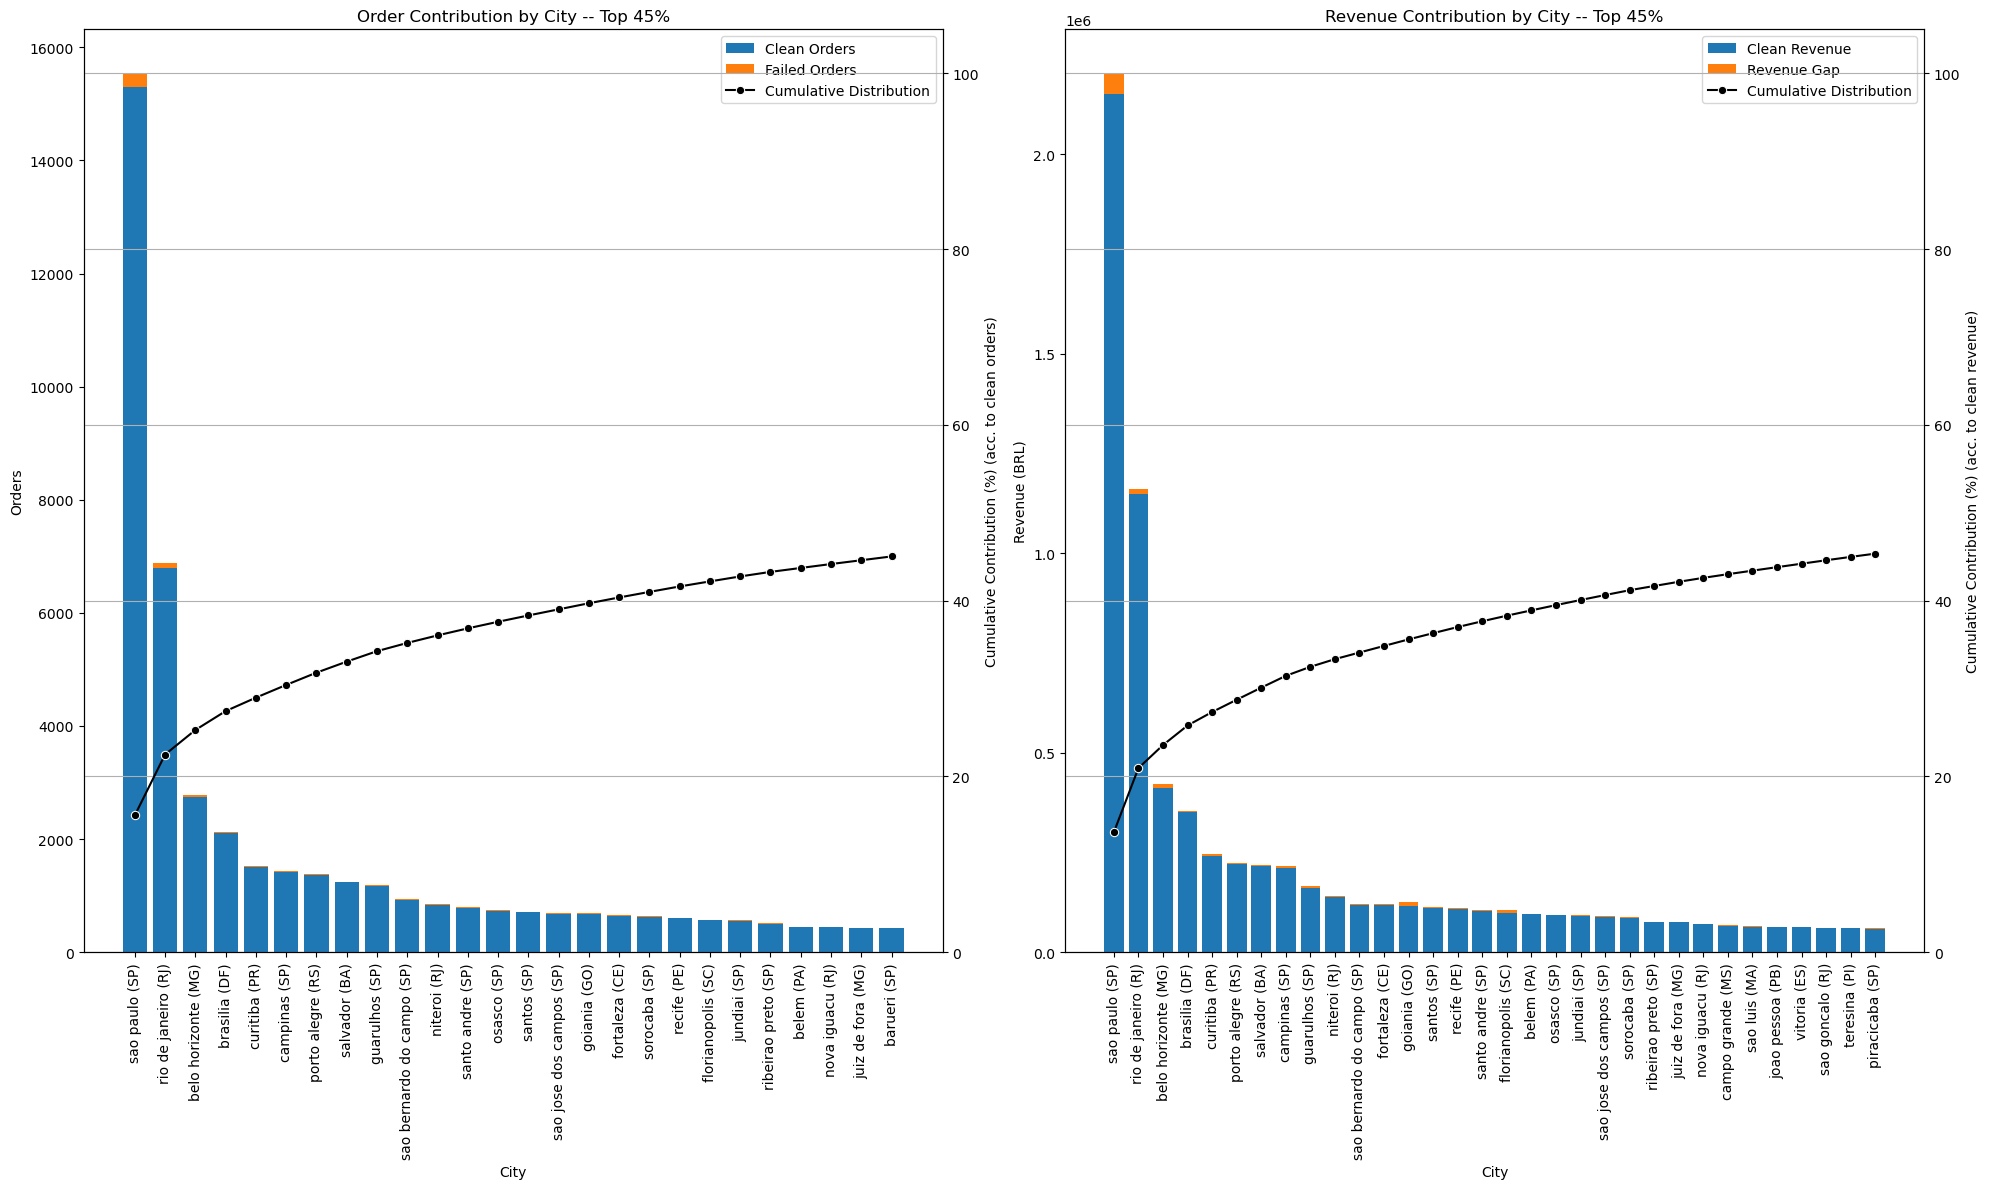

In [232]:
orders_plot = city_orders.head(26)
revenue_plot = city_revenue.head(32)

order_labels = (orders_plot["customer_city"] + " (" + orders_plot["customer_state"] + ")")
revenue_labels = (revenue_plot["customer_city"] + " (" + revenue_plot["customer_state"] + ")")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 12))
ax1.bar(order_labels, orders_plot["clean_orders"],label="Clean Orders")
ax1.bar(order_labels, orders_plot["failed_orders"], bottom=orders_plot["clean_orders"], label="Failed Orders")
ax1_twin = ax1.twinx()
sns.lineplot(x =order_labels, y=orders_plot["cumulative_dist"],marker="o", color="black", 
             label="Cumulative Distribution", ax=ax1_twin, legend = False)
ax1.set_title("Order Contribution by City -- Top 45%")
ax1.set_xlabel("City")
ax1.set_ylabel("Orders")
ax1_twin.set_ylabel("Cumulative Contribution (%) (acc. to clean orders)")
ax1_twin.set_ylim(0, 105)
ax1.tick_params(axis="x", rotation=90)
ax1_twin.grid(axis="y")

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax1_twin.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc="upper right")

ax2.bar(revenue_labels, revenue_plot["clean_revenue"], label="Clean Revenue")
ax2.bar(revenue_labels, revenue_plot["revenue_gap"], bottom=revenue_plot["clean_revenue"], label="Revenue Gap")
ax2_twin = ax2.twinx()
sns.lineplot(x = revenue_labels, y=revenue_plot["cumulative_dist"], marker="o", color="black", 
             label="Cumulative Distribution", ax=ax2_twin, legend = False)
ax2.set_title("Revenue Contribution by City -- Top 45%")
ax2.set_xlabel("City")
ax2.set_ylabel("Revenue (BRL)")
ax2_twin.set_ylabel("Cumulative Contribution (%) (acc. to clean revenue)")
ax2_twin.set_ylim(0, 105)
ax2.tick_params(axis="x", rotation=90)
ax2_twin.grid(axis="y")

h1, l1 = ax2.get_legend_handles_labels()
h2, l2 = ax2_twin.get_legend_handles_labels()
ax2.legend(h1+h2, l1+l2, loc="upper right")

plt.tight_layout()
plt.show()

City order differs between the two charts since each is independently sorted by its own metric — a city's bar position in Orders won't match its position in Revenue

São Paulo city alone drives 15.57% of clean orders but only 13.66% of clean revenue — consistent with the earlier state-level finding that SP has the lowest AOV of any state; volume leads value here.

Barueri (SP) is the one city that appears in the Order chart's top 26 but drops out of the Revenue chart's top 32 — high order volume, but low enough AOV that its revenue contribution doesn't rank as highly.   
Conversely, several cities appear only in the Revenue chart (Campo Grande, São Luís, João Pessoa, Vitória, Teresina, São Gonçalo, Piracicaba) — lower order volume but higher-value orders on average, so they clear the revenue threshold without cracking the order-volume top 26.   
This mirrors the state-level pattern where high-volume regions tend to have lower AOV, and lower-volume regions tend to have higher AOV.

In [277]:
# Check in which city, those 3 canceled rows with paymnet value = 0 resides
query = """SELECT DISTINCT p.order_id, customer_state, customer_city, order_status, payment_type, payment_value
FROM olist_order_payments_dataset p
JOIN olist_orders_dataset o ON p.order_id = o.order_id
JOIN olist_customers_dataset c ON o.customer_id = c.customer_id
WHERE p.payment_value = 0
AND p.payment_type = 'not_defined'
ORDER BY customer_state, customer_city, order_id"""
zero_payment_not_defined = pd.read_sql(query, engine)
zero_payment_not_defined

,order_id,customer_state,customer_city,order_status,payment_type,payment_value
0,00b1cb0320190ca0daa2c88b35206009,SP,sao paulo,canceled,not_defined,0.0
1,4637ca194b6387e2d538dc89b124b0ee,SP,sao paulo,canceled,not_defined,0.0
2,c8c528189310eaa44a745b8d9d26908b,SP,sao paulo,canceled,not_defined,0.0


All 3 canceled orders with payment_type = 'not_defined' and payment_value = 0 are located in São Paulo (SP) city specifically.   
Given São Paulo's dominant order volume at the city level (largest single city in the dataset), 3 isolated placeholder/missing-payment rows landing there is proportionally negligible - consistent with data-entry artifacts rather than any city-specific pattern

In [234]:
query = """WITH seq_issues AS (
SELECT order_id, payment_sequential,
ROW_NUMBER() OVER (PARTITION BY order_id ORDER BY payment_sequential) AS expected_seq
FROM olist_order_payments_dataset),
bad_orders AS (
SELECT DISTINCT order_id
FROM seq_issues
WHERE payment_sequential != expected_seq),
affected_cities AS (
SELECT customer_city, customer_state, COUNT(DISTINCT b.order_id) AS affected_orders,
COALESCE(SUM(payment_value),0) AS affected_gross_value,
COALESCE(SUM(payment_value) FILTER (WHERE order_status NOT IN ('unavailable','canceled')),0) AS affected_clean_value,
COALESCE(SUM(payment_value) FILTER (WHERE order_status IN ('unavailable','canceled')),0) AS affected_failed_value
FROM bad_orders b
JOIN olist_orders_dataset o ON b.order_id = o.order_id
JOIN olist_order_payments_dataset p ON b.order_id = p.order_id
JOIN olist_customers_dataset c ON o.customer_id = c.customer_id
GROUP BY c.customer_city, c.customer_state),
city_totals AS (
SELECT customer_city, customer_state,
COALESCE(SUM(p.payment_value),0) AS gross_revenue,
COALESCE(SUM(p.payment_value) FILTER (WHERE o.order_status NOT IN ('unavailable','canceled')),0) AS clean_revenue,
COALESCE(SUM(p.payment_value) FILTER (WHERE o.order_status IN ('unavailable','canceled')),0) AS failed_revenue
FROM olist_orders_dataset o
JOIN olist_order_payments_dataset p ON o.order_id = p.order_id
JOIN olist_customers_dataset c ON o.customer_id = c.customer_id
GROUP BY c.customer_city, c.customer_state)
SELECT a.customer_city, a.customer_state, a.affected_orders,
a.affected_gross_value,
t.gross_revenue,
ROUND(COALESCE(100.0 * a.affected_gross_value / NULLIF(t.gross_revenue,0),0)::NUMERIC, 3) AS gross_impact_pct,
a.affected_clean_value,
t.clean_revenue,
ROUND(COALESCE(100.0 * a.affected_clean_value / NULLIF(t.clean_revenue,0),0)::NUMERIC, 3) AS clean_impact_pct,
a.affected_failed_value,
t.failed_revenue,
ROUND(COALESCE(100.0 * a.affected_failed_value / NULLIF(t.failed_revenue,0),0)::NUMERIC, 3) AS failed_impact_pct
FROM affected_cities a
JOIN city_totals t
ON a.customer_city = t.customer_city
AND a.customer_state = t.customer_state
ORDER BY gross_impact_pct DESC"""
sequential_issue_summary= pd.read_sql(query, engine)
sequential_issue_summary

,customer_city,customer_state,affected_orders,affected_gross_value,gross_revenue,gross_impact_pct,affected_clean_value,clean_revenue,clean_impact_pct,affected_failed_value,failed_revenue,failed_impact_pct
0,sucesso,CE,1,252.74,485.92,52.013,252.74,485.92,52.013,0.00,0.00,0.000
1,cocal,PI,1,261.97,1413.88,18.528,261.97,1413.88,18.528,0.00,0.00,0.000
2,capanema,PA,1,152.82,831.86,18.371,152.82,746.26,20.478,0.00,85.60,0.000
3,carpina,PE,1,437.26,2600.23,16.816,437.26,2600.23,16.816,0.00,0.00,0.000
4,caxias,MA,1,329.39,2604.15,12.649,329.39,2604.15,12.649,0.00,0.00,0.000
5,mambore,PR,1,107.78,928.47,11.608,107.78,928.47,11.608,0.00,0.00,0.000
6,ibate,SP,1,152.41,1944.12,7.840,152.41,1944.12,7.840,0.00,0.00,0.000
7,guapimirim,RJ,1,224.71,3644.91,6.165,224.71,3568.89,6.296,0.00,76.02,0.000
8,sao francisco do sul,SC,1,119.54,2012.77,5.939,119.54,2012.77,5.939,0.00,0.00,0.000
9,belo jardim,PE,1,107.21,2157.69,4.969,107.21,2157.69,4.969,0.00,0.00,0.000


Same sequential-issue check as the state-level version, now at city grain.   
Small cities with 1-2 affected orders show inflated %s (Sucesso 52%, Cocal 18.5%) — pure small-denominator noise, not a real issue.   
High-volume cities (São Paulo, Rio, Belo Horizonte) show the true picture: 6, 6, and 2 affected orders but only 0.03-0.13% impact — consistent with the ~0.06-0.08% dataset-wide finding.   
Diadema (SP) is the one exception — its affected order falls under failed_impact_pct (23.8%) instead of clean, same small-denominator pattern on the failed side.

In [235]:
# Monthly/State/City AOV is calculated at the order level by first summing
# payment_value for each order and then averaging across orders.

# Excludes payment_value = 0 rows:
# - 3 rows belong to canceled orders with payment_type = 'not_defined' (no actual payment).
# - The remaining zero-value rows occur alongside positive payments for the same order,
#   so removing them does not change the final order value.

# 80 orders with payment sequence issues were reviewed separately.
# Since they contribute only a negligible share of overall revenue, they are
# retained in the analysis and documented as a data quality limitation.

# Orders with no payment records (1 delivered order) are naturally excluded by the INNER JOIN.

In [236]:
query = """WITH order_totals AS (
SELECT o.order_id, order_status, customer_city, customer_state,
SUM(p.payment_value) AS order_value
FROM olist_orders_dataset o
JOIN olist_order_payments_dataset p ON o.order_id = p.order_id
JOIN olist_customers_dataset c ON o.customer_id = c.customer_id
WHERE p.payment_value > 0
GROUP BY o.order_id, order_status, customer_city, customer_state)
SELECT customer_city, customer_state,
COALESCE(SUM(order_value) / NULLIF(COUNT(*),0),0) AS gross_aov,
COALESCE(SUM(order_value) FILTER (WHERE order_status NOT IN ('unavailable','canceled')) 
/ NULLIF(COUNT(*) FILTER (WHERE order_status NOT IN ('unavailable','canceled')),0),0) AS clean_aov,
COALESCE(SUM(order_value) FILTER (WHERE order_status IN ('unavailable','canceled')) 
/ NULLIF(COUNT(*) FILTER (WHERE order_status IN ('unavailable','canceled')),0),0) AS failed_aov
FROM order_totals
GROUP BY customer_city, customer_state
ORDER BY clean_aov DESC;"""
city_aov = pd.read_sql(query, engine)
city_aov

,customer_city,customer_state,gross_aov,clean_aov,failed_aov
0,pianco,PB,2324.99,2324.99,0.00
1,sao sebastiao,AL,2269.98,2269.98,0.00
2,nova esperanca do piria,PA,2252.66,2252.66,0.00
3,engenheiro navarro,MG,2106.55,2106.55,0.00
4,agrestina,PE,2066.34,2066.34,0.00
...,...,...,...,...,...
4305,pirapemas,MA,124.73,0.00,124.73
4306,doutor mauricio cardoso,RS,116.94,0.00,116.94
4307,lidice,RJ,144.31,0.00,144.31
4308,lagoa santa,GO,157.94,0.00,157.94


City-level AOV, freight, seller concentration, items/order, and price-mix breakdowns are not visually compared against each other the way they were at state grain.   
With 27 states, each metric could be plotted, sorted, and cross-referenced by name (e.g. "AL has low AOV but high late delivery"). With 4,310 cities, that visual cross-referencing isn't possible — no chart can meaningfully display or compare that many labeled points, and most cities have too few orders for a stable per-metric estimate anyway.   
City-level analysis is therefore limited to Pareto/top-N threshold views (top cities by revenue, orders, AOV) rather than the full cross-metric investigation done at state level.

In [237]:
# City order count threshold analysis
# Order count is a discrete variable, so percentile_disc is used to get an actual observed order-count cutoff.
# Cities below this threshold are excluded from visualization to avoid overcrowded charts.

query = """WITH city_orders AS (
SELECT customer_city, customer_state,
COUNT(*) FILTER (WHERE o.order_status NOT IN ('canceled','unavailable')) AS clean_orders
FROM olist_orders_dataset o
JOIN olist_customers_dataset c 
ON o.customer_id = c.customer_id
GROUP BY customer_city, customer_state)
SELECT MIN(clean_orders) AS min_orders,
PERCENTILE_DISC(0.25) WITHIN GROUP (ORDER BY clean_orders) AS p25_orders,
PERCENTILE_DISC(0.50) WITHIN GROUP (ORDER BY clean_orders) AS median_orders,
PERCENTILE_DISC(0.75) WITHIN GROUP (ORDER BY clean_orders) AS p75_orders,
MAX(clean_orders) AS max_orders
FROM city_orders;"""
city_order_thresholds = pd.read_sql(query, engine)
city_order_thresholds

,min_orders,p25_orders,median_orders,p75_orders,max_orders
0,0,1,3,8,15291


In [238]:
percentiles = np.arange(0.75, 0.995, 0.05)

for p in percentiles:
    query = f"""WITH city_orders AS (
    SELECT customer_city, customer_state,
    COUNT(*) FILTER (WHERE o.order_status NOT IN ('canceled','unavailable')) AS clean_orders
    FROM olist_orders_dataset o
    JOIN olist_customers_dataset c ON o.customer_id = c.customer_id
    GROUP BY customer_city, customer_state),
    threshold AS (
    SELECT {p*100} AS percentile,
    PERCENTILE_DISC({p}) WITHIN GROUP (ORDER BY clean_orders) AS order_threshold
    FROM city_orders)
    SELECT *,
    (SELECT COUNT(*) FROM city_orders WHERE clean_orders >= t.order_threshold)
    FROM threshold t"""
    threshold_result = pd.read_sql(query, engine)
    display(threshold_result)

,percentile,order_threshold,count
0,75.0,8,1131


,percentile,order_threshold,count
0,80.0,11,867


,percentile,order_threshold,count
0,85.0,15,675


,percentile,order_threshold,count
0,90.0,27,441


,percentile,order_threshold,count
0,95.0,63,220


In [239]:
percentiles = np.arange(0.95, 1, 0.01)

for p in percentiles:
    query = f"""WITH city_orders AS (
    SELECT customer_city, customer_state,
    COUNT(*) FILTER (WHERE o.order_status NOT IN ('canceled','unavailable')) AS clean_orders
    FROM olist_orders_dataset o
    JOIN olist_customers_dataset c ON o.customer_id = c.customer_id
    GROUP BY customer_city, customer_state),
    threshold AS (
    SELECT {p*100} AS percentile,
    PERCENTILE_DISC({p}) WITHIN GROUP (ORDER BY clean_orders) AS order_threshold
    FROM city_orders)
    SELECT *,
    (SELECT COUNT(*) FROM city_orders WHERE clean_orders >= t.order_threshold) AS cities_remaining
    FROM threshold t"""
    
    threshold_result = pd.read_sql(query, engine)
    display(threshold_result)

,percentile,order_threshold,cities_remaining
0,95.0,63,220


,percentile,order_threshold,cities_remaining
0,96.0,80,173


,percentile,order_threshold,cities_remaining
0,97.0,107,130


,percentile,order_threshold,cities_remaining
0,98.0,160,87


,percentile,order_threshold,cities_remaining
0,99.0,278,44


,percentile,order_threshold,cities_remaining
0,100.0,15291,1


Threshold is based on clean_orders count, not AOV — this filters out low-volume cities first. Only after that filter is applied does sorting the remaining cities by clean_aov become meaningful, since each qualifying city now has enough orders for its average to be stable.

In [ ]:
# Average Order Value by City (99th percentile order-count threshold)
# Only city-state pairs with at least 278 clean orders are retained for visualization
# to avoid overcrowding while preserving the highest-volume markets.

query = """WITH city_orders AS (
SELECT customer_city, customer_state,
COUNT(*) FILTER (WHERE o.order_status NOT IN ('canceled','unavailable')) AS clean_orders
FROM olist_orders_dataset o
JOIN olist_customers_dataset c
ON o.customer_id = c.customer_id
GROUP BY customer_city, customer_state),
order_totals AS (
SELECT o.order_id,
order_status,
customer_city,
customer_state,
SUM(payment_value) AS order_value
FROM olist_orders_dataset o
JOIN olist_order_payments_dataset p
ON o.order_id = p.order_id
JOIN olist_customers_dataset c
ON o.customer_id = c.customer_id
WHERE payment_value > 0
GROUP BY o.order_id, order_status, customer_city, customer_state)
SELECT ot.customer_city,
ot.customer_state,
clean_orders,
COALESCE(SUM(order_value) / NULLIF(COUNT(*),0),0) AS gross_aov,
COALESCE(SUM(order_value) FILTER (WHERE order_status NOT IN ('unavailable','canceled'))
/ NULLIF(COUNT(*) FILTER (WHERE order_status NOT IN ('unavailable','canceled')),0),0) AS clean_aov,
COALESCE(SUM(order_value) FILTER (WHERE order_status IN ('unavailable','canceled'))
/ NULLIF(COUNT(*) FILTER (WHERE order_status IN ('unavailable','canceled')),0),0) AS failed_aov
FROM order_totals ot
JOIN city_orders co
ON ot.customer_city = co.customer_city
AND ot.customer_state = co.customer_state
GROUP BY ot.customer_city, ot.customer_state, co.clean_orders 
ORDER BY clean_orders DESC"""
city_aov = pd.read_sql(query, engine)
city_aov

60% cumulative threshold selected for city-level seller concentration — reached at 44 cities, which conveniently matches the city count already used for the AOV and late-delivery charts, allowing direct visual comparison across all three.    
Notably, sellers concentrate faster than orders or revenue did at city grain (50% of all sellers come from just 21 cities) — seller presence is even more geographically concentrated than buying activity.

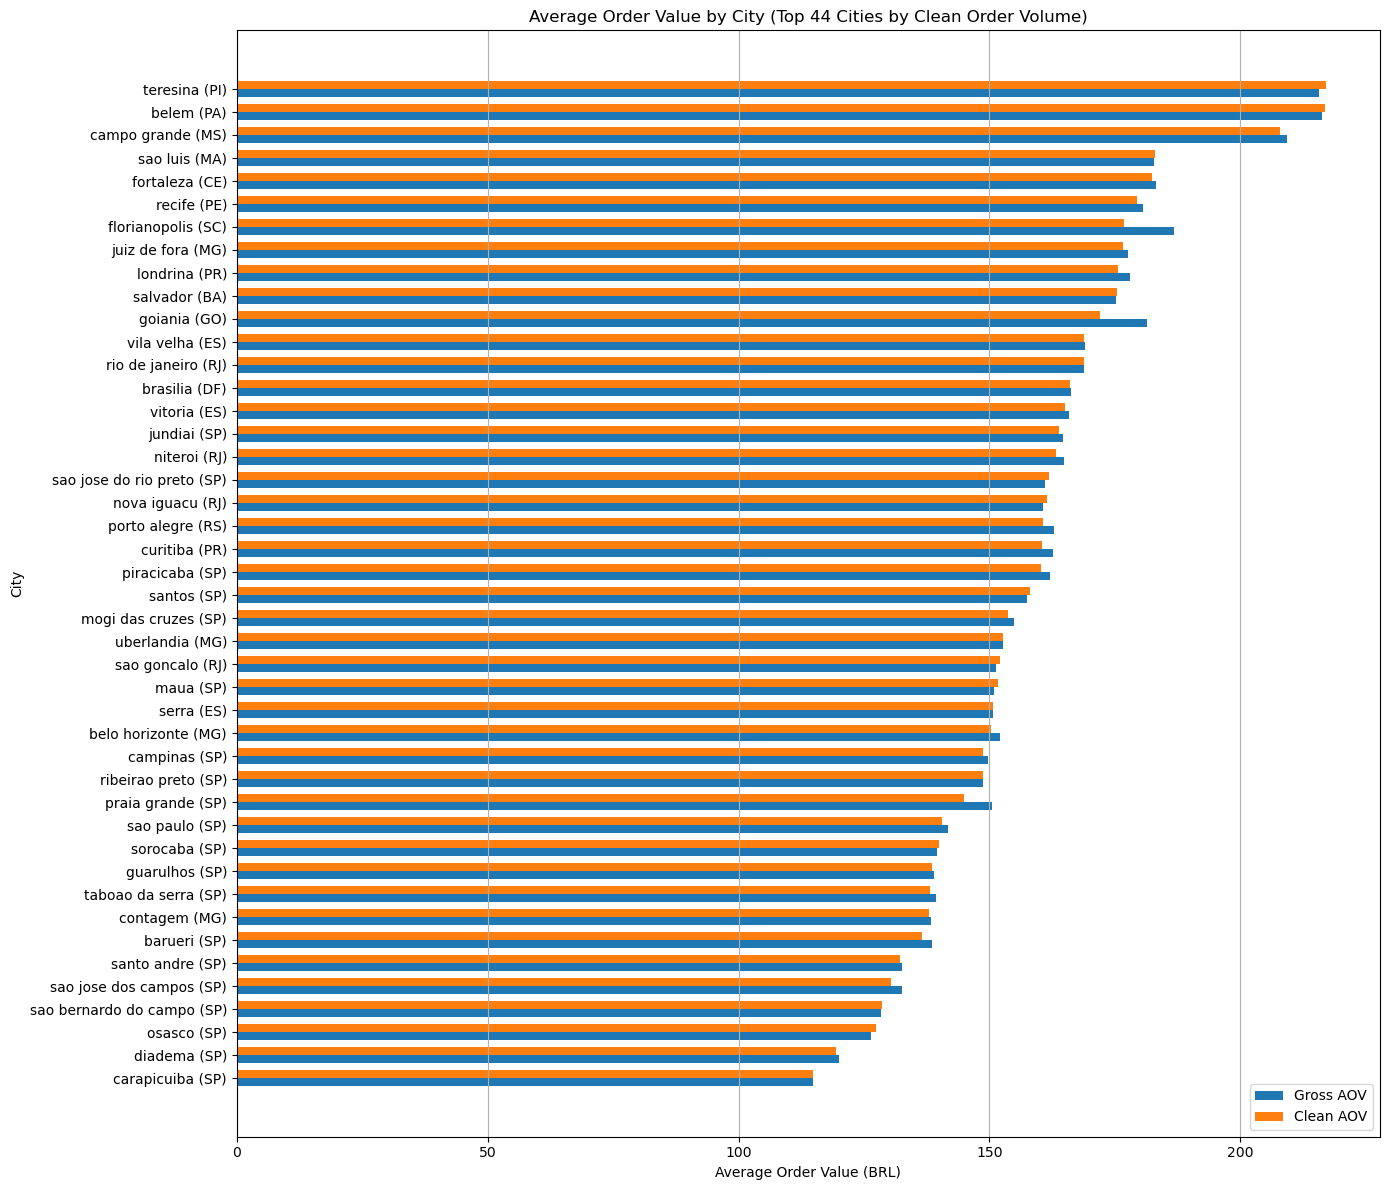

In [241]:
# Top 44 cities by order volume, displayed by Clean AOV

plot_df = city_aov.head(44).copy()
plot_df = plot_df.sort_values("clean_aov", ascending = True)

plot_df["city_state"] = plot_df["customer_city"] + " (" + plot_df["customer_state"] + ")"

plt.figure(figsize=(14, 12))

y = np.arange(len(plot_df))
h = 0.35
plt.barh(y - (h/2), plot_df["gross_aov"], height=h, label="Gross AOV")
plt.barh(y + (h/2), plot_df["clean_aov"], height=h, label="Clean AOV")
plt.yticks(y, plot_df["city_state"])
plt.xlabel("Average Order Value (BRL)")
plt.ylabel("City")
plt.title("Average Order Value by City (Top 44 Cities by Clean Order Volume)")
plt.legend(loc="lower right")
plt.grid(axis="x")
plt.tight_layout()
plt.show()

The 99th percentile of clean_orders per city was used as the minimum-order threshold (278 orders), leaving 44 qualifying cities — small enough to plot and read individually, while still representing the highest-volume, most statistically stable cities in the dataset. 
This excludes the long tail of low-order cities where AOV would be unstable/noisy (as seen in the earlier unfiltered city_aov table).

Comparing the AOV chart against the Order/Revenue contribution charts reveals a clear inverse relationship: São Paulo and its metro cities (Guarulhos, Osasco, Santo André, São Bernardo do Campo, Sorocaba, São José dos Campos) dominate order volume and revenue contribution but sit at the bottom of the AOV ranking.    
Conversely, the highest-AOV cities (Teresina, Belém, Campo Grande) don't appear in the top order/revenue contributors — high value per order, but far lower volume.     
Rio de Janeiro and Belo Horizonte are the exception, ranking strongly on both volume/revenue and AOV — the more balanced high-performing cities in the dataset.       
This mirrors the state-level volume-vs-AOV pattern found earlier, confirming it isn't just a São Paulo-state effect but is concentrated specifically in the São Paulo metro area.

In [286]:
# Late Delivery Rate by City

# Calculates the percentage of delivered orders that arrived after the estimated delivery date.
# Previously verified: among 96,478 delivered orders, only 8 have missing delivered dates
# and none have missing estimated delivery dates.

query = """WITH city_orders AS (
SELECT customer_city, customer_state,
COUNT(*) FILTER (WHERE o.order_status NOT IN ('canceled','unavailable')) AS clean_orders
FROM olist_orders_dataset o
JOIN olist_customers_dataset c
ON o.customer_id = c.customer_id
GROUP BY customer_city, customer_state),
city_delivery AS (
SELECT customer_city, customer_state,
COUNT(*) AS total_delivered_orders,
COUNT(*) FILTER (WHERE o.order_delivered_customer_date IS NOT NULL
AND o.order_delivered_customer_date > o.order_estimated_delivery_date) AS late_orders
FROM olist_orders_dataset o
JOIN olist_customers_dataset c
ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered'
GROUP BY customer_city, customer_state)
SELECT cd.customer_city,
cd.customer_state,
co.clean_orders,
cd.total_delivered_orders,
cd.late_orders,
ROUND(100.0 * cd.late_orders / cd.total_delivered_orders, 2) AS late_delivery_rate
FROM city_delivery cd
JOIN city_orders co
ON cd.customer_city = co.customer_city
AND cd.customer_state = co.customer_state
ORDER BY clean_orders DESC"""
late_delivery_city = pd.read_sql(query, engine)
late_delivery_city

,customer_city,customer_state,clean_orders,total_delivered_orders,late_orders,late_delivery_rate
0,sao paulo,SP,15291,15045,942,6.26
1,rio de janeiro,RJ,6801,6601,780,11.82
2,belo horizonte,MG,2737,2697,166,6.15
3,brasilia,DF,2112,2071,147,7.10
4,curitiba,PR,1502,1489,74,4.97
...,...,...,...,...,...,...
4267,piacatu,SP,1,1,0,0.00
4268,leopoldo de bulhoes,GO,1,1,0,0.00
4269,alto alegre,RS,1,1,0,0.00
4270,grupiara,MG,1,1,0,0.00


Rio de Janeiro stands out among the top cities — 11.82% late delivery rate, nearly double São Paulo's (6.26%) despite being the second-largest city by volume.   
This breaks from the expected "high volume = high reliability" pattern seen elsewhere (Belo Horizonte 6.15%, Curitiba 4.97%) — worth keeping in mind when the full 44-city chart is reviewed next.

In [287]:
# Seller Concentration by City

# Count unique sellers by city+state and calculate the cumulative seller contribution
# using a row-wise cumulative sum, same approach as the state-level seller concentration check.

query = """SELECT seller_city, seller_state, COUNT(*) AS seller_count,
100.0 * SUM(COUNT(*)) OVER (ORDER BY COUNT(*) DESC, seller_city, seller_state
ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW)
/ SUM(COUNT(*)) OVER () AS cumulative_dist
FROM olist_sellers_dataset
GROUP BY seller_city, seller_state
ORDER BY seller_count DESC"""
city_sellers = pd.read_sql(query, engine)
city_sellers

,seller_city,seller_state,seller_count,cumulative_dist
0,sao paulo,SP,694,22.423263
1,curitiba,PR,124,26.429725
2,rio de janeiro,RJ,93,29.434572
3,belo horizonte,MG,66,31.567044
4,ribeirao preto,SP,52,33.247173
...,...,...,...,...
631,vila velha,SP,1,99.870759
632,vitoria de santo antao,PE,1,99.903069
633,volta redonda,RJ,1,99.935380
634,volta redonda,SP,1,99.967690


In [288]:
# Seller Concentration Threshold Check (City Level)

thresholds = np.arange(0.50, 1.00, 0.05)

for t in thresholds:
    query = f"""WITH city_sellers AS (
    SELECT seller_city,
    seller_state,
    COUNT(*) AS seller_count
    FROM olist_sellers_dataset
    GROUP BY seller_city, seller_state),
    city_cume AS (
    SELECT seller_city,
    seller_state,
    seller_count,
    ROUND((100.0 * SUM(seller_count) OVER (
    ORDER BY seller_count DESC, seller_city, seller_state
    ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW)
    / SUM(seller_count) OVER ())::NUMERIC, 2) AS cumulative_seller_share
    FROM city_sellers),
    prev_cume AS (
    SELECT seller_city,
    seller_state,
    seller_count,
    cumulative_seller_share,
    LAG(cumulative_seller_share,1,0) OVER (
    ORDER BY seller_count DESC, seller_city, seller_state
    ) AS prev_cum_share
    FROM city_cume)
    SELECT {100*t} AS cumulative_threshold,
    COUNT(*) AS cities_required_to_exceed
    FROM prev_cume
    WHERE cumulative_seller_share < {100*t}
    OR prev_cum_share < {100*t};"""

    display(pd.read_sql(query, engine))

,cumulative_threshold,cities_required_to_exceed
0,50.0,21


,cumulative_threshold,cities_required_to_exceed
0,55.0,31


,cumulative_threshold,cities_required_to_exceed
0,60.0,44


,cumulative_threshold,cities_required_to_exceed
0,65.0,60


,cumulative_threshold,cities_required_to_exceed
0,70.0,81


,cumulative_threshold,cities_required_to_exceed
0,75.0,112


,cumulative_threshold,cities_required_to_exceed
0,80.0,155


,cumulative_threshold,cities_required_to_exceed
0,85.0,220


,cumulative_threshold,cities_required_to_exceed
0,90.0,327


,cumulative_threshold,cities_required_to_exceed
0,95.0,482


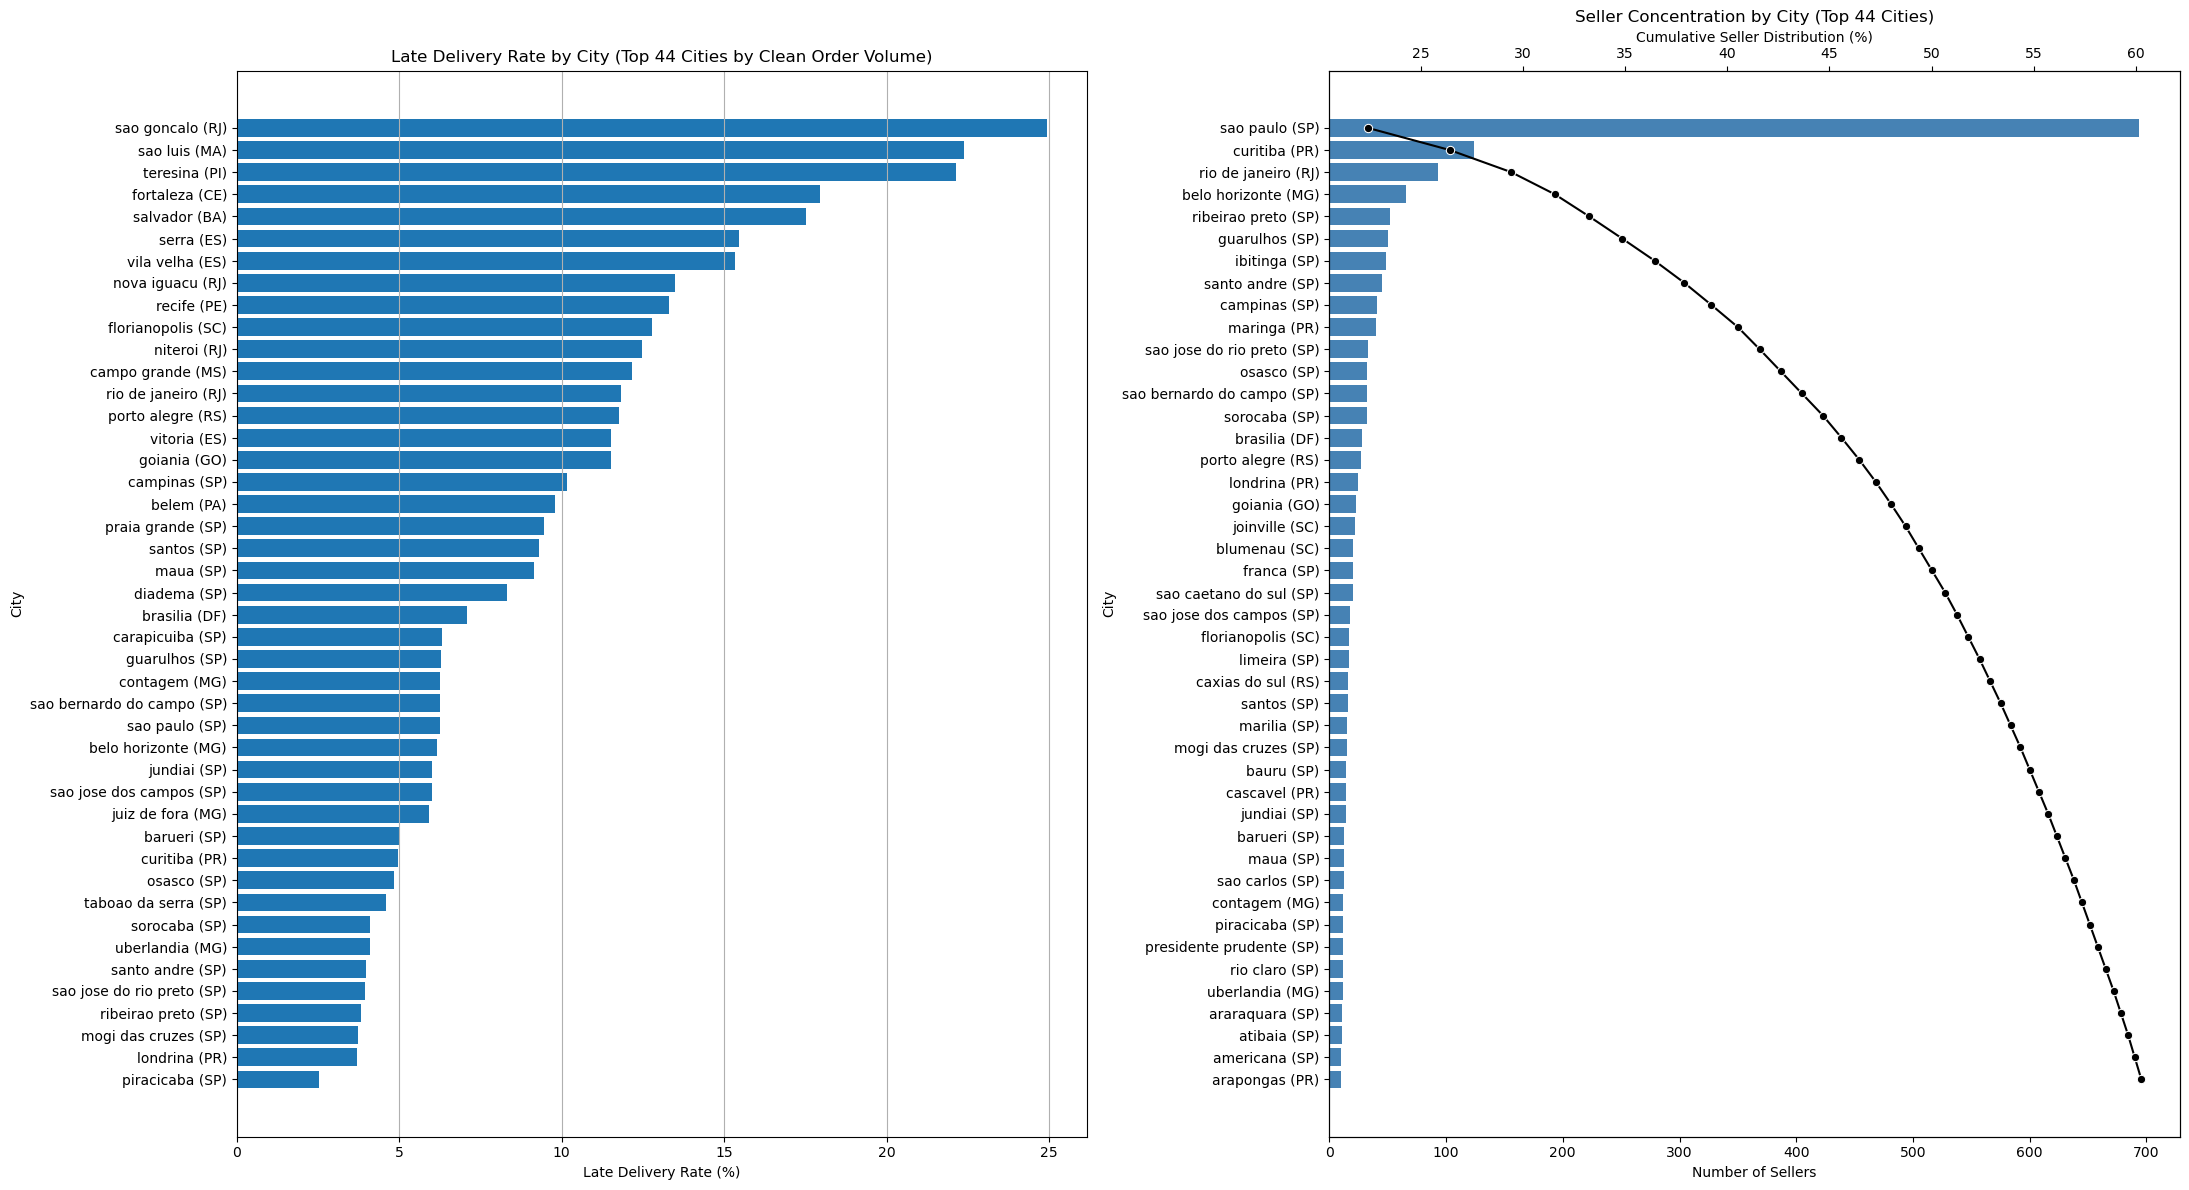

In [291]:
fig, axes = plt.subplots(1, 2, figsize=(22, 12))

plot_df = late_delivery_city.head(44).copy()
plot_df = plot_df.sort_values("late_delivery_rate", ascending=True)
plot_df["city_state"] = (plot_df["customer_city"] + " (" + plot_df["customer_state"] + ")")

axes[0].barh(plot_df["city_state"], plot_df["late_delivery_rate"])
axes[0].set_xlabel("Late Delivery Rate (%)")
axes[0].set_ylabel("City")
axes[0].set_title("Late Delivery Rate by City (Top 44 Cities by Clean Order Volume)")
axes[0].grid(axis="x")


plot_sellers = city_sellers.head(44).copy()
plot_sellers["city_state"] = plot_sellers["seller_city"] + " (" + plot_sellers["seller_state"] + ")"

axes[1].barh(plot_sellers["city_state"], plot_sellers["seller_count"], color="steelblue")
axes[1].set_xlabel("Number of Sellers")
axes[1].set_ylabel("City")
axes[1].set_title("Seller Concentration by City (Top 44 Cities)")

ax1_twin = axes[1].twiny()
sns.lineplot(data=plot_sellers, x="cumulative_dist", y="city_state",
             color="black", marker="o", ax=ax1_twin)
ax1_twin.set_xlabel("Cumulative Seller Distribution (%)")
ax1_twin.grid(False)

plt.tight_layout()
plt.show()

Cities with strong local seller presence tend toward better delivery reliability — Curitiba (2nd-highest seller count) has one of the lowest late rates (~5%). Cities absent from the seller list often show the worst rates instead — São Gonçalo (~25%, highest of all), São Luís (~22%), and Nova Iguaçu (~13%) don't appear among the top 44 seller cities.   
São Paulo is the volume outlier (~700 sellers, far ahead of any other city) but only mid-pack on reliability (~6% late), showing seller density alone doesn't guarantee the best performance — just better than average.  
Rio de Janeiro city is a partial exception worth noting: 3rd-highest seller count, yet still a relatively high 11.8% late rate. Its own satellite cities (Niterói, Nova Iguaçu, São Gonçalo — all RJ) fare far worse and have no local seller presence at all, showing that a major seller hub within the state doesn't fully protect nearby cities from delays — local, city-level seller presence matters more than statewide availability.

In [292]:
# Quadrant
query = """WITH city_delivery AS (
SELECT customer_city, customer_state,
COUNT(*) AS delivered_orders,
ROUND(100.0 * COUNT(*) FILTER (WHERE order_delivered_customer_date::TIMESTAMP > order_estimated_delivery_date::TIMESTAMP) / COUNT(*), 2) 
AS late_delivery_rate
FROM olist_orders_dataset o
JOIN olist_customers_dataset c ON o.customer_id = c.customer_id
WHERE order_status = 'delivered'
AND order_delivered_customer_date IS NOT NULL
AND order_delivered_customer_date::TIMESTAMP >= order_purchase_timestamp::TIMESTAMP
GROUP BY customer_city, customer_state),
city_aov AS (
SELECT customer_city, customer_state, COUNT(DISTINCT o.order_id) AS clean_orders,
ROUND(SUM(payment_value)::NUMERIC / COUNT(DISTINCT o.order_id), 2) AS clean_aov
FROM olist_orders_dataset o
JOIN olist_customers_dataset c ON o.customer_id = c.customer_id
JOIN olist_order_payments_dataset p ON o.order_id = p.order_id
WHERE o.order_status NOT IN ('canceled','unavailable')
GROUP BY c.customer_city, c.customer_state)
SELECT a.customer_city, a.customer_state, clean_orders, clean_aov, delivered_orders, late_delivery_rate
FROM city_aov a
JOIN city_delivery d ON a.customer_city = d.customer_city
AND a.customer_state = d.customer_state
ORDER BY a.clean_orders DESC;"""
city_aov_late = pd.read_sql(query, engine)
city_aov_late

,customer_city,customer_state,clean_orders,clean_aov,delivered_orders,late_delivery_rate
0,sao paulo,SP,15291,140.64,15045,6.26
1,rio de janeiro,RJ,6801,168.75,6601,11.82
2,belo horizonte,MG,2737,150.37,2697,6.15
3,brasilia,DF,2112,165.99,2071,7.10
4,curitiba,PR,1502,160.38,1489,4.97
...,...,...,...,...,...,...
4267,tururu,CE,1,215.60,1,100.00
4268,turvelandia,GO,1,42.40,1,0.00
4269,almirante tamandare do sul,RS,1,65.00,1,0.00
4270,ubai,MG,1,61.73,1,0.00


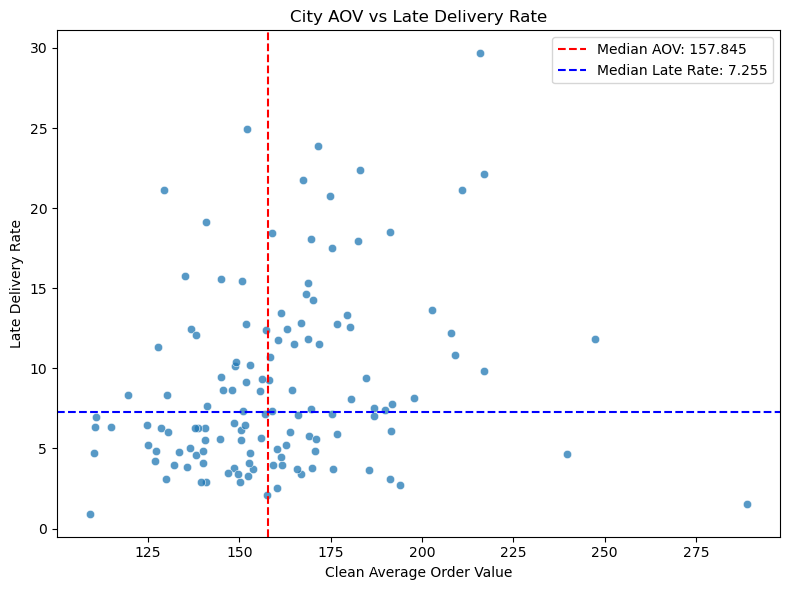

In [296]:
plot_df = city_aov_late.head(130)
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=plot_df, x="clean_aov", y="late_delivery_rate", ax=ax, alpha=0.75)

ax.axvline(plot_df["clean_aov"].median(), color="red", linestyle="--", linewidth=1.5, 
           label=f"Median AOV: {plot_df["clean_aov"].median()}")
ax.axhline(plot_df["late_delivery_rate"].median(), color="blue", linestyle="--", linewidth=1.5, 
           label=f"Median Late Rate: {plot_df["late_delivery_rate"].median()}")
ax.set_title("City AOV vs Late Delivery Rate")
ax.set_xlabel("Clean Average Order Value")
ax.set_ylabel("Late Delivery Rate")
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

### Section 4 Temporal Analysis

In [294]:
# Orders by day of week
query = """SELECT EXTRACT(DOW FROM order_purchase_timestamp::TIMESTAMP)::INT AS day_num,
TO_CHAR(order_purchase_timestamp::TIMESTAMP, 'fmDay') AS day_of_week,
COUNT(order_id) FILTER (WHERE order_status NOT IN ('canceled', 'unavailable')) AS clean_orders,
COUNT(order_id) FILTER (WHERE order_status IN ('canceled', 'unavailable')) AS failed_orders
FROM olist_orders_dataset
GROUP BY day_num, day_of_week
ORDER BY day_num"""
day_orders = pd.read_sql(query, engine)
day_orders

,day_num,day_of_week,clean_orders,failed_orders
0,0,Sunday,11831,129
1,1,Monday,15979,217
2,2,Tuesday,15760,203
3,3,Wednesday,15353,199
4,4,Thursday,14571,190
5,5,Friday,13949,173
6,6,Saturday,10764,123


Order volume is lowest on Sunday and jumps sharply on Monday — a clear weekend dip rather than a gradual weekly build-up; Tuesday–Saturday stay fairly flat by comparison.

In [299]:
# Orders by Purchase Time (Hour)
query = """WITH base AS (
SELECT order_id, order_status,
CASE
WHEN EXTRACT(HOUR FROM order_purchase_timestamp::TIMESTAMP) BETWEEN 0 AND 3 THEN 1
WHEN EXTRACT(HOUR FROM order_purchase_timestamp::TIMESTAMP) BETWEEN 4 AND 7 THEN 2
WHEN EXTRACT(HOUR FROM order_purchase_timestamp::TIMESTAMP) BETWEEN 8 AND 11 THEN 3
WHEN EXTRACT(HOUR FROM order_purchase_timestamp::TIMESTAMP) BETWEEN 12 AND 15 THEN 4
WHEN EXTRACT(HOUR FROM order_purchase_timestamp::TIMESTAMP) BETWEEN 16 AND 19 THEN 5
ELSE 6
END AS bucket_order,
CASE
WHEN EXTRACT(HOUR FROM order_purchase_timestamp::TIMESTAMP) BETWEEN 0 AND 3 THEN '00:00-03:59 Late Night'
WHEN EXTRACT(HOUR FROM order_purchase_timestamp::TIMESTAMP) BETWEEN 4 AND 7 THEN '04:00-07:59 Early Morning'
WHEN EXTRACT(HOUR FROM order_purchase_timestamp::TIMESTAMP) BETWEEN 8 AND 11 THEN '08:00-11:59 Mid-Morning'
WHEN EXTRACT(HOUR FROM order_purchase_timestamp::TIMESTAMP) BETWEEN 12 AND 15 THEN '12:00-15:59 Afternoon'
WHEN EXTRACT(HOUR FROM order_purchase_timestamp::TIMESTAMP) BETWEEN 16 AND 19 THEN '16:00-19:59 Evening'
ELSE '20:00-23:59 Night'
END AS time_bucket
FROM olist_orders_dataset )
SELECT time_bucket, 
COUNT(order_id) FILTER (WHERE order_status NOT IN ('canceled', 'unavailable')) AS clean_orders,
COUNT(order_id) FILTER (WHERE order_status IN ('canceled', 'unavailable')) AS failed_orders
FROM base
GROUP BY bucket_order, time_bucket
ORDER BY bucket_order"""
hour_orders = pd.read_sql(query, engine)
hour_orders

,time_bucket,clean_orders,failed_orders
0,00:00-03:59 Late Night,4286,60
1,04:00-07:59 Early Morning,2101,26
2,08:00-11:59 Mid-Morning,20232,275
3,12:00-15:59 Afternoon,25210,326
4,16:00-19:59 Evening,24274,302
5,20:00-23:59 Night,22104,245


 By time of day, Afternoon and Evening (12:00–19:59) together account for the bulk of daily orders, while Late Night (00:00–03:59) is the quietest window, as expected.

In [300]:
# Late Delivery Rate by Month
query = """WITH monthly_delivery AS (
SELECT
DATE_TRUNC('month', order_purchase_timestamp::TIMESTAMP) AS purchase_month,
TO_CHAR(order_purchase_timestamp::TIMESTAMP, 'Mon YYYY') AS month_year,
COUNT(order_id) AS delivered_orders,
COUNT(order_id) FILTER (WHERE order_delivered_customer_date IS NOT NULL
AND order_delivered_customer_date > order_estimated_delivery_date) AS late_orders
FROM olist_orders_dataset
WHERE order_status = 'delivered'
GROUP BY purchase_month, month_year)
SELECT month_year, delivered_orders, late_orders,
ROUND(100.0 * late_orders / NULLIF(delivered_orders,0), 2) AS late_delivery_rate
FROM monthly_delivery
ORDER BY purchase_month"""
late_delivery_month = pd.read_sql(query, engine)
late_delivery_month

,month_year,delivered_orders,late_orders,late_delivery_rate
0,Sep 2016,1,1,100.00
1,Oct 2016,265,3,1.13
2,Dec 2016,1,0,0.00
3,Jan 2017,750,23,3.07
4,Feb 2017,1653,53,3.21
5,Mar 2017,2546,142,5.58
6,Apr 2017,2303,181,7.86
7,May 2017,3546,128,3.61
8,Jun 2017,3135,121,3.86
9,Jul 2017,3872,133,3.43


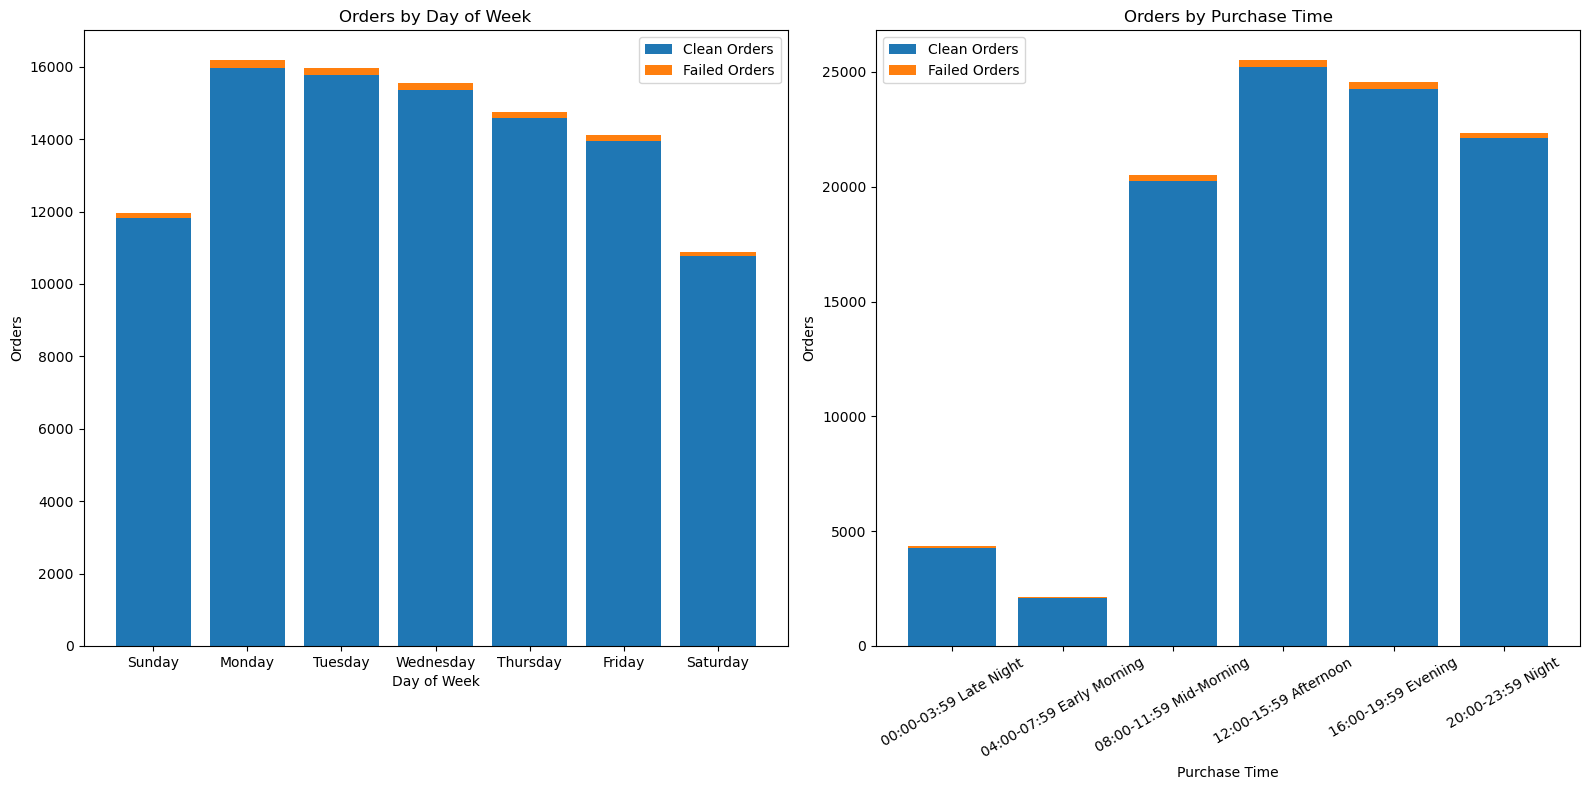

In [248]:
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

ax[0].bar(day_orders["day_of_week"], day_orders["clean_orders"], label="Clean Orders")
ax[0].bar(day_orders["day_of_week"], day_orders["failed_orders"],
          bottom=day_orders["clean_orders"], label="Failed Orders")
ax[0].set_xlabel("Day of Week")
ax[0].set_ylabel("Orders")
ax[0].set_title("Orders by Day of Week")
ax[0].legend()


ax[1].bar(hour_orders["time_bucket"], hour_orders["clean_orders"], label="Clean Orders")
ax[1].bar(hour_orders["time_bucket"], hour_orders["failed_orders"],
          bottom=hour_orders["clean_orders"], label="Failed Orders")
ax[1].set_xlabel("Purchase Time")
ax[1].set_ylabel("Orders")
ax[1].set_title("Orders by Purchase Time")
ax[1].tick_params(axis="x", rotation=30)
ax[1].legend()

plt.tight_layout()
plt.show()

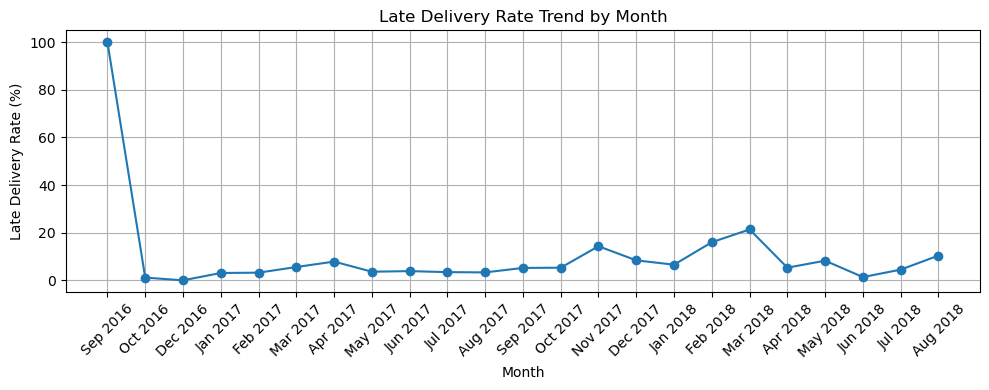

In [301]:
plt.figure(figsize=(10,4))
plt.plot(late_delivery_month["month_year"], late_delivery_month["late_delivery_rate"], marker="o")
plt.xlabel("Month")
plt.ylabel("Late Delivery Rate (%)")
plt.title("Late Delivery Rate Trend by Month")
plt.xticks(rotation = 45)
plt.grid()
plt.tight_layout()
plt.show()

In [251]:
# First Recorded Customers by Month (Dataset Scope)

query = """WITH customer_first_purchase AS (
SELECT customer_unique_id, order_purchase_timestamp::TIMESTAMP AS purchase_timestamp,
ROW_NUMBER() OVER(PARTITION BY customer_unique_id ORDER BY order_purchase_timestamp::TIMESTAMP) AS rn
FROM olist_orders_dataset o
JOIN olist_customers_dataset c ON o.customer_id = c.customer_id)
SELECT DATE_TRUNC('month', purchase_timestamp) AS purchase_month,
TO_CHAR(purchase_timestamp, 'Mon YYYY') AS month_year,
COUNT(customer_unique_id) AS first_recorded_customers
FROM customer_first_purchase
WHERE rn = 1
GROUP BY purchase_month, month_year
ORDER BY purchase_month"""

first_recorded_customers_month = pd.read_sql(query, engine)
first_recorded_customers_month

,purchase_month,month_year,first_recorded_customers
0,2016-09-01,Sep 2016,4
1,2016-10-01,Oct 2016,321
2,2016-12-01,Dec 2016,1
3,2017-01-01,Jan 2017,764
4,2017-02-01,Feb 2017,1752
5,2017-03-01,Mar 2017,2636
6,2017-04-01,Apr 2017,2352
7,2017-05-01,May 2017,3596
8,2017-06-01,Jun 2017,3139
9,2017-07-01,Jul 2017,3894


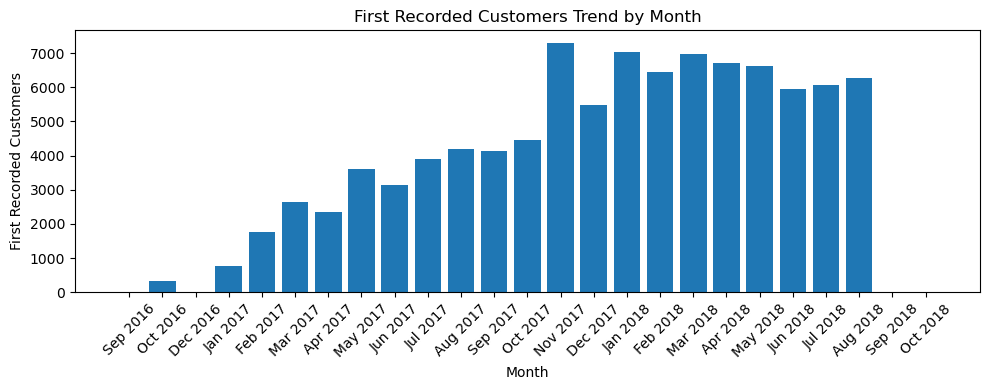

In [252]:
plt.figure(figsize=(10,4))
plt.bar(first_recorded_customers_month["month_year"], first_recorded_customers_month["first_recorded_customers"])
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("First Recorded Customers")
plt.title("First Recorded Customers Trend by Month")
plt.tight_layout()
plt.show()

### Section 5 Payment Analysis

In [255]:
# Payment Type Summary
query = """
WITH payment_summary AS (
SELECT payment_type, 
COUNT(DISTINCT order_id) AS total_orders,
SUM(payment_value) AS total_payment_value
FROM olist_order_payments_dataset
GROUP BY payment_type)
SELECT payment_type, total_orders,
ROUND(total_payment_value::NUMERIC,2) AS total_payment_value,
ROUND(100.0 * total_orders / SUM(total_orders) OVER(), 2) AS order_share,
ROUND((100.0 * total_payment_value / SUM(total_payment_value) OVER())::NUMERIC, 2) AS value_share,
ROUND((total_payment_value / total_orders)::NUMERIC, 2) AS avg_payment_value
FROM payment_summary
ORDER BY total_payment_value DESC"""
payment_type_analysis = pd.read_sql(query, engine)
payment_type_analysis

,payment_type,total_orders,total_payment_value,order_share,value_share,avg_payment_value
0,credit_card,76505,12542084.19,75.24,78.34,163.94
1,boleto,19784,2869361.27,19.46,17.92,145.03
2,voucher,3866,379436.87,3.80,2.37,98.15
3,debit_card,1528,217989.79,1.50,1.36,142.66
4,not_defined,3,0.00,0.00,0.00,0.00


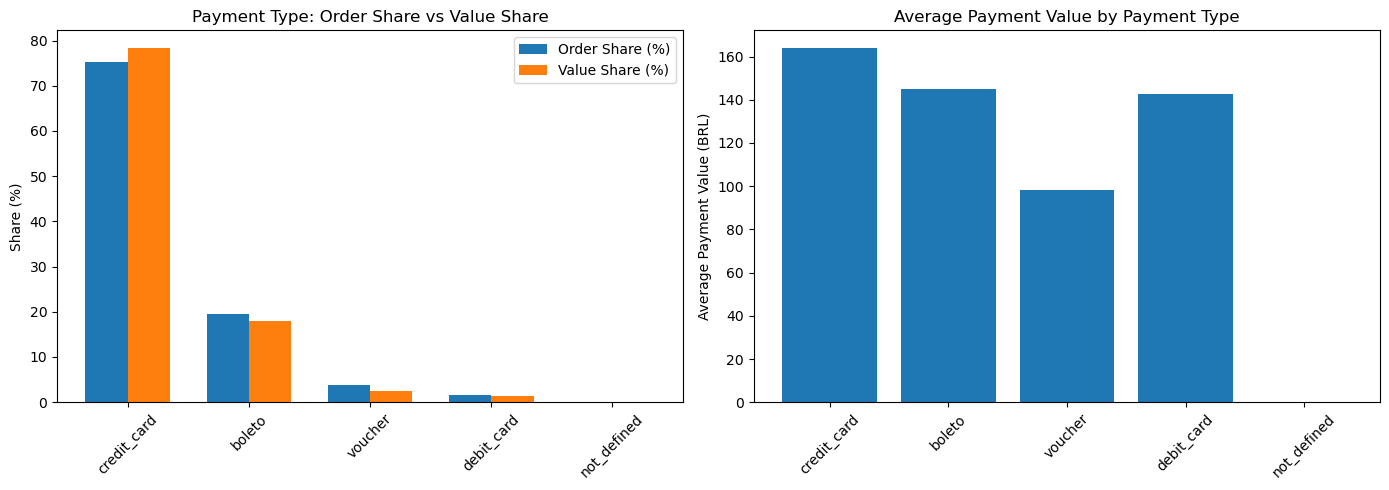

In [303]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

x = np.arange(len(payment_type_analysis))
w = 0.35
axes[0].bar(x - w/2, payment_type_analysis["order_share"], width = w, label="Order Share (%)")
axes[0].bar(x + w/2, payment_type_analysis["value_share"], width = w, label="Value Share (%)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(payment_type_analysis["payment_type"], rotation=45)
axes[0].set_ylabel("Share (%)")
axes[0].set_title("Payment Type: Order Share vs Value Share")
axes[0].legend()

axes[1].bar(payment_type_analysis["payment_type"], payment_type_analysis["avg_payment_value"])
axes[1].tick_params(axis="x", rotation=45)
axes[1].set_ylabel("Average Payment Value (BRL)")
axes[1].set_title("Average Payment Value by Payment Type")

plt.tight_layout()
plt.show()

Credit card's value share exceeds its order share, confirming above-average transaction size; boleto and voucher show the reverse, skewing smaller. Average payment value confirms this directly — credit card highest (~₹164), voucher lowest (~₹98), with voucher showing the largest usage-vs-value gap.

In [304]:
# Installment Usage Distribution

query = """SELECT payment_installments,
COUNT(*) AS payment_transactions
FROM olist_order_payments_dataset
WHERE payment_installments > 0
GROUP BY payment_installments
ORDER BY payment_installments"""
installment_usage = pd.read_sql(query, engine)
installment_usage

,payment_installments,payment_transactions
0,1,52546
1,2,12413
2,3,10461
3,4,7098
4,5,5239
5,6,3920
6,7,1626
7,8,4268
8,9,644
9,10,5328


In [305]:
# Payment Value vs Installment Count

query = """SELECT payment_installments, payment_value
FROM olist_order_payments_dataset
WHERE payment_installments > 0"""
installment_value = pd.read_sql(query, engine)
installment_value

,payment_installments,payment_value
0,8,99.33
1,1,24.39
2,1,65.71
3,8,107.78
4,2,128.45
...,...,...
103879,1,363.31
103880,2,96.80
103881,1,47.77
103882,5,369.54


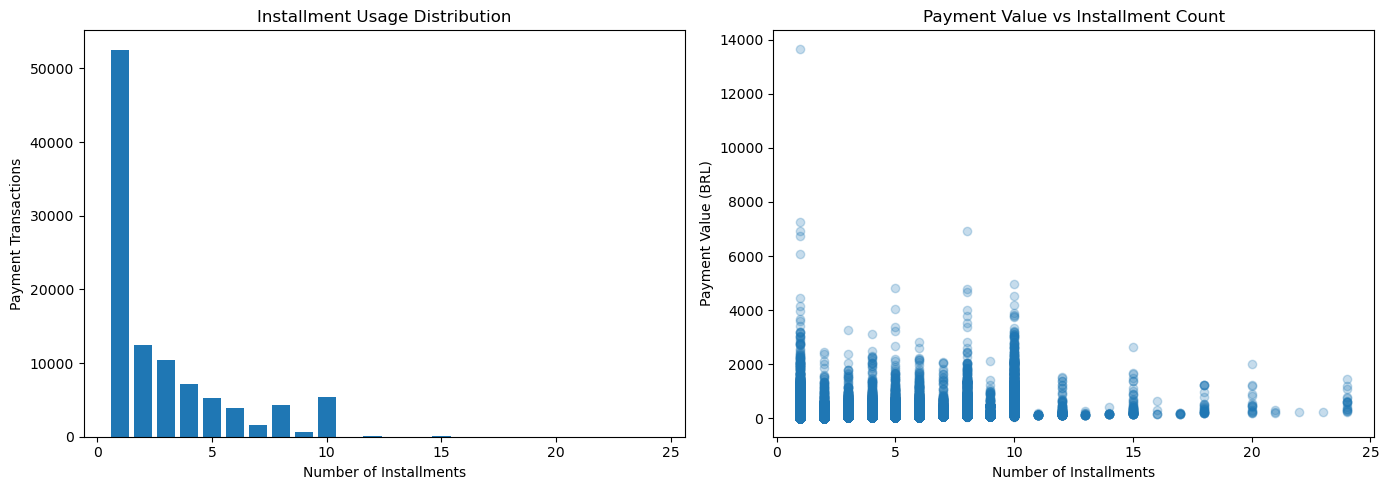

In [306]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(installment_usage["payment_installments"], installment_usage["payment_transactions"])
axes[0].set_xlabel("Number of Installments")
axes[0].set_ylabel("Payment Transactions")
axes[0].set_title("Installment Usage Distribution")

axes[1].scatter(installment_value["payment_installments"], installment_value["payment_value"], alpha=0.25)
axes[1].set_xlabel("Number of Installments")
axes[1].set_ylabel("Payment Value (BRL)")
axes[1].set_title("Payment Value vs Installment Count")

plt.tight_layout()
plt.show()

Installments segment into three tiers: 1x dominates (~68% of transactions), 2–7x forms a declining mid-tier, and both 8x and 10x break the decline as round-number spikes (with 9x dipping between them); 11+ is a negligible long tail. 

### Section 6 Delivery and Fulfillment

In [307]:
# Late Delivery Rate

query = """SELECT
ROUND(100.0 * COUNT(*) FILTER (WHERE order_delivered_customer_date::TIMESTAMP > order_estimated_delivery_date::TIMESTAMP)
/ COUNT(*), 2) AS late_delivery_rate
FROM olist_orders_dataset
WHERE order_status = 'delivered'
AND order_delivered_customer_date IS NOT NULL"""
late_delivery_rate = pd.read_sql(query, engine)
late_delivery_rate

,late_delivery_rate
0,8.11


In [310]:
# Delivery Time Distribution

query = """SELECT order_id, order_purchase_timestamp::TIMESTAMP, order_delivered_customer_date::TIMESTAMP,
ROUND(EXTRACT(EPOCH FROM (order_delivered_customer_date::TIMESTAMP - order_purchase_timestamp::TIMESTAMP)) / 86400.0, 2) 
AS delivery_days
FROM olist_orders_dataset
WHERE order_delivered_customer_date IS NOT NULL
AND order_delivered_customer_date::TIMESTAMP >= order_purchase_timestamp::TIMESTAMP"""
delivery_time_distribution = pd.read_sql(query, engine)
delivery_time_distribution

,order_id,order_purchase_timestamp,order_delivered_customer_date,delivery_days
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10-10 21:25:13,8.44
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,2018-08-07 15:27:45,13.78
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,2018-08-17 18:06:29,9.39
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,2017-12-02 00:28:42,13.21
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,2018-02-16 18:17:02,2.87
...,...,...,...,...
96471,9c5dedf39a927c1b2549525ed64a053c,2017-03-09 09:54:05,2017-03-17 15:08:01,8.22
96472,63943bddc261676b46f01ca7ac2f7bd8,2018-02-06 12:58:58,2018-02-28 17:37:56,22.19
96473,83c1379a015df1e13d02aae0204711ab,2017-08-27 14:46:43,2017-09-21 11:24:17,24.86
96474,11c177c8e97725db2631073c19f07b62,2018-01-08 21:28:27,2018-01-25 23:32:54,17.09


In [311]:
# Median Delivery Days & Median Late Delivery Days

query = """WITH delivery_base AS (
SELECT EXTRACT(EPOCH FROM (order_delivered_customer_date::TIMESTAMP - order_purchase_timestamp::TIMESTAMP)) 
/ 86400.0 AS delivery_days,
CASE WHEN order_delivered_customer_date::TIMESTAMP > order_estimated_delivery_date::TIMESTAMP THEN 'Late'
ELSE 'In-time' 
END AS status
FROM olist_orders_dataset
WHERE order_status = 'delivered'
AND order_delivered_customer_date IS NOT NULL
AND order_delivered_customer_date::TIMESTAMP >= order_purchase_timestamp::TIMESTAMP)
SELECT ROUND(PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY delivery_days)::NUMERIC, 2) AS median_delivery_days,
ROUND(PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY delivery_days) 
FILTER (WHERE status = 'Late')::NUMERIC, 2) AS median_late_delivery_days
FROM delivery_base"""
delivery_kpis = pd.read_sql(query, engine)
delivery_kpis

,median_delivery_days,median_late_delivery_days
0,10.22,29.15


### Section 7 Seller Performance

In [312]:
# Seller Performance Summary

# Grain: Seller (order-item level)

# Seller identity exists at the order-item level in Olist, therefore seller revenue and seller participation
# are aggregated at the seller grain.

query = """WITH seller_summary AS (
SELECT oi.seller_id,
COUNT(DISTINCT o.order_id) AS total_orders,
COUNT(DISTINCT o.order_id) FILTER (WHERE order_status NOT IN ('canceled','unavailable')) AS clean_orders,
COUNT(DISTINCT o.order_id) FILTER (WHERE order_status IN ('canceled','unavailable')) AS failed_orders,
SUM(oi.price) AS total_revenue,
SUM(oi.price) FILTER (WHERE order_status NOT IN ('canceled','unavailable')) AS clean_revenue,
SUM(oi.price) FILTER (WHERE order_status IN ('canceled','unavailable')) AS failed_revenue
FROM olist_order_items_dataset oi
JOIN olist_orders_dataset o ON oi.order_id = o.order_id
GROUP BY oi.seller_id)
SELECT seller_id,
total_orders, clean_orders, failed_orders,
ROUND(total_revenue::NUMERIC,2) AS total_revenue,
ROUND(clean_revenue::NUMERIC,2) AS clean_revenue,
ROUND(failed_revenue::NUMERIC,2) AS failed_revenue,
ROUND((100.0 * SUM(clean_orders) OVER (ORDER BY clean_orders DESC 
ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW)
/ SUM(clean_orders) OVER ())::NUMERIC, 2) AS cumulative_order_share,
ROUND((100.0 * SUM(clean_revenue) OVER (ORDER BY clean_revenue DESC 
ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW)
/ SUM(clean_revenue) OVER ())::NUMERIC, 2) AS cumulative_revenue_share
FROM seller_summary
ORDER BY clean_orders DESC;"""

seller_summary = pd.read_sql(query, engine)
seller_summary

,seller_id,total_orders,clean_orders,failed_orders,total_revenue,clean_revenue,failed_revenue,cumulative_order_share,cumulative_revenue_share
0,6560211a19b47992c3666cc44a7e94c0,1854,1847,7,123304.83,122776.83,528.00,1.86,15.06
1,4a3ca9315b744ce9f8e9374361493884,1806,1804,2,200472.92,200326.12,146.80,3.67,4.83
2,cc419e0650a3c5ba77189a1882b7556a,1706,1697,9,104288.42,103634.51,653.91,5.37,19.13
3,1f50f920176fa81dab994f9023523100,1404,1403,1,106939.21,106889.31,49.90,6.78,18.36
4,da8622b14eb17ae2831f4ac5b9dab84a,1314,1314,0,160236.57,160236.57,NaN,8.10,10.12
...,...,...,...,...,...,...,...,...,...
3090,e46bc031f2c5bae4ccb40bb90712e9b4,1,0,1,277.30,NaN,277.30,100.00,NaN
3091,f543ba3c973276f519d89d59bd46cead,2,0,2,258.00,NaN,258.00,100.00,NaN
3092,dadc51ef321949ec9a3ab25cd902e23d,1,0,1,85.00,NaN,85.00,100.00,NaN
3093,278b6e0b20c4f61fefaa0577943d7a35,1,0,1,1078.00,NaN,1078.00,100.00,NaN


In [313]:
# Seller Concentration Threshold Check - Clean Orders

# Finds minimum sellers required to exceed cumulative order thresholds

cume_dist = np.arange(0.2, 1, 0.05)

for c in cume_dist:

    query = f"""WITH seller_summary AS (
    SELECT oi.seller_id,
    COUNT(DISTINCT o.order_id) AS total_orders,
    COUNT(DISTINCT o.order_id) FILTER (WHERE order_status NOT IN ('canceled','unavailable')) AS clean_orders,
    COUNT(DISTINCT o.order_id) FILTER (WHERE order_status IN ('canceled','unavailable')) AS failed_orders,
    SUM(oi.price) AS total_revenue,
    SUM(oi.price) FILTER (WHERE order_status NOT IN ('canceled','unavailable')) AS clean_revenue,
    SUM(oi.price) FILTER (WHERE order_status IN ('canceled','unavailable')) AS failed_revenue
    FROM olist_order_items_dataset oi
    JOIN olist_orders_dataset o ON oi.order_id = o.order_id
    GROUP BY oi.seller_id),
    seller_cume_summary AS (
    SELECT seller_id, total_orders, clean_orders, failed_orders,
    ROUND(total_revenue::NUMERIC,2) AS total_revenue,
    ROUND(clean_revenue::NUMERIC,2) AS clean_revenue,
    ROUND(failed_revenue::NUMERIC,2) AS failed_revenue,
    ROUND((100.0 * SUM(clean_orders) OVER (ORDER BY clean_orders DESC 
    ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW)
    / SUM(clean_orders) OVER ())::NUMERIC, 2) AS cumulative_order_share,
    ROUND((100.0 * SUM(clean_revenue) OVER (ORDER BY clean_revenue DESC 
    ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW)
    / SUM(clean_revenue) OVER ())::NUMERIC, 2) AS cumulative_revenue_share
    FROM seller_summary
    ORDER BY clean_orders DESC),
    prev_cume AS (
    SELECT seller_id, clean_orders, cumulative_order_share,
    LAG(cumulative_order_share, 1, 0) OVER (ORDER BY clean_orders DESC, seller_id) AS prev_cum_share
    FROM seller_cume_summary)
    SELECT {100*c} AS cumulative_threshold,
    COUNT(*) AS sellers_required_to_exceed
    FROM prev_cume
    WHERE cumulative_order_share < {100*c}
    OR prev_cum_share < {100*c}
    ORDER BY sellers_required_to_exceed DESC;"""

    seller_order_threshold = pd.read_sql(query, engine)
    print(seller_order_threshold)

   cumulative_threshold  sellers_required_to_exceed
0                  20.0                          18
   cumulative_threshold  sellers_required_to_exceed
0                  25.0                          27
   cumulative_threshold  sellers_required_to_exceed
0                  30.0                          40
   cumulative_threshold  sellers_required_to_exceed
0                  35.0                          55
   cumulative_threshold  sellers_required_to_exceed
0                  40.0                          74
   cumulative_threshold  sellers_required_to_exceed
0                  45.0                          99
   cumulative_threshold  sellers_required_to_exceed
0                  50.0                         130
   cumulative_threshold  sellers_required_to_exceed
0                  55.0                         166
   cumulative_threshold  sellers_required_to_exceed
0                  60.0                         211
   cumulative_threshold  sellers_required_to_exceed
0           

In [314]:
# Seller Concentration Threshold Check - Clean Revenue

# Finds minimum sellers required to exceed cumulative revenue thresholds

cume_dist = np.arange(0.2, 1, 0.05)

for c in cume_dist:
    query = f"""WITH seller_summary AS (
    SELECT oi.seller_id,
    COUNT(DISTINCT o.order_id) AS total_orders,
    COUNT(DISTINCT o.order_id) FILTER (WHERE order_status NOT IN ('canceled','unavailable')) AS clean_orders,
    COUNT(DISTINCT o.order_id) FILTER (WHERE order_status IN ('canceled','unavailable'))AS failed_orders,
    SUM(oi.price) AS total_revenue,
    SUM(oi.price) FILTER (WHERE order_status NOT IN ('canceled','unavailable')) AS clean_revenue,
    SUM(oi.price) FILTER (WHERE order_status IN ('canceled','unavailable')) AS failed_revenue
    FROM olist_order_items_dataset oi
    JOIN olist_orders_dataset o ON oi.order_id = o.order_id
    GROUP BY oi.seller_id),
    seller_cume_summary AS (
    SELECT seller_id, clean_revenue,
    ROUND((100.0 * SUM(clean_revenue) OVER (ORDER BY clean_revenue DESC ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW)
    / SUM(clean_revenue) OVER ())::NUMERIC, 2) AS cumulative_revenue_share
    FROM seller_summary
    ORDER BY clean_orders DESC),
    prev_cume AS (
    SELECT seller_id, clean_revenue, cumulative_revenue_share,
    LAG(cumulative_revenue_share, 1, 0) OVER (ORDER BY clean_revenue DESC, seller_id) AS prev_cum_share
    FROM seller_cume_summary)
    SELECT {100*c} AS cumulative_threshold,
    COUNT(*) AS sellers_required_to_exceed
    FROM prev_cume
    WHERE cumulative_revenue_share < {100*c}
    OR prev_cum_share < {100*c}
    ORDER BY sellers_required_to_exceed DESC;"""

    seller_revenue_threshold = pd.read_sql(query, engine)
    print(seller_revenue_threshold)

   cumulative_threshold  sellers_required_to_exceed
0                  20.0                          20
   cumulative_threshold  sellers_required_to_exceed
0                  25.0                          30
   cumulative_threshold  sellers_required_to_exceed
0                  30.0                          42
   cumulative_threshold  sellers_required_to_exceed
0                  35.0                          58
   cumulative_threshold  sellers_required_to_exceed
0                  40.0                          77
   cumulative_threshold  sellers_required_to_exceed
0                  45.0                         100
   cumulative_threshold  sellers_required_to_exceed
0                  50.0                         130
   cumulative_threshold  sellers_required_to_exceed
0                  55.0                         169
   cumulative_threshold  sellers_required_to_exceed
0                  60.0                         218
   cumulative_threshold  sellers_required_to_exceed
0           

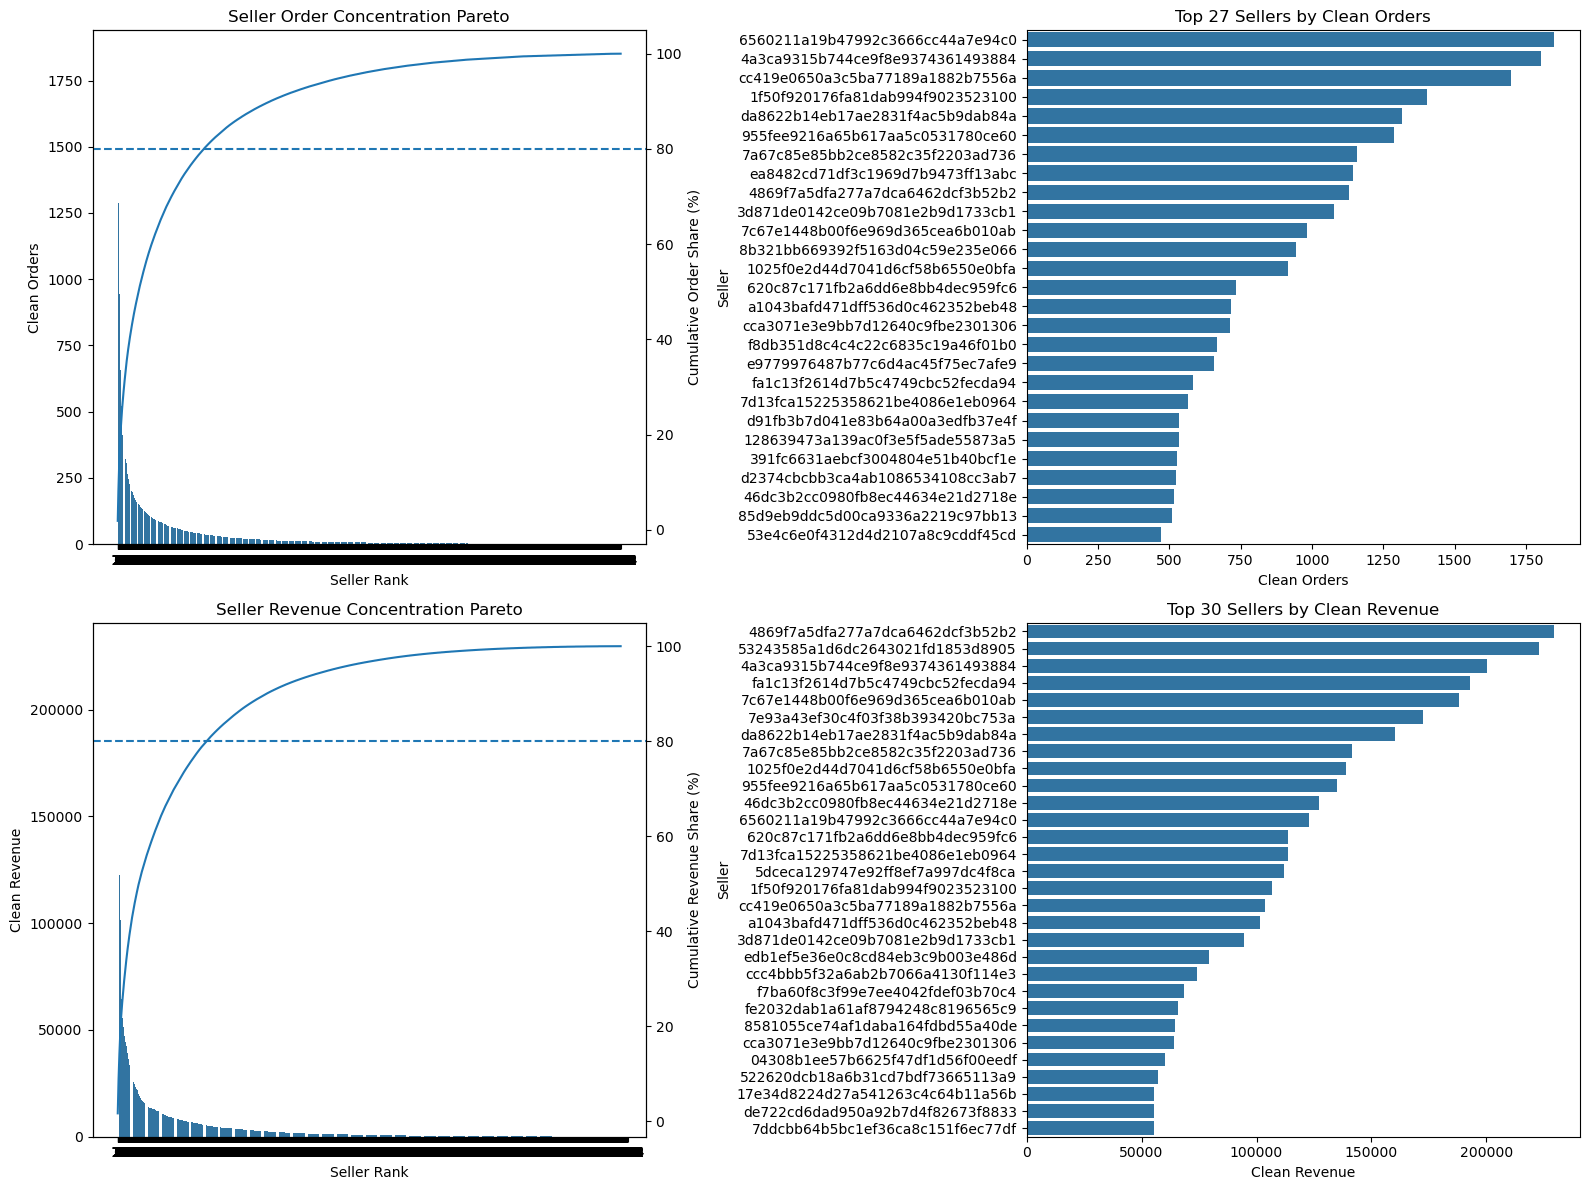

In [316]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

ax = axes[0, 0]
sns.barplot(x=range(len(seller_summary)), y=seller_summary["clean_orders"],ax=ax)
ax.set_title("Seller Order Concentration Pareto")
ax.set_xlabel("Seller Rank")
ax.set_ylabel("Clean Orders")
ax2 = ax.twinx()
sns.lineplot(x = range(len(seller_summary)), y = seller_summary["cumulative_order_share"], ax=ax2)
ax2.set_ylabel("Cumulative Order Share (%)")
ax2.axhline(80, linestyle="--")

ax = axes[0, 1]
sns.barplot(data=seller_summary.head(27), y="seller_id", x="clean_orders", ax=ax)
ax.set_title("Top 27 Sellers by Clean Orders")
ax.set_xlabel("Clean Orders")
ax.set_ylabel("Seller")

seller_revenue_sorted = seller_summary.sort_values( by ="clean_revenue",ascending=False).reset_index(drop=True)

ax = axes[1, 0]
sns.barplot(x=range(len(seller_revenue_sorted)), y=seller_revenue_sorted["clean_revenue"],ax=ax)
ax.set_title("Seller Revenue Concentration Pareto")
ax.set_xlabel("Seller Rank")
ax.set_ylabel("Clean Revenue")
ax2 = ax.twinx()
sns.lineplot(x = range(len(seller_revenue_sorted)), y = seller_revenue_sorted["cumulative_revenue_share"], ax = ax2)
ax2.set_ylabel("Cumulative Revenue Share (%)")
ax2.axhline(80, linestyle="--")

ax = axes[1, 1]
sns.barplot(data=seller_revenue_sorted.head(30), y="seller_id", x="clean_revenue", ax=ax)
ax.set_title("Top 30 Sellers by Clean Revenue")
ax.set_xlabel("Clean Revenue")
ax.set_ylabel("Seller")

plt.tight_layout()
plt.show()

In [317]:
# Seller Delay Performance

# Grain: Seller

# Seller participation is measured at the order level
# Late delivery is also an order-level metric because delivery status is assigned 
# to the complete order rather than individual items.

query = """WITH seller_delay AS (
SELECT seller_id, 
COUNT(DISTINCT o.order_id) FILTER (WHERE o.order_status NOT IN ('canceled','unavailable')) AS clean_orders,
COUNT(DISTINCT o.order_id) FILTER (WHERE o.order_status = 'delivered') AS delivered_orders,
COUNT(DISTINCT o.order_id) FILTER (WHERE o.order_status = 'delivered' 
AND order_delivered_customer_date::TIMESTAMP > order_estimated_delivery_date::TIMESTAMP) AS late_orders
FROM olist_order_items_dataset oi
JOIN olist_orders_dataset o ON oi.order_id = o.order_id
GROUP BY seller_id)
SELECT seller_id, clean_orders, delivered_orders, late_orders,
ROUND((100.0 * late_orders / NULLIF(delivered_orders,0))::NUMERIC, 2) AS late_delivery_rate
FROM seller_delay
ORDER BY clean_orders DESC;"""
seller_delay = pd.read_sql(query, engine)
seller_delay

,seller_id,clean_orders,delivered_orders,late_orders,late_delivery_rate
0,6560211a19b47992c3666cc44a7e94c0,1847,1819,117,6.43
1,4a3ca9315b744ce9f8e9374361493884,1804,1772,195,11.00
2,cc419e0650a3c5ba77189a1882b7556a,1697,1651,101,6.12
3,1f50f920176fa81dab994f9023523100,1403,1399,148,10.58
4,da8622b14eb17ae2831f4ac5b9dab84a,1314,1311,100,7.63
...,...,...,...,...,...
3090,afac9f6b0c4e5f0a7ee87e922cd0f873,0,0,0,NaN
3091,a1ed30492b3b798bc121845bc4aa7366,0,0,0,NaN
3092,86649b1632b1c0e6c0bcb2c90a8b75d8,0,0,0,NaN
3093,d1a1b40ec554c593a1a99366746289dd,0,0,0,NaN


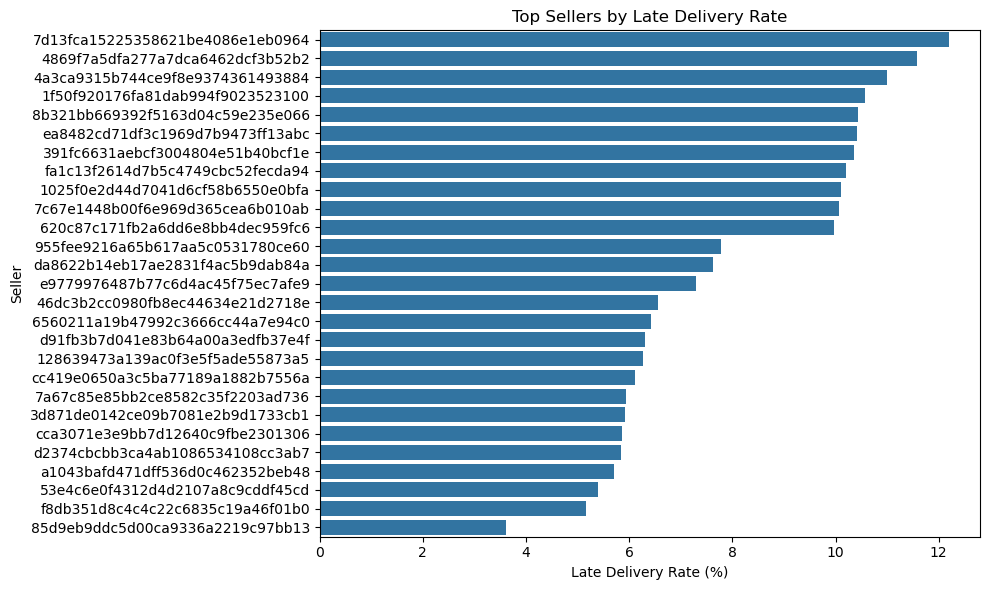

In [318]:
# Top Sellers by Late Delivery Rate

plot_df = (seller_delay.head(27).sort_values("late_delivery_rate", ascending=False))
plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, y="seller_id", x="late_delivery_rate")
plt.title("Top Sellers by Late Delivery Rate")
plt.xlabel("Late Delivery Rate (%)")
plt.ylabel("Seller")
plt.tight_layout()
plt.show()

### Section 8 Category Analysis

In [321]:
# Category Order Volume vs Category Revenue
#
# Grain: Category

query = """WITH category_summary AS (
SELECT COALESCE(p.product_category_name,'Unknown') AS product_category,
COUNT(DISTINCT o.order_id) FILTER (WHERE o.order_status NOT IN ('canceled','unavailable')) AS clean_orders,
SUM(oi.price) FILTER (WHERE o.order_status NOT IN ('canceled','unavailable')) AS clean_revenue
FROM olist_order_items_dataset oi
JOIN olist_orders_dataset o ON oi.order_id = o.order_id
JOIN olist_products_dataset p
ON oi.product_id = p.product_id
GROUP BY COALESCE(p.product_category_name,'Unknown'))
SELECT product_category, clean_orders,
ROUND((100.0 * SUM(clean_orders) OVER (ORDER BY clean_orders DESC ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW)
/ SUM(clean_orders) OVER ())::NUMERIC, 2) AS cumulative_order_share,
ROUND(clean_revenue::NUMERIC,2) AS clean_revenue,
ROUND((100.0 * SUM(clean_revenue) OVER (ORDER BY clean_revenue DESC ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW)
/ SUM(clean_revenue) OVER ())::NUMERIC, 2) AS cumulative_revenue_share
FROM category_summary
ORDER BY clean_orders DESC;"""

category_summary = pd.read_sql(query, engine)

category_summary

,product_category,clean_orders,cumulative_order_share,clean_revenue,cumulative_revenue_share
0,cama_mesa_banho,9399,9.49,1035964.06,25.86
1,beleza_saude,8800,18.38,1255695.13,9.31
2,esporte_lazer,7673,26.13,979740.92,33.12
3,informatica_acessorios,6654,32.85,904322.02,39.82
4,moveis_decoracao,6425,39.34,727465.05,45.21
...,...,...,...,...,...
69,la_cuisine,13,99.97,2054.99,99.94
70,cds_dvds_musicais,12,99.98,730.00,99.99
71,fashion_roupa_infanto_juvenil,8,99.99,569.85,100.00
72,pc_gamer,7,100.00,1306.95,99.97


In [322]:
# Category Threshold Check - Clean Orders
#
# Finds the minimum number of categories required to exceed different
# cumulative clean order thresholds.
#
# Tie handling:
# clean_orders alone is not enough because multiple categories can have
# identical order counts. Therefore the same deterministic ordering
# (clean_orders DESC, product_category) is used in both:
# 1. cumulative SUM window
# 2. LAG window
#
# This prevents inconsistent cutoff results.

cume_dist = np.arange(0.50, 1.00, 0.05)

for c in cume_dist:
    query = f"""WITH category_orders AS (
    SELECT COALESCE(p.product_category_name,'Unknown') AS product_category,
    COUNT(DISTINCT o.order_id) FILTER (
    WHERE o.order_status NOT IN ('canceled','unavailable')) AS clean_orders
    FROM olist_order_items_dataset oi
    JOIN olist_orders_dataset o
    ON oi.order_id = o.order_id
    JOIN olist_products_dataset p ON oi.product_id = p.product_id
    GROUP BY COALESCE(p.product_category_name,'Unknown')),
    category_cume AS (
    SELECT product_category, clean_orders,
    ROUND((100.0 * SUM(clean_orders) OVER (ORDER BY clean_orders DESC, product_category
    ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW)
    / SUM(clean_orders) OVER ())::NUMERIC,2) AS cumulative_order_share
    FROM category_orders),
    prev_cume AS (
    SELECT product_category, clean_orders, cumulative_order_share,
    LAG(cumulative_order_share,1,0) OVER (ORDER BY clean_orders DESC, product_category) AS prev_cum_share
    FROM category_cume)
    SELECT {100*c} AS cumulative_threshold,
    COUNT(*) AS categories_required_to_exceed
    FROM prev_cume
    WHERE cumulative_order_share < {100*c}
    OR prev_cum_share < {100*c};"""

    display(pd.read_sql(query, engine))

,cumulative_threshold,categories_required_to_exceed
0,50.0,7


,cumulative_threshold,categories_required_to_exceed
0,55.0,8


,cumulative_threshold,categories_required_to_exceed
0,60.0,10


,cumulative_threshold,categories_required_to_exceed
0,65.0,11


,cumulative_threshold,categories_required_to_exceed
0,70.0,12


,cumulative_threshold,categories_required_to_exceed
0,75.0,14


,cumulative_threshold,categories_required_to_exceed
0,80.0,16


,cumulative_threshold,categories_required_to_exceed
0,85.0,19


,cumulative_threshold,categories_required_to_exceed
0,90.0,23


,cumulative_threshold,categories_required_to_exceed
0,95.0,33


In [323]:
# Category Threshold Check - Clean Revenue

cume_dist = np.arange(0.50, 1.00, 0.05)
for c in cume_dist:
    query = f"""WITH category_revenue AS (
    SELECT COALESCE(p.product_category_name,'Unknown') AS product_category,
    SUM(oi.price) FILTER (WHERE o.order_status NOT IN ('canceled','unavailable')) AS clean_revenue
    FROM olist_order_items_dataset oi
    JOIN olist_orders_dataset o ON oi.order_id = o.order_id
    JOIN olist_products_dataset p
    ON oi.product_id = p.product_id
    GROUP BY COALESCE(p.product_category_name,'Unknown')),
    category_cume AS (
    SELECT product_category, clean_revenue,
    ROUND((100.0 * SUM(clean_revenue) OVER (ORDER BY clean_revenue DESC, product_category
    ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW)
    / SUM(clean_revenue) OVER ())::NUMERIC, 2) AS cumulative_revenue_share
    FROM category_revenue),
    prev_cume AS (
    SELECT product_category, clean_revenue, cumulative_revenue_share,
    LAG(cumulative_revenue_share,1,0) OVER (ORDER BY clean_revenue DESC, product_category) AS prev_cum_share
    FROM category_cume )
    SELECT {100*c} AS cumulative_threshold, 
    COUNT(*) AS categories_required_to_exceed
    FROM prev_cume
    WHERE cumulative_revenue_share < {100*c}
    OR prev_cum_share < {100*c};"""

    display(pd.read_sql(query, engine))

,cumulative_threshold,categories_required_to_exceed
0,50.0,8


,cumulative_threshold,categories_required_to_exceed
0,55.0,9


,cumulative_threshold,categories_required_to_exceed
0,60.0,10


,cumulative_threshold,categories_required_to_exceed
0,65.0,11


,cumulative_threshold,categories_required_to_exceed
0,70.0,13


,cumulative_threshold,categories_required_to_exceed
0,75.0,15


,cumulative_threshold,categories_required_to_exceed
0,80.0,18


,cumulative_threshold,categories_required_to_exceed
0,85.0,21


,cumulative_threshold,categories_required_to_exceed
0,90.0,26


,cumulative_threshold,categories_required_to_exceed
0,95.0,34


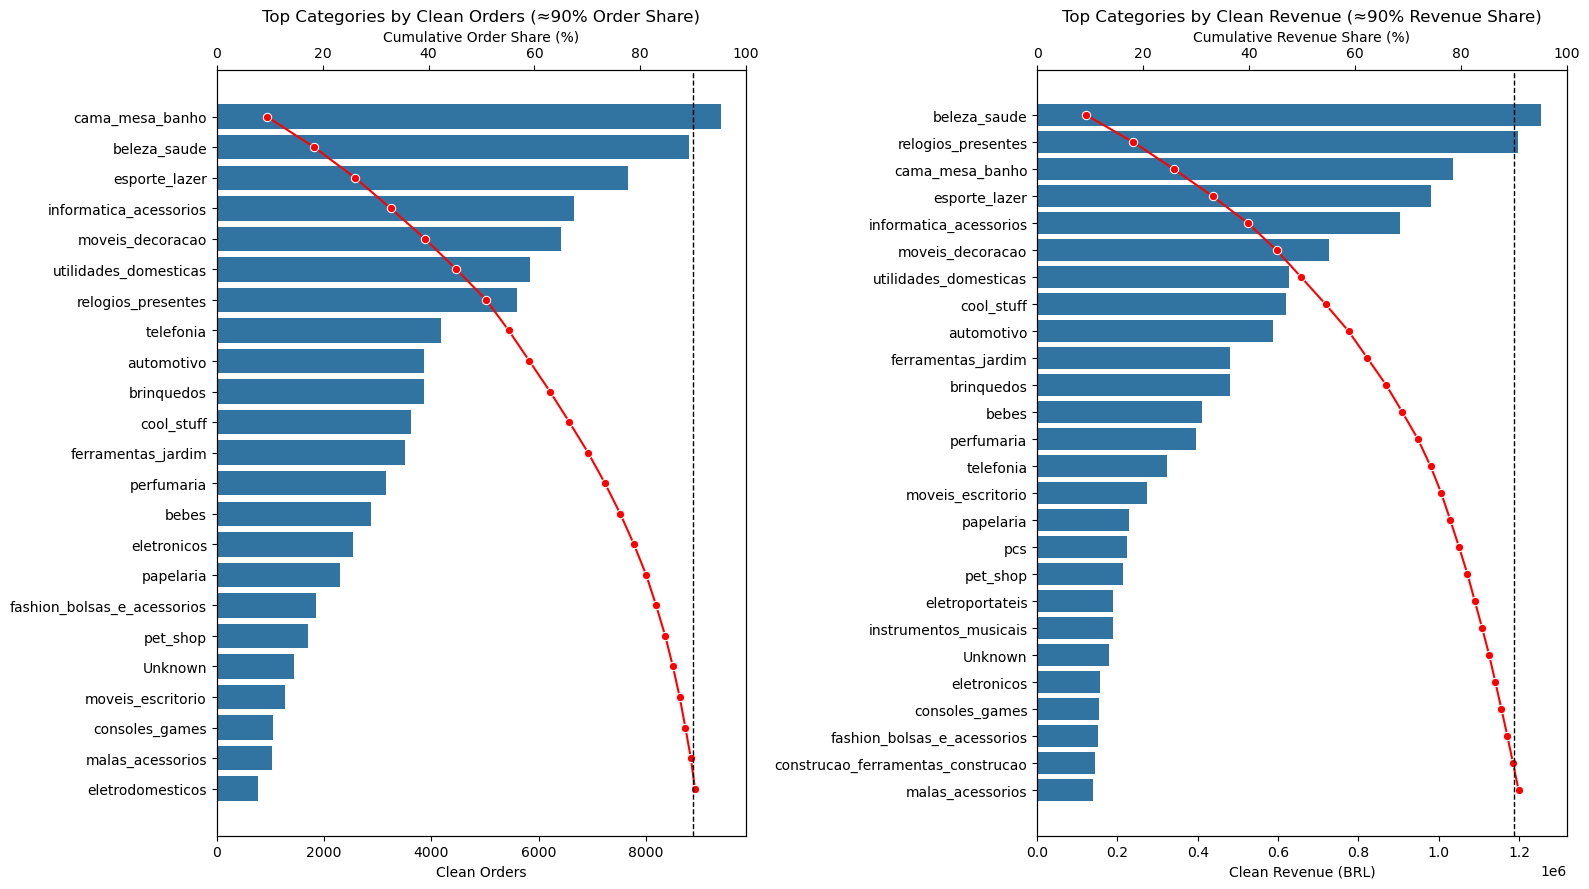

In [324]:
# Category Order Volume vs Category Revenue (90% Pareto)
# Horizontal bar + cumulative share line

plot_orders = category_summary.head(23).copy()
plot_revenue = (category_summary.sort_values("clean_revenue", ascending=False).head(26).copy())

fig, axes = plt.subplots(1, 2, figsize=(16, 9))

sns.barplot(data=plot_orders,y="product_category",x="clean_orders",ax=axes[0])
axes[0].set_title("Top Categories by Clean Orders (≈90% Order Share)")
axes[0].set_xlabel("Clean Orders")
axes[0].set_ylabel("")
ax2 = axes[0].twiny()
sns.lineplot(data=plot_orders, y="product_category",x="cumulative_order_share",marker="o", color="red",ax=ax2)
ax2.set_xlabel("Cumulative Order Share (%)")
ax2.set_xlim(0,100)
ax2.axvline(90, linestyle="--", color="black", linewidth=1)

sns.barplot(data=plot_revenue, y="product_category", x="clean_revenue", ax=axes[1])
axes[1].set_title("Top Categories by Clean Revenue (≈90% Revenue Share)")
axes[1].set_xlabel("Clean Revenue (BRL)")
axes[1].set_ylabel("")
ax3 = axes[1].twiny()
sns.lineplot(data=plot_revenue, y="product_category", x="cumulative_revenue_share", marker="o",color="red", ax=ax3)
ax3.set_xlabel("Cumulative Revenue Share (%)")
ax3.set_xlim(0,100)
ax3.axvline(90, linestyle="--", color="black", linewidth=1)

plt.tight_layout()
plt.show()

Rankings shift meaningfully between orders and revenue: relogios_presentes jumps from #7 to #2 (low volume, high value), while telefonia and brinquedos rank higher by orders than by revenue (high volume, low value per item). Some categories — pcs, moveis_escritorio, instrumentos_musicais, construcao_ferramentas_construcao — only appear in the top revenue share, not the top order share, indicating low-volume but high-value niches.

In [326]:
# Category Order Failure Rate
# Grain: Product Category (Order Level)

query = """WITH category_orders AS (
SELECT COALESCE(p.product_category_name,'Unknown') AS product_category,
COUNT(DISTINCT o.order_id) FILTER (WHERE o.order_status NOT IN ('canceled','unavailable')) AS clean_orders,
COUNT(DISTINCT o.order_id) FILTER (WHERE o.order_status IN ('canceled','unavailable')) AS failed_orders,
COUNT(DISTINCT o.order_id) AS total_orders
FROM olist_order_items_dataset oi
JOIN olist_orders_dataset o ON oi.order_id = o.order_id
JOIN olist_products_dataset p ON oi.product_id = p.product_id
GROUP BY COALESCE(p.product_category_name,'Unknown'))
SELECT product_category, total_orders, clean_orders, failed_orders,
ROUND((100.0 * failed_orders / total_orders)::NUMERIC, 2) AS category_order_failure_rate
FROM category_orders
ORDER BY total_orders DESC;"""
category_cancellation = pd.read_sql(query, engine)
category_cancellation

,product_category,total_orders,clean_orders,failed_orders,category_order_failure_rate
0,cama_mesa_banho,9417,9399,18,0.19
1,beleza_saude,8836,8800,36,0.41
2,esporte_lazer,7720,7673,47,0.61
3,informatica_acessorios,6689,6654,35,0.52
4,moveis_decoracao,6449,6425,24,0.37
...,...,...,...,...,...
69,la_cuisine,13,13,0,0.00
70,cds_dvds_musicais,12,12,0,0.00
71,pc_gamer,8,7,1,12.50
72,fashion_roupa_infanto_juvenil,8,8,0,0.00


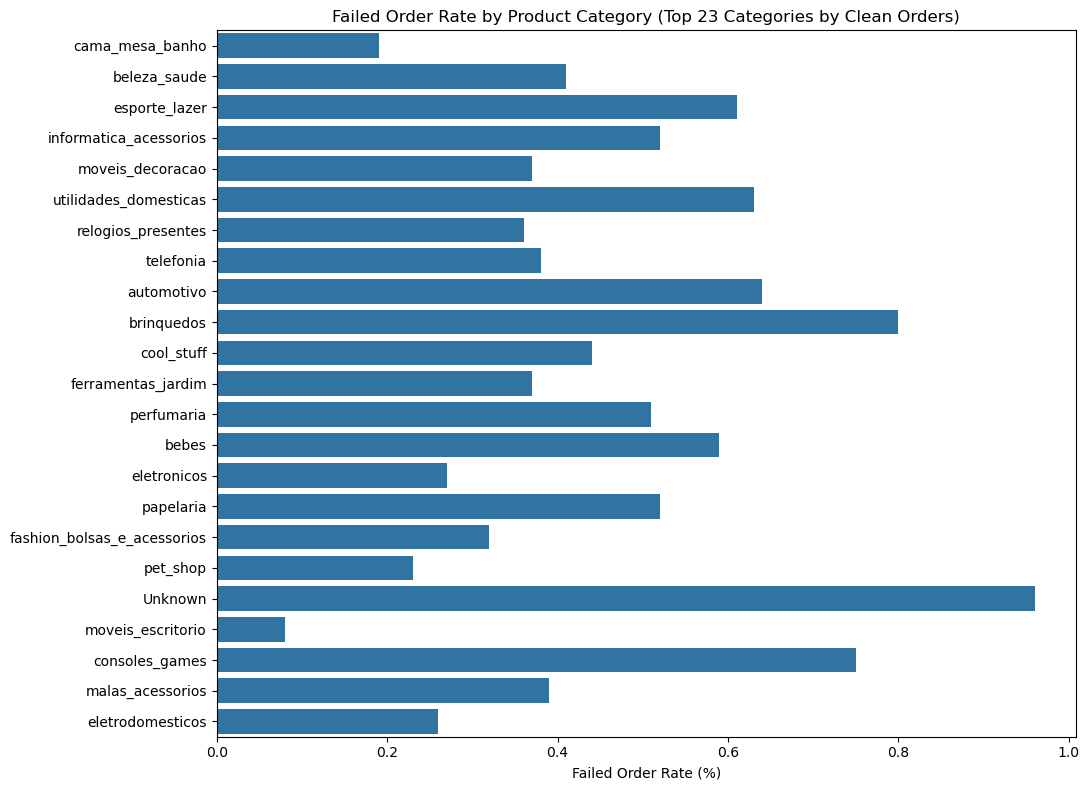

In [327]:
# Top Categories by Failed Order Rate
# Highest-volume categories only


plot_df = category_cancellation.head(23).copy()

plt.figure(figsize=(11, 8))

sns.barplot(
    data=plot_df,
    x="category_order_failure_rate",
    y="product_category"
)

plt.title("Failed Order Rate by Product Category (Top 23 Categories by Clean Orders)")
plt.xlabel("Failed Order Rate (%)")
plt.ylabel("")

plt.tight_layout()
plt.show()

### Section 9 Reviews & Satisfaction 

In [328]:
# Positive Review Rate
# Many order_ids have multiple review_ids
query = """WITH latest_reviews AS (
SELECT *,
ROW_NUMBER() OVER(
PARTITION BY order_id ORDER BY review_answer_timestamp DESC
) AS review_no
FROM olist_order_reviews_dataset)
SELECT COUNT(*) FILTER (WHERE review_score >= 4) * 100.0 / COUNT(*) AS positive_review_rate
FROM latest_reviews
WHERE review_no = 1"""
p_review_rate = pd.read_sql(query, engine)
p_review_rate

,positive_review_rate
0,77.068702


In [330]:
# Negative Review Rate
# Many order_ids have multiple review_ids
query = """WITH latest_reviews AS (
SELECT *,
ROW_NUMBER() OVER(
PARTITION BY order_id ORDER BY review_answer_timestamp DESC
) AS review_no
FROM olist_order_reviews_dataset)
SELECT COUNT(*) FILTER (WHERE review_score <= 2) * 100.0 / COUNT(*) AS negative_review_rate
FROM latest_reviews
WHERE review_no = 1"""
n_review_rate = pd.read_sql(query, engine)
n_review_rate

,negative_review_rate
0,14.688922


In [332]:
# Review Score Distribution

# Grain: Delivered Order

# Only delivered orders are included because customer satisfaction is evaluated after successful fulfillment. 
# Where multiple reviews exist for the same order, only the latest review is retained 
# to represent the customer's final opinion.

query = """WITH latest_reviews AS (
SELECT r.order_id, r.review_score,
ROW_NUMBER() OVER (PARTITION BY r.order_id ORDER BY r.review_answer_timestamp DESC) AS review_no
FROM olist_order_reviews_dataset r
JOIN olist_orders_dataset o ON r.order_id = o.order_id
WHERE o.order_status = 'delivered')
SELECT review_score,
COUNT(*) AS total_reviews
FROM latest_reviews
WHERE review_no = 1
GROUP BY review_score
ORDER BY review_score;"""
review_distribution = pd.read_sql(query, engine)
review_distribution 

,review_score,total_reviews
0,1,9352
1,2,2921
2,3,7916
3,4,18888
4,5,56755


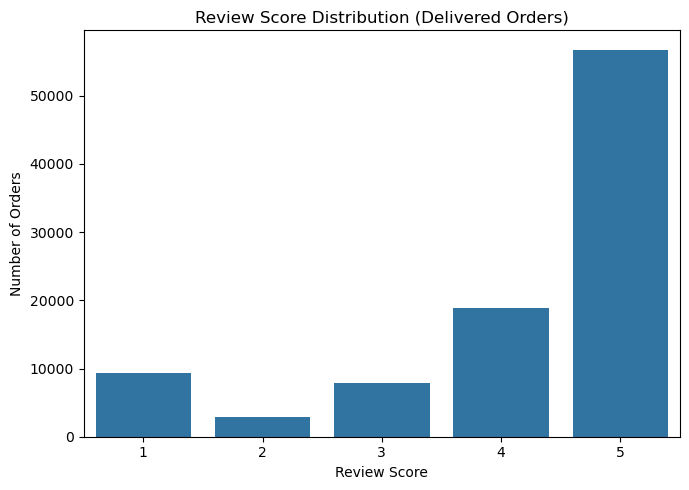

In [333]:
plt.figure(figsize=(7,5))

sns.barplot(data=review_distribution, x="review_score", y="total_reviews")
plt.title("Review Score Distribution (Delivered Orders)")
plt.xlabel("Review Score")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

In [336]:
# Review Sentiment by Product Category
# Grain: Category (Order Level)
#
# Only delivered orders are considered because reviews represent delivered experiences.
# Latest review per order_id is retained to avoid duplicate reviews.
# Orders containing multiple categories contribute once to each category.
# Categories are sorted by clean order volume.
# Top 23 categories represent approximately 90% of category clean orders.

query = """WITH latest_reviews AS (
SELECT order_id,review_score,
ROW_NUMBER() OVER (PARTITION BY order_id ORDER BY review_answer_timestamp DESC) AS review_no
FROM olist_order_reviews_dataset),
order_category AS (
SELECT DISTINCT oi.order_id, COALESCE(p.product_category_name,'Unknown') AS product_category
FROM olist_order_items_dataset oi
JOIN olist_products_dataset p
ON oi.product_id = p.product_id),
category_reviews AS (
SELECT oc.product_category,
COUNT(DISTINCT lr.order_id) AS clean_orders,
COUNT(DISTINCT lr.order_id) FILTER (WHERE lr.review_score >= 4) AS positive_reviews,
COUNT(DISTINCT lr.order_id) FILTER (WHERE lr.review_score = 3) AS neutral_reviews,
COUNT(DISTINCT lr.order_id) FILTER (WHERE lr.review_score <= 2) AS negative_reviews,
COUNT(DISTINCT lr.order_id) AS total_reviews
FROM latest_reviews lr
JOIN olist_orders_dataset o
ON lr.order_id = o.order_id
JOIN order_category oc
ON lr.order_id = oc.order_id
WHERE lr.review_no = 1
AND o.order_status = 'delivered'
GROUP BY oc.product_category)
SELECT product_category, clean_orders, positive_reviews, neutral_reviews, negative_reviews, total_reviews,
ROUND((100.0 * positive_reviews / total_reviews)::NUMERIC, 2) AS positive_review_rate,
ROUND((100.0 * neutral_reviews / total_reviews)::NUMERIC, 2) AS neutral_review_rate,
ROUND((100.0 * negative_reviews / total_reviews)::NUMERIC, 2) AS negative_review_rate
FROM category_reviews
WHERE total_reviews > 0
ORDER BY clean_orders DESC;"""
category_review_sentiment = pd.read_sql(query, engine)

category_review_sentiment

,product_category,clean_orders,positive_reviews,neutral_reviews,negative_reviews,total_reviews,positive_review_rate,neutral_review_rate,negative_review_rate
0,cama_mesa_banho,9177,6788,918,1471,9177,73.97,10.00,16.03
1,beleza_saude,8601,6954,662,985,8601,80.85,7.70,11.45
2,esporte_lazer,7486,6090,544,852,7486,81.35,7.27,11.38
3,informatica_acessorios,6499,5021,532,946,6499,77.26,8.19,14.56
4,moveis_decoracao,6260,4743,556,961,6260,75.77,8.88,15.35
...,...,...,...,...,...,...,...,...,...
69,la_cuisine,12,10,0,2,12,83.33,0.00,16.67
70,cds_dvds_musicais,12,11,1,0,12,91.67,8.33,0.00
71,pc_gamer,7,5,0,2,7,71.43,0.00,28.57
72,fashion_roupa_infanto_juvenil,7,7,0,0,7,100.00,0.00,0.00


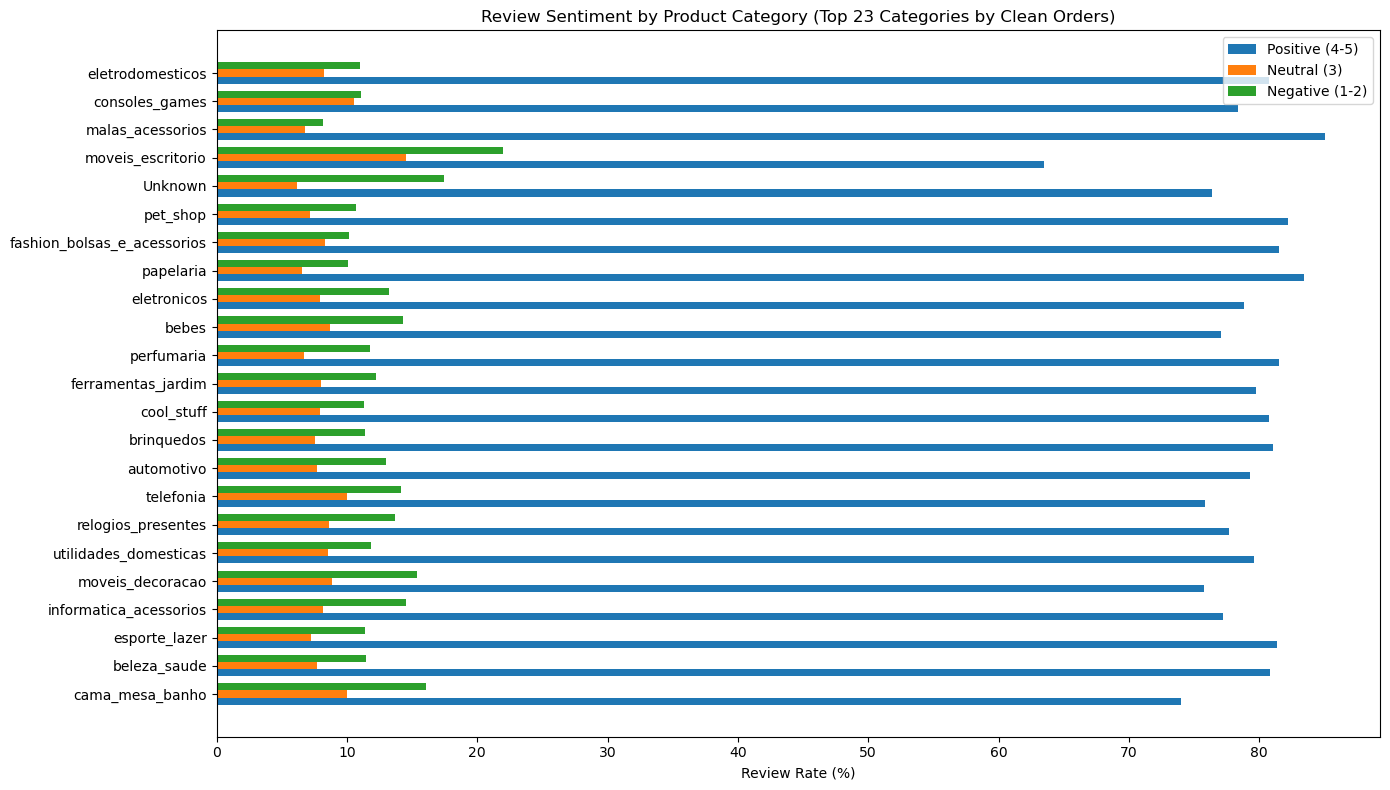

In [337]:
plot_df = category_review_sentiment.head(23).copy()

y = np.arange(len(plot_df))
H = 0.25

plt.figure(figsize=(14,8))

plt.barh(y-H, plot_df["positive_review_rate"], height = H, label="Positive (4-5)")
plt.barh(y, plot_df["neutral_review_rate"],height = H, label="Neutral (3)")
plt.barh(y+H, plot_df["negative_review_rate"],height = H, label="Negative (1-2)")

plt.yticks(y, plot_df["product_category"])
plt.xlabel("Review Rate (%)")
plt.ylabel("")
plt.title("Review Sentiment by Product Category (Top 23 Categories by Clean Orders)")
plt.legend()

plt.tight_layout()
plt.show()

Selling more doesn't mean customers are happier — cama_mesa_banho sells the most but has weaker sentiment, while top-revenue beleza_saude and relogios_presentes keep customers satisfied. Small categories show high satisfaction, likely due to fewer reviews. moveis_escritorio stands out as the clear exception — poor sentiment unrelated to its size.

In [338]:
# Survey Response Time Buckets vs Review Score
# Grain: Order Level

# Only delivered orders are considered.
# Latest review per order_id is retained.
# Response time = days between review creation and review answer.

query = """WITH latest_reviews AS (
SELECT order_id, review_score, review_creation_date, review_answer_timestamp,
ROW_NUMBER() OVER(PARTITION BY order_id ORDER BY review_answer_timestamp DESC) AS review_no
FROM olist_order_reviews_dataset),
base AS (
SELECT lr.order_id, lr.review_score,
(lr.review_answer_timestamp::date - lr.review_creation_date::date) AS response_days
FROM latest_reviews lr
JOIN olist_orders_dataset o ON lr.order_id = o.order_id
WHERE lr.review_no = 1
AND o.order_status = 'delivered'),
bucketed AS (
SELECT *,
CASE WHEN response_days = 0 THEN 'Same Day'
WHEN response_days = 1 THEN 'Next Day'
WHEN response_days BETWEEN 2 AND 3 THEN '2-3 Days'
WHEN response_days BETWEEN 4 AND 7 THEN '4-7 Days'
ELSE '7+ Days'
END AS time_bucket
FROM base)
SELECT time_bucket,
COUNT(*) FILTER (WHERE review_score = 1) AS score_1,
COUNT(*) FILTER (WHERE review_score = 2) AS score_2,
COUNT(*) FILTER (WHERE review_score = 3) AS score_3,
COUNT(*) FILTER (WHERE review_score = 4) AS score_4,
COUNT(*) FILTER (WHERE review_score = 5) AS score_5,
COUNT(*) AS total_reviews
FROM bucketed
GROUP BY time_bucket
ORDER BY
CASE time_bucket WHEN 'Same Day' THEN 1
WHEN 'Next Day' THEN 2
WHEN '2-3 Days' THEN 3
WHEN '4-7 Days' THEN 4
ELSE 5
END"""

check = pd.read_sql(query, engine)

check

,time_bucket,score_1,score_2,score_3,score_4,score_5,total_reviews
0,Same Day,3148,758,1806,3971,13192,22875
1,Next Day,2249,810,2409,6099,18859,30426
2,2-3 Days,2530,926,2543,6033,17052,29084
3,4-7 Days,1002,308,854,2025,5414,9603
4,7+ Days,423,119,304,760,2238,3844


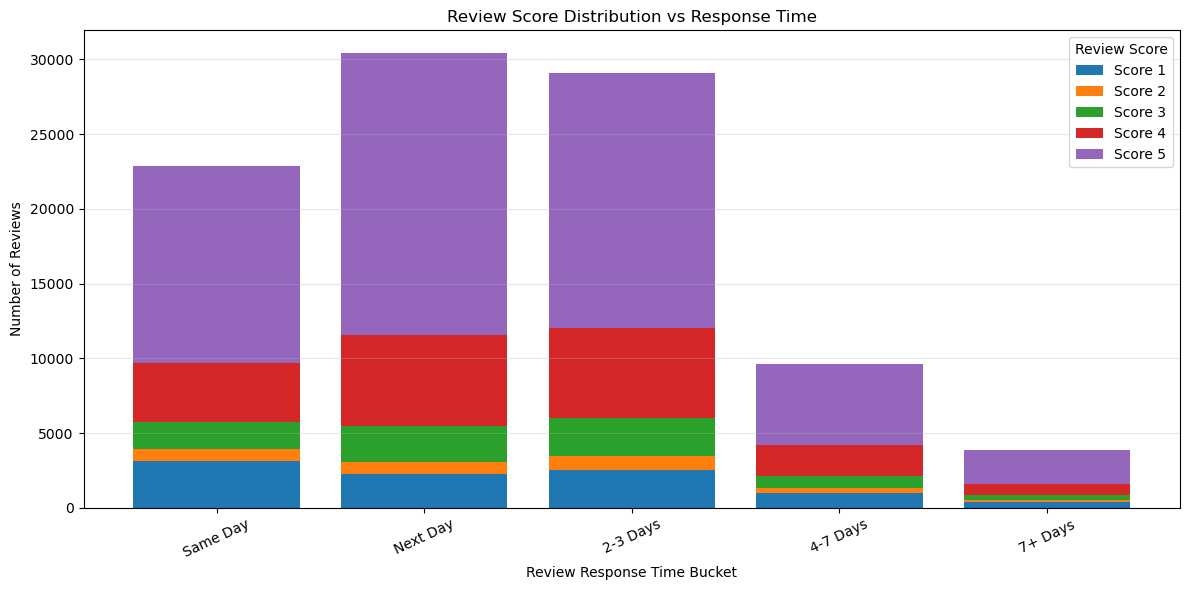

In [339]:
plt.figure(figsize=(12,6))

plt.bar(check["time_bucket"], check["score_1"], label="Score 1")
plt.bar(check["time_bucket"], check["score_2"], bottom=check["score_1"], label="Score 2")
plt.bar(check["time_bucket"], check["score_3"], bottom=check["score_1"] + check["score_2"], label="Score 3")
plt.bar(check["time_bucket"], check["score_4"], bottom=check["score_1"] + check["score_2"] + check["score_3"], 
        label="Score 4")
plt.bar(check["time_bucket"], check["score_5"], bottom=check["score_1"] + check["score_2"] + check["score_3"] 
        + check["score_4"], label="Score 5")

plt.xlabel("Review Response Time Bucket")
plt.ylabel("Number of Reviews")
plt.title("Review Score Distribution vs Response Time")

plt.xticks(rotation=25)
plt.legend(title="Review Score")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [340]:
# Delivery Delay Bucket vs Review Score
# Grain: Order Level
#
# Logic:
# - Only delivered orders are considered.
# - Latest review per order_id is retained.
# - Delay = actual delivery date - estimated delivery date.
# - Buckets are based on integer day difference.
# - Review score distribution is compared across delivery performance.

query = """WITH cte AS (
SELECT order_id, review_score,
ROW_NUMBER() OVER(
PARTITION BY order_id
ORDER BY review_answer_timestamp::TIMESTAMP DESC
) AS rn
FROM olist_order_reviews_dataset),
base AS (
SELECT order_id,
order_delivered_customer_date::DATE - order_estimated_delivery_date::DATE AS delay_days
FROM olist_orders_dataset
WHERE order_status = 'delivered'),
bucketed AS (
SELECT b.order_id, r.review_score,
CASE WHEN delay_days < -2 THEN 'Very Early'
WHEN delay_days >= -2 AND delay_days < 0 THEN 'Early'
WHEN delay_days = 0 THEN 'On-time'
WHEN delay_days > 0 AND delay_days <= 2 THEN 'Late'
ELSE 'Very Late'
END AS delivery_bucket
FROM base b
JOIN cte r
ON b.order_id = r.order_id
AND r.rn = 1)
SELECT delivery_bucket,
COUNT(*) FILTER (WHERE review_score = 1) AS score_1,
COUNT(*) FILTER (WHERE review_score = 2) AS score_2,
COUNT(*) FILTER (WHERE review_score = 3) AS score_3,
COUNT(*) FILTER (WHERE review_score = 4) AS score_4,
COUNT(*) FILTER (WHERE review_score = 5) AS score_5,
COUNT(*) AS total_reviews
FROM bucketed
GROUP BY delivery_bucket
ORDER BY CASE delivery_bucket
WHEN 'Very Early' THEN 1
WHEN 'Early' THEN 2
WHEN 'On-time' THEN 3
WHEN 'Late' THEN 4
ELSE 5
END;"""

delivery_review = pd.read_sql(query, engine)

delivery_review

,delivery_bucket,score_1,score_2,score_3,score_4,score_5,total_reviews
0,Very Early,5575,2214,6723,17274,53387,85173
1,Early,236,105,321,670,1658,2990
2,On-time,109,50,178,295,648,1280
3,Late,254,91,207,313,491,1356
4,Very Late,3178,461,487,336,571,5033


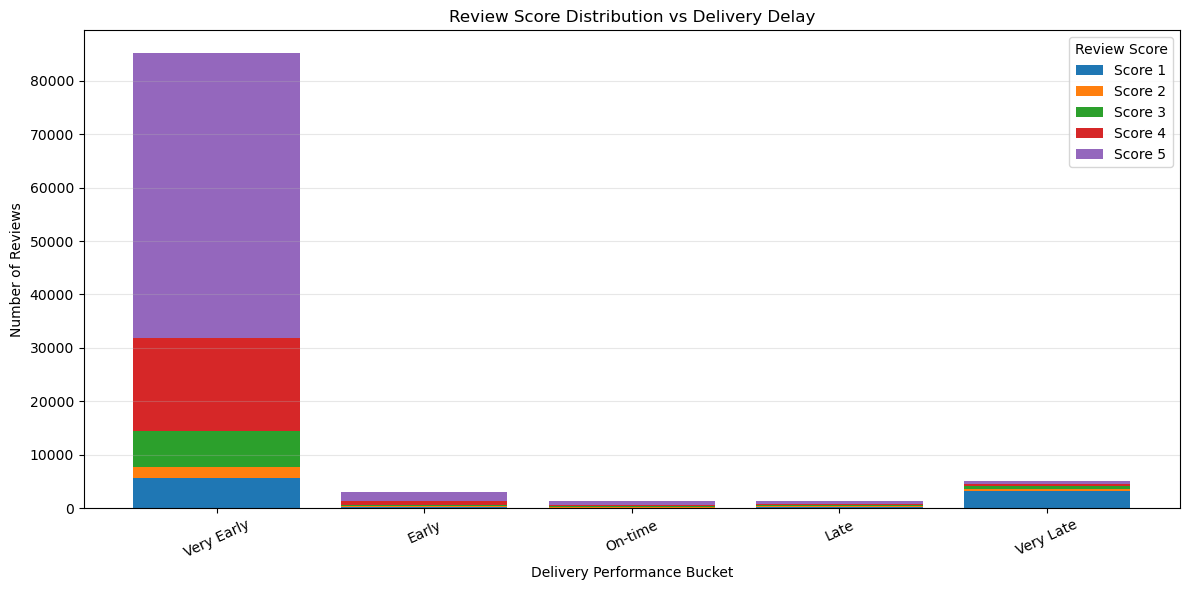

In [341]:
plt.figure(figsize=(12,6))

plt.bar(delivery_review["delivery_bucket"], delivery_review["score_1"], label="Score 1")
plt.bar(delivery_review["delivery_bucket"], delivery_review["score_2"], bottom=delivery_review["score_1"], 
        label="Score 2")
plt.bar(delivery_review["delivery_bucket"], delivery_review["score_3"], bottom=delivery_review["score_1"] 
        + delivery_review["score_2"], label="Score 3")
plt.bar(delivery_review["delivery_bucket"], delivery_review["score_4"], bottom=delivery_review["score_1"] 
        + delivery_review["score_2"] + delivery_review["score_3"], label="Score 4")
plt.bar(delivery_review["delivery_bucket"], delivery_review["score_5"], bottom=delivery_review["score_1"] 
        + delivery_review["score_2"] + delivery_review["score_3"] + delivery_review["score_4"], label="Score 5")

plt.xlabel("Delivery Performance Bucket")
plt.ylabel("Number of Reviews")
plt.title("Review Score Distribution vs Delivery Delay")

plt.xticks(rotation=25)
plt.legend(title="Review Score")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

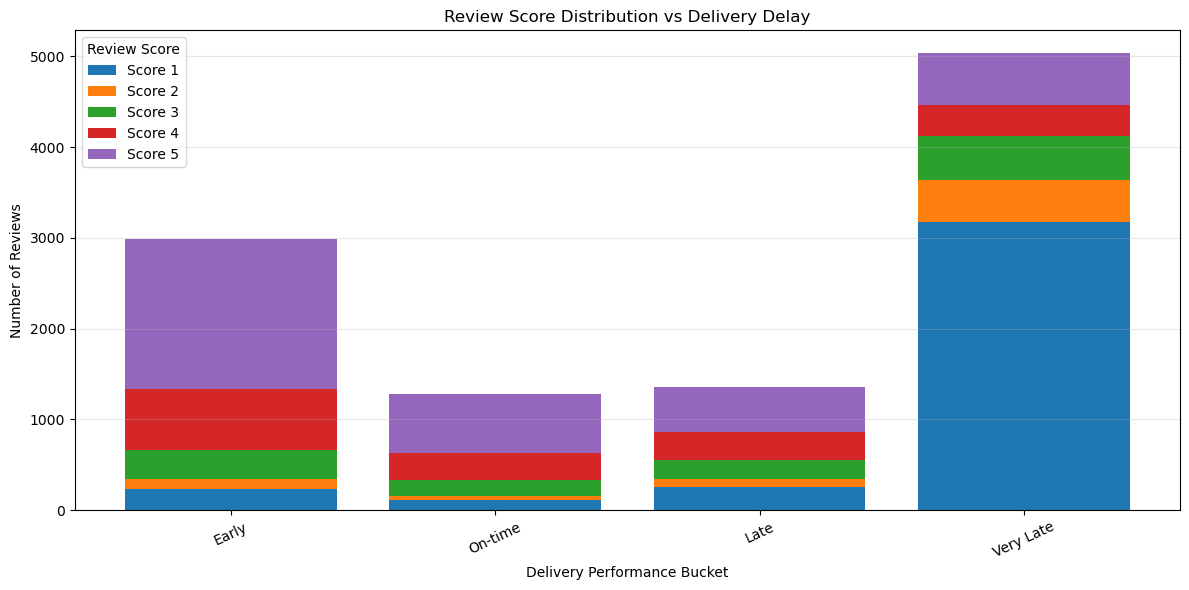

In [342]:
plot_df = delivery_review[delivery_review["delivery_bucket"] != "Very Early"].copy()

plt.figure(figsize=(12,6))

plt.bar(plot_df["delivery_bucket"], plot_df["score_1"], label="Score 1")
plt.bar(plot_df["delivery_bucket"], plot_df["score_2"], bottom=plot_df["score_1"], 
        label="Score 2")
plt.bar(plot_df["delivery_bucket"], plot_df["score_3"], bottom=plot_df["score_1"] 
        + plot_df["score_2"], label="Score 3")
plt.bar(plot_df["delivery_bucket"], plot_df["score_4"], bottom=plot_df["score_1"] 
        + plot_df["score_2"] + plot_df["score_3"], label="Score 4")
plt.bar(plot_df["delivery_bucket"], plot_df["score_5"], bottom=plot_df["score_1"] 
        + plot_df["score_2"] + plot_df["score_3"] + plot_df["score_4"], label="Score 5")

plt.xlabel("Delivery Performance Bucket")
plt.ylabel("Number of Reviews")
plt.title("Review Score Distribution vs Delivery Delay")

plt.xticks(rotation=25)
plt.legend(title="Review Score")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Section 10 Consumer Behavior

In [353]:
# Repeat Customer Rate
# Grain: Customer Level

# customer_unique_id is the true customer identifier.
# Only clean orders are considered.
# Customers with more than one clean order are repeat customers.

query = """WITH customer_orders AS (
SELECT c.customer_unique_id,
COUNT(o.customer_id) AS order_count
FROM olist_orders_dataset o
JOIN olist_customers_dataset c
ON o.customer_id = c.customer_id
WHERE o.order_status NOT IN ('canceled','unavailable')
GROUP BY c.customer_unique_id)

SELECT
COUNT(*) FILTER (WHERE order_count > 1) AS repeat_customers,
COUNT(*) AS total_customers,
ROUND((100.0 * COUNT(*) FILTER (WHERE order_count > 1) / COUNT(*))::NUMERIC, 2) AS repeat_customer_rate
FROM customer_orders;"""

repeat_customer_rate = pd.read_sql(query, engine)
repeat_customer_rate

,repeat_customers,total_customers,repeat_customer_rate
0,2888,94990,3.04


In [347]:
# Customer Order Frequency Distribution
# Grain: Customer Level
#
# Logic:
# - customer_unique_id is the customer identifier.
# - Only clean orders are considered.
# - Customer order frequency is calculated first.
# - Frequency buckets are created after that.

query = """WITH customer_frequency AS (
SELECT c.customer_unique_id,
COUNT(o.order_id) AS clean_order_count
FROM olist_orders_dataset o
JOIN olist_customers_dataset c
ON o.customer_id = c.customer_id
WHERE o.order_status NOT IN ('canceled','unavailable')
GROUP BY c.customer_unique_id),
customer_frequency_bucket AS (
SELECT *,
CASE WHEN clean_order_count = 1 THEN 'One-time'
WHEN clean_order_count = 2 THEN '2 Orders'
ELSE '3+ Orders'
END AS order_frequency_bucket
FROM customer_frequency)
SELECT order_frequency_bucket,
COUNT(*) AS customers,
ROUND((100.0 * COUNT(*) / SUM(COUNT(*)) OVER ())::NUMERIC,2) AS customer_share
FROM customer_frequency_bucket
GROUP BY order_frequency_bucket
ORDER BY CASE order_frequency_bucket
WHEN 'One-time' THEN 1
WHEN '2 Orders' THEN 2
ELSE 3
END"""

customer_frequency_bucket = pd.read_sql(query, engine)
customer_frequency_bucket

,order_frequency_bucket,customers,customer_share
0,One-time,92102,96.96
1,2 Orders,2652,2.79
2,3+ Orders,236,0.25


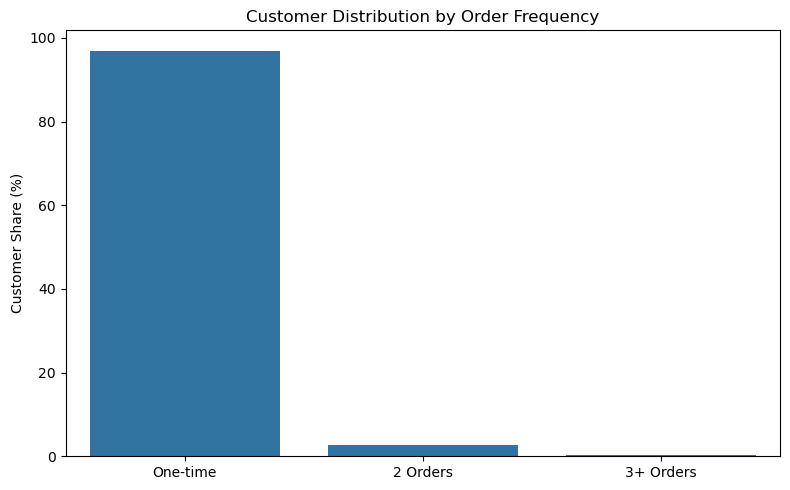

In [348]:
plt.figure(figsize=(8,5))

sns.barplot(data=customer_frequency_bucket, x="order_frequency_bucket",  y="customer_share")
plt.xlabel("")
plt.ylabel("Customer Share (%)")
plt.title("Customer Distribution by Order Frequency")

plt.tight_layout()
plt.show()

In [349]:
# Customer Revenue Concentration 
# Grain: Customer Level

# Only clean orders are considered..

query = """WITH order_payment AS (
SELECT order_id, SUM(payment_value) AS order_payment_value
FROM olist_order_payments_dataset
GROUP BY order_id),
customer_revenue AS (
SELECT c.customer_unique_id, SUM(op.order_payment_value) AS customer_clean_revenue
FROM order_payment op
JOIN olist_orders_dataset o ON op.order_id = o.order_id
JOIN olist_customers_dataset c ON o.customer_id = c.customer_id
WHERE o.order_status NOT IN ('canceled','unavailable')
GROUP BY c.customer_unique_id)
SELECT customer_unique_id, customer_clean_revenue,
ROUND((100.0 * SUM(customer_clean_revenue) OVER (
ORDER BY customer_clean_revenue DESC, customer_unique_id
ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) 
/ SUM(customer_clean_revenue) OVER ())::NUMERIC, 2) AS cumulative_revenue_share
FROM customer_revenue
ORDER BY customer_clean_revenue DESC, customer_unique_id;"""

customer_pareto = pd.read_sql(query, engine)
customer_pareto

,customer_unique_id,customer_clean_revenue,cumulative_revenue_share
0,0a0a92112bd4c708ca5fde585afaa872,13664.08,0.09
1,da122df9eeddfedc1dc1f5349a1a690c,7571.63,0.13
2,763c8b1c9c68a0229c42c9fc6f662b93,7274.88,0.18
3,dc4802a71eae9be1dd28f5d788ceb526,6929.31,0.23
4,459bef486812aa25204be022145caa62,6922.21,0.27
...,...,...,...
94984,2878e5b88167faab17d4fb83a986d38b,11.63,100.00
94985,6f5b9d1cdccc4d28f0483a612edecacf,11.63,100.00
94986,b33336f46234b24a613ad9064d13106d,10.89,100.00
94987,bd06ce0e06ad77a7f681f1a4960a3cc6,10.07,100.00


In [350]:
# Customer Revenue Pareto Threshold Check

thresholds = np.arange(5, 55, 5)

for t in thresholds:
    query = f"""WITH order_payment AS (
    SELECT order_id, SUM(payment_value) AS order_payment_value
    FROM olist_order_payments_dataset
    GROUP BY order_id),
    customer_revenue AS (
    SELECT c.customer_unique_id,
    SUM(op.order_payment_value) AS customer_clean_revenue
    FROM order_payment op
    JOIN olist_orders_dataset o ON op.order_id = o.order_id
    JOIN olist_customers_dataset c ON o.customer_id = c.customer_id
    WHERE o.order_status NOT IN ('canceled','unavailable')
    GROUP BY c.customer_unique_id),
    customer_cume AS (
    SELECT customer_unique_id, customer_clean_revenue,
    ROUND((100.0 * SUM(customer_clean_revenue) OVER (ORDER BY customer_clean_revenue DESC, customer_unique_id
    ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW)
    / SUM(customer_clean_revenue) OVER ())::NUMERIC,2) AS cumulative_revenue_share
    FROM customer_revenue),
    prev_cume AS (
    SELECT customer_unique_id, customer_clean_revenue, cumulative_revenue_share,
    LAG(cumulative_revenue_share,1,0) OVER(ORDER BY customer_clean_revenue DESC, customer_unique_id) AS prev_cum_share
    FROM customer_cume)

    SELECT {t} AS cumulative_threshold,
    COUNT(*) AS customers_required_to_exceed
    FROM prev_cume
    WHERE cumulative_revenue_share < {t}
    OR prev_cum_share < {t};"""

    display(pd.read_sql(query, engine))

,cumulative_threshold,customers_required_to_exceed
0,5,324


,cumulative_threshold,customers_required_to_exceed
0,10,902


,cumulative_threshold,customers_required_to_exceed
0,15,1730


,cumulative_threshold,customers_required_to_exceed
0,20,2812


,cumulative_threshold,customers_required_to_exceed
0,25,4171


,cumulative_threshold,customers_required_to_exceed
0,30,5886


,cumulative_threshold,customers_required_to_exceed
0,35,7952


,cumulative_threshold,customers_required_to_exceed
0,40,10360


,cumulative_threshold,customers_required_to_exceed
0,45,13164


,cumulative_threshold,customers_required_to_exceed
0,50,16410


Around (16410) 17% of customers contributed 50% of the clean revenue. This shows that a smaller group of customers generated a large share of revenue, while most customers contributed relatively less.

In [351]:
# Repeat Category Rate
# Grain: Product Category
#
# Only clean orders are considered.
# Repeat purchase means the same customer bought the same category in 2 or more DISTINCT orders.
# Repeat Category Rate = Repeat Customers / Total Customers Purchasing the Category

query = """WITH clean_orders AS (
SELECT o.order_id, customer_unique_id
FROM olist_orders_dataset o
JOIN olist_customers_dataset c ON o.customer_id = c.customer_id
WHERE o.order_status NOT IN ('canceled','unavailable')),
customer_category_purchase AS (
SELECT customer_unique_id,
COALESCE(p.product_category_name,'Unknown') AS product_category,
COUNT(DISTINCT co.order_id) AS customer_category_order_count
FROM clean_orders co
JOIN olist_order_items_dataset oi ON co.order_id = oi.order_id
JOIN olist_products_dataset p
ON oi.product_id = p.product_id
GROUP BY customer_unique_id, COALESCE(product_category_name,'Unknown')),
category_repeat_summary AS (
SELECT product_category,
COUNT(*) AS total_customers,
COUNT(*) FILTER (WHERE customer_category_order_count >= 2) AS repeat_customers
FROM customer_category_purchase
GROUP BY product_category)
SELECT product_category, total_customers, repeat_customers,
ROUND ((100.0 * repeat_customers / NULLIF(total_customers,0))::NUMERIC,2) AS repeat_category_rate
FROM category_repeat_summary
WHERE repeat_customers != 0
ORDER BY repeat_customers DESC;"""

repeat_category_rate = pd.read_sql(query, engine)

repeat_category_rate

,product_category,total_customers,repeat_customers,repeat_category_rate
0,cama_mesa_banho,9127,252,2.76
1,esporte_lazer,7471,182,2.44
2,beleza_saude,8644,149,1.72
3,moveis_decoracao,6294,128,2.03
4,informatica_acessorios,6522,126,1.93
5,relogios_presentes,5528,63,1.14
6,utilidades_domesticas,5784,61,1.05
7,fashion_bolsas_e_acessorios,1792,55,3.07
8,eletrodomesticos,701,52,7.42
9,automotivo,3829,42,1.10


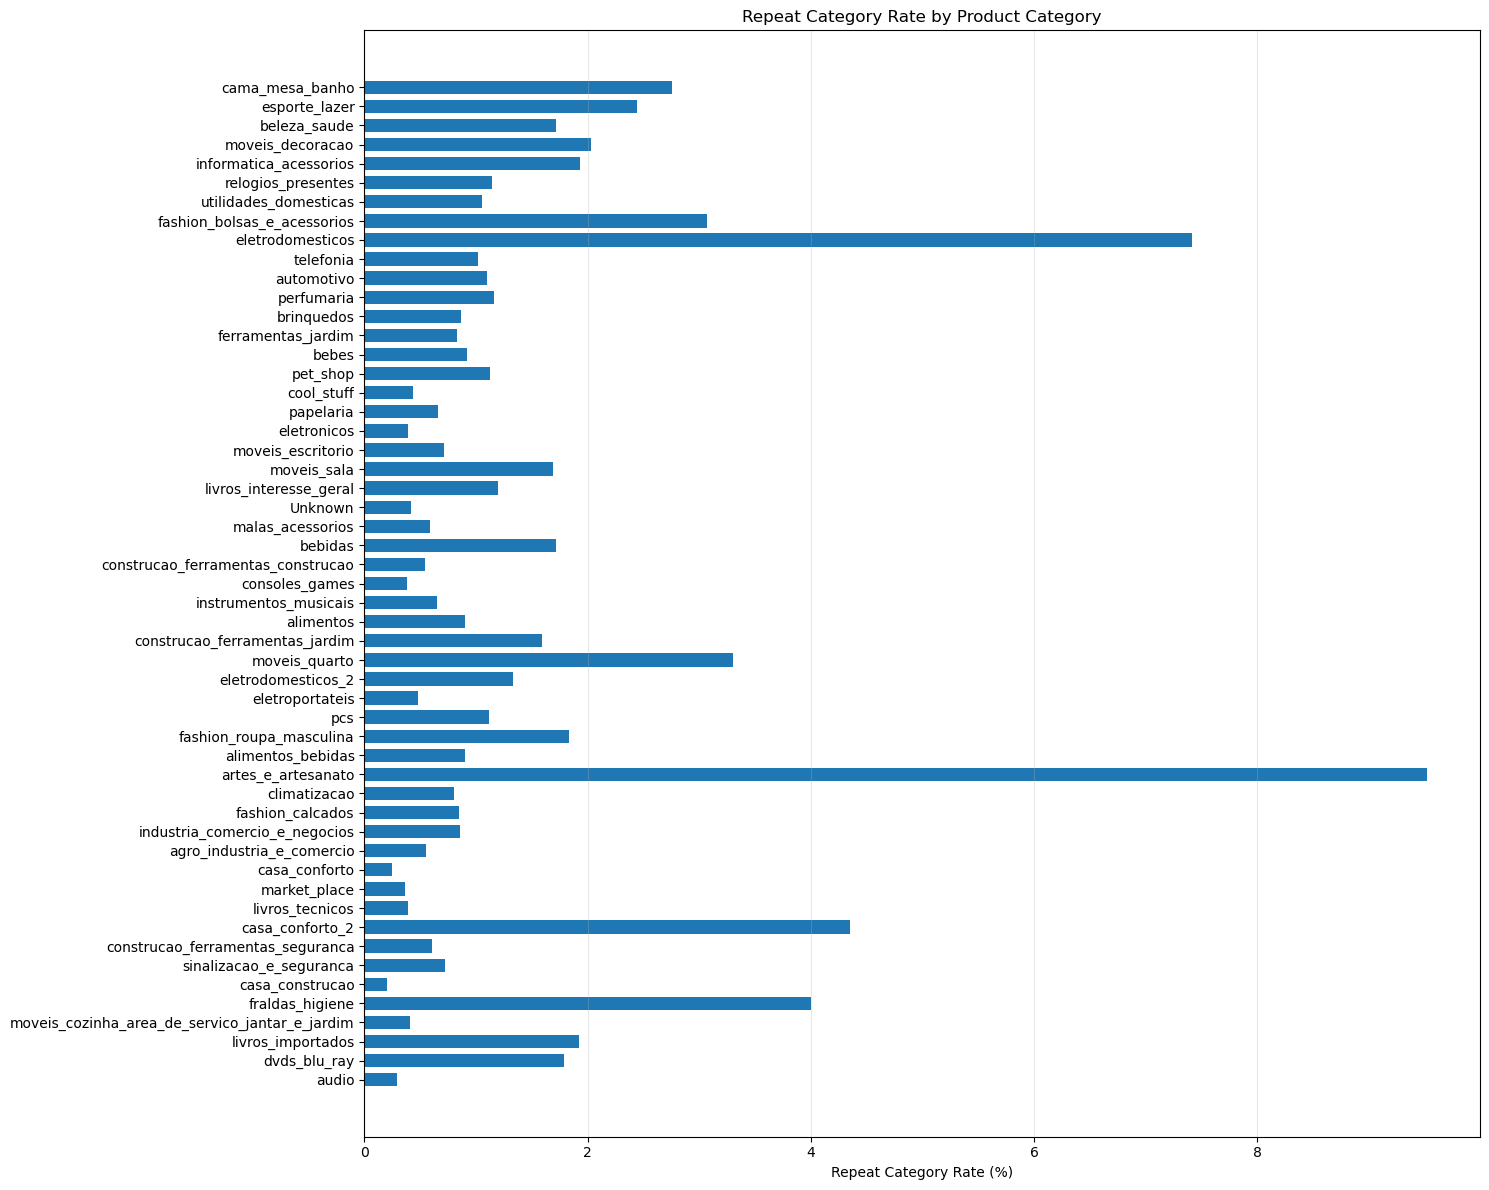

In [352]:
plot_df = repeat_category_rate.sort_values("repeat_customers", ascending=True)
plt.figure(figsize=(15,12))

plt.barh(plot_df["product_category"], plot_df["repeat_category_rate"], height=0.7)

plt.title("Repeat Category Rate by Product Category")
plt.xlabel("Repeat Category Rate (%)")
plt.ylabel("")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

Review sentiment doesn't predict repeat category purchase — malas_acessorios has the best sentiment but a low repeat rate, while eletrodomesticos has only middling sentiment but the highest repeat rate, suggesting repeat behavior here is driven by necessity (e.g., appliances) rather than satisfaction. moveis_escritorio is the exception, where poor sentiment does align with low repeat rate.

Category size (orders/revenue) has no real connection to repeat purchase rate. eletrodomesticos is a small category but has the highest repeat rate, while cama_mesa_banho is the biggest category but only average on repeats.    
The highest-repeat categories don't even rank in the top order/revenue charts — repeat buying seems driven by product type (necessity/replenishment items) rather than category popularity.

# Views for Schema

In [355]:
views = {
"dim_date": """
            CREATE VIEW dim_date AS
            SELECT
            TO_CHAR(d, 'YYYYMMDD')::int   AS date_key,
            d::date                       AS full_date,
            EXTRACT(YEAR FROM d)::int     AS year,
            EXTRACT(QUARTER FROM d)::int  AS quarter,
            EXTRACT(MONTH FROM d)::int    AS month,
            TO_CHAR(d, 'Month')           AS month_name,
            EXTRACT(DAY FROM d)::int      AS day_of_month,
            EXTRACT(ISODOW FROM d)::int   AS day_of_week,
            TO_CHAR(d, 'Day')             AS day_name,
            EXTRACT(ISODOW FROM d) IN (6,7) AS is_weekend,
            EXTRACT(WEEK FROM d)::int     AS week_of_year
            FROM generate_series('2016-09-01'::date, '2018-11-01'::date, '1 day') AS d;""",
"dim_customers": """
            CREATE VIEW dim_customers AS
            SELECT customer_id, customer_unique_id, customer_city, customer_state, customer_zip_code_prefix
            FROM olist_customers_dataset;""",
"dim_sellers": """
            CREATE VIEW dim_sellers AS
            SELECT seller_id, seller_city, seller_state, seller_zip_code_prefix
            FROM olist_sellers_dataset;""",
"dim_products": """
            CREATE VIEW dim_products AS
            SELECT
            p.product_id,
            COALESCE(t.product_category_name_english, 'uncategorized') AS product_category_name_english,
            p.product_weight_g, p.product_length_cm, p.product_height_cm, p.product_width_cm,
            p.product_photos_qty,
            p.product_name_lenght AS product_name_length,
            p.product_description_lenght AS product_description_length
            FROM olist_products_dataset p
            LEFT JOIN product_category_name_translation t
            ON p.product_category_name = t.product_category_name;""",
"fact_orders": """
            CREATE VIEW fact_orders AS
            SELECT
            o.order_id,
            o.customer_id,
            o.order_purchase_timestamp::timestamp::date AS order_purchase_date,
            o.order_status,
            o.order_approved_at::timestamp AS order_approved_at,
            o.order_delivered_carrier_date::timestamp AS order_delivered_carrier_date,
            o.order_delivered_customer_date::timestamp AS order_delivered_customer_date,
            o.order_estimated_delivery_date::timestamp AS order_estimated_delivery_date,
            (o.order_status = 'delivered') AS is_delivered,
            (o.order_status = 'canceled') AS is_canceled,
            (o.order_status IN ('canceled', 'unavailable')) AS is_excluded_from_clean,
            CASE WHEN o.order_delivered_customer_date IS NOT NULL
                 THEN o.order_delivered_customer_date::timestamp > o.order_estimated_delivery_date::timestamp
                 ELSE NULL END AS is_late,
            CASE WHEN o.order_delivered_customer_date IS NOT NULL
                 THEN DATE_PART('day', o.order_delivered_customer_date::timestamp - o.order_purchase_timestamp::timestamp)
                 ELSE NULL END AS delivery_days,
            CASE WHEN o.order_approved_at IS NOT NULL
                 THEN DATE_PART('day', o.order_approved_at::timestamp - o.order_purchase_timestamp::timestamp)
                 ELSE NULL END AS approval_days
            FROM olist_orders_dataset o;""",
"fact_order_items": """
            CREATE VIEW fact_order_items AS
            SELECT
            oi.order_id, oi.order_item_id,
            fo.customer_id, fo.order_purchase_date, fo.order_status,
            fo.is_delivered, fo.is_canceled, fo.is_excluded_from_clean, fo.is_late, fo.delivery_days,
            oi.product_id, oi.seller_id, oi.price, oi.freight_value
            FROM olist_order_items_dataset oi
            JOIN fact_orders fo ON fo.order_id = oi.order_id;""",
"fact_payments": """
            CREATE VIEW fact_payments AS
            SELECT
            p.order_id, p.payment_sequential,
            fo.customer_id, fo.order_purchase_date, fo.order_status,
            p.payment_type, p.payment_installments, p.payment_value,
            (p.payment_value = 0) AS is_zero_value_payment
            FROM olist_order_payments_dataset p
            JOIN fact_orders fo ON fo.order_id = p.order_id;""",
"fact_reviews": """
            CREATE VIEW fact_reviews AS
            SELECT
            rr.order_id, fo.customer_id, fo.order_purchase_date,
            rr.review_score, rr.review_creation_date, rr.review_answer_timestamp,
            DATE_PART('day', rr.review_answer_timestamp - rr.review_creation_date) AS response_days
            FROM (SELECT r.order_id, r.review_score,
                  r.review_creation_date::timestamp AS review_creation_date,
                  r.review_answer_timestamp::timestamp AS review_answer_timestamp,
                  ROW_NUMBER() OVER (PARTITION BY r.order_id ORDER BY r.review_answer_timestamp::timestamp DESC) AS rn
                 FROM olist_order_reviews_dataset r) rr
            JOIN fact_orders fo ON fo.order_id = rr.order_id AND fo.order_status = 'delivered'
            WHERE rr.rn = 1;""",
}

for view_name, query in views.items():
    print(f"\nCreating {view_name}")
    conn.execute(text(f'DROP VIEW IF EXISTS "{view_name}" CASCADE'))
    conn.commit()
    conn.execute(text(query))
    conn.commit()
    print(f"Created {view_name}")


Creating dim_date
Created dim_date

Creating dim_customers
Created dim_customers

Creating dim_sellers
Created dim_sellers

Creating dim_products
Created dim_products

Creating fact_orders
Created fact_orders

Creating fact_order_items
Created fact_order_items

Creating fact_payments
Created fact_payments

Creating fact_reviews
Created fact_reviews


In [358]:
# check
for view_name in views.keys():
    count = pd.read_sql(f'SELECT COUNT(*) FROM "{view_name}"', engine).iloc[0,0]
    print(f"{view_name}: {count:,} rows")

dim_date: 792 rows
dim_customers: 99,441 rows
dim_sellers: 3,095 rows
dim_products: 32,951 rows
fact_orders: 99,441 rows
fact_order_items: 112,650 rows
fact_payments: 103,886 rows
fact_reviews: 95,832 rows
